# Open Bus Poisson-arrival analysis

This notebook tests whether observed bus interarrival times are compatible with an exponential distribution after buses have progressed along their routes.

For each manually requested public line short name, it:

1. looks up only that short name through the Stride API;
2. finds route direction/alternative patterns that pass through central Tel Aviv;
3. automatically selects the pattern with the strongest approximately constant scheduled-origin headway window;
4. pools the same two-hour clock window over comparable Sunday–Thursday service days;
5. computes observed interarrival gaps at every stop;
6. performs exponential Q–Q diagnostics on the final five stops; and
7. plots interarrival-time CV against stop index for all selected lines.

Run the notebook from top to bottom. The first API run may take time; responses are cached on disk, so repeated runs with unchanged inputs are substantially faster.


## Methodological assumptions

- **Central Tel Aviv** is defined by the configurable latitude/longitude rectangle below, not by an official administrative boundary.
- Each requested short name is represented by **one automatically selected direction and route alternative**. Opposite directions are not mixed.
- A two-hour origin window is accepted only when scheduled headways are approximately constant under the numerical criteria implemented in `find_constant_dispatch_window`.
- The same clock-time window is pooled across multiple Sunday–Thursday service days. Interarrival gaps are never formed across dates.
- Membership in the cohort is determined by scheduled departure from the route origin during the two-hour window. Downstream observations may occur after the window ends.
- An observed arrival is the timestamp of the SIRI vehicle-location record linked as nearest to the GTFS stop. It is a discretized passage-time proxy, not necessarily the exact door-opening time.
- A gap is formed only between **consecutive scheduled trips** for which both arrivals are observed at that stop. Missing SIRI records therefore do not create artificial double-headway gaps.
- Exponential marginal interarrival times are necessary but not sufficient for a homogeneous Poisson process. Independence and stationarity must also be assessed.
- The final-five-stop pooled Q–Q curve is descriptive because the same pair of buses contributes gaps at several downstream stops.


In [1]:
# Install all notebook dependencies into the active kernel.
# Re-running this cell is safe.
%pip install -q requests pandas numpy scipy matplotlib tqdm tabulate



[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1. Imports and global constants

In [2]:
from __future__ import annotations

import gzip
import hashlib
import json
import math
import time
from dataclasses import asdict, dataclass
from datetime import date, datetime, time as dtime, timedelta
from pathlib import Path
from typing import Any, Iterable, Iterator, Sequence
from zoneinfo import ZoneInfo

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from IPython.display import Image, Markdown, display
from scipy import stats
from tqdm.auto import tqdm

BASE_URL = "https://open-bus-stride-api.hasadna.org.il"
ISRAEL_TZ = ZoneInfo("Asia/Jerusalem")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)


## 2. Data models

In [3]:
@dataclass(frozen=True)
class BoundingBox:
    """Analyst-defined central Tel Aviv rectangle, not an official boundary."""

    lat_min: float = 32.055
    lat_max: float = 32.105
    lon_min: float = 34.760
    lon_max: float = 34.805

    def contains(self, lat: float | None, lon: float | None) -> bool:
        return (
            lat is not None
            and lon is not None
            and self.lat_min <= float(lat) <= self.lat_max
            and self.lon_min <= float(lon) <= self.lon_max
        )

@dataclass(frozen=True)
class RouteIdentity:
    line_ref: int
    operator_ref: int
    route_short_name: str
    route_direction: str
    route_alternative: str
    agency_name: str
    route_long_name: str

    @classmethod
    def from_prefixed_record(cls, record: dict[str, Any], prefix: str = "gtfs_route__") -> "RouteIdentity":
        def val(name: str, default: Any = "") -> Any:
            x = record.get(prefix + name, default)
            return default if x is None else x

        return cls(
            line_ref=int(val("line_ref", -1)),
            operator_ref=int(val("operator_ref", -1)),
            route_short_name=str(val("route_short_name")),
            route_direction=str(val("route_direction")),
            route_alternative=str(val("route_alternative")),
            agency_name=str(val("agency_name")),
            route_long_name=str(val("route_long_name")),
        )

    def matches_prefixed(self, record: dict[str, Any], prefix: str = "gtfs_route__") -> bool:
        other = RouteIdentity.from_prefixed_record(record, prefix)
        return (
            self.line_ref == other.line_ref
            and self.operator_ref == other.operator_ref
            and self.route_short_name == other.route_short_name
            and self.route_direction == other.route_direction
            and self.route_alternative == other.route_alternative
        )

@dataclass
class WindowChoice:
    start_clock: str
    end_clock: str
    modal_headway_minutes: float
    mean_daily_cv: float
    valid_dates: list[str]
    departures: int
    adjacent_pairs: int

@dataclass
class SelectedRoute:
    identity: RouteIdentity
    window: WindowChoice
    route_stop_sequences: list[int]
    route_stop_codes: list[int]
    route_stop_names: list[str]
    final_stop_codes: list[int]
    final_stop_names: list[str]
    final_stop_positions: list[int]

    @property
    def route_stop_count(self) -> int:
        return len(self.route_stop_sequences)

    @property
    def route_stop_indices(self) -> list[int]:
        return list(range(1, self.route_stop_count + 1))

## 3. User configuration

Edit this cell before running the analysis. Route short names must be strings, since some feeds can contain non-numeric short names.


In [55]:
# Public-facing bus line short names to analyze.
LINE_SHORT_NAMES = ["82", "67", "276", "23", "38", "51", "53", "71", "171", "271", "277", "24"]

# Historical window. The defaults predate the documented post-2024
# deterioration in GTFS/SIRI stop-level enrichment.
START_DATE = "2024-01-01"
END_DATE = "2024-03-01"

# Number of terminal stops used in the exponential Q-Q diagnostics.
N_FINAL_STOPS = 5

# Analyst-defined central Tel Aviv rectangle.
LAT_MIN = 32.055
LAT_MAX = 32.105
LON_MIN = 34.760
LON_MAX = 34.805

# Statistical and output settings.
MAX_GAP_MINUTES = 60.0
BOOTSTRAP_SIMULATIONS = 1_000
RANDOM_SEED = 20260730
OUTPUT_DIR = Path("open_bus_poisson_results")

# The API cache is stored under OUTPUT_DIR / "cache".
# Delete that directory manually when you need to force fresh API downloads.


## 4. Stride API client with retries, pagination, throttling, and disk caching

In [56]:
class StrideClient:
    """Small REST client with pagination, retries, throttling, and disk caching."""

    def __init__(
        self,
        base_url: str = BASE_URL,
        cache_dir: Path | str = Path("stride_cache"),
        timeout: float = 120.0,
        min_request_interval: float = 0.15,
    ) -> None:
        self.base_url = base_url.rstrip("/")
        self.cache_dir = Path(cache_dir)
        self.cache_dir.mkdir(parents=True, exist_ok=True)
        self.timeout = timeout
        self.min_request_interval = min_request_interval
        self.session = requests.Session()
        self.session.headers.update({"User-Agent": "open-bus-poisson-analysis/1.0"})
        self._last_request = 0.0

    @staticmethod
    def _normalized_params(params: dict[str, Any] | None) -> dict[str, Any]:
        out: dict[str, Any] = {}
        for key, value in (params or {}).items():
            if value is None:
                continue
            if isinstance(value, (datetime, date)):
                out[key] = value.isoformat()
            elif isinstance(value, (list, tuple, set)):
                out[key] = ",".join(str(x) for x in value)
            else:
                out[key] = value
        return out

    def _cache_path(self, path: str, params: dict[str, Any]) -> Path:
        payload = json.dumps([path, sorted(params.items())], ensure_ascii=False, default=str).encode("utf-8")
        digest = hashlib.sha256(payload).hexdigest()
        return self.cache_dir / f"{digest}.json.gz"

    def get(self, path: str, params: dict[str, Any] | None = None, retries: int = 5) -> Any:
        normalized = self._normalized_params(params)
        cache_path = self._cache_path(path, normalized)
        if cache_path.exists():
            with gzip.open(cache_path, "rt", encoding="utf-8") as f:
                return json.load(f)

        url = f"{self.base_url}{path}"
        for attempt in range(retries):
            wait = self.min_request_interval - (time.monotonic() - self._last_request)
            if wait > 0:
                time.sleep(wait)
            try:
                response = self.session.get(url, params=normalized, timeout=self.timeout)
                self._last_request = time.monotonic()
                if response.status_code in {429, 500, 502, 503, 504}:
                    raise requests.HTTPError(f"retryable HTTP {response.status_code}", response=response)
                response.raise_for_status()
                data = response.json()
                with gzip.open(cache_path, "wt", encoding="utf-8") as f:
                    json.dump(data, f, ensure_ascii=False)
                return data
            except (requests.RequestException, ValueError) as exc:
                if attempt + 1 == retries:
                    raise RuntimeError(f"Stride request failed: {url} params={normalized}") from exc
                time.sleep(2**attempt)
        raise AssertionError("unreachable")

    def list_all(
        self,
        path: str,
        params: dict[str, Any] | None = None,
        page_size: int = 2_000,
        max_rows: int = 500_000,
    ) -> list[dict[str, Any]]:
        rows: list[dict[str, Any]] = []
        offset = 0
        while offset < max_rows:
            page_params = dict(params or {})
            page_params.update({"limit": min(page_size, max_rows - offset), "offset": offset})
            page = self.get(path, page_params)
            if not isinstance(page, list):
                raise TypeError(f"Expected list from {path}, got {type(page).__name__}")
            rows.extend(page)
            if len(page) < page_params["limit"]:
                break
            offset += len(page)
        return rows

## 5. General and statistical utility functions

In [57]:
def daterange(start: date, end: date) -> Iterator[date]:
    current = start
    while current <= end:
        yield current
        current += timedelta(days=1)


def israeli_weekdays(start: date, end: date) -> list[date]:
    """Sunday through Thursday. Python weekday: Monday=0, Sunday=6."""
    return [d for d in daterange(start, end) if d.weekday() in {0, 1, 2, 3, 6}]


def local_datetime(day: date, hhmm: str) -> datetime:
    hour, minute = map(int, hhmm.split(":"))
    return datetime.combine(day, dtime(hour, minute), tzinfo=ISRAEL_TZ)


def parse_dt(value: Any) -> pd.Timestamp:
    """Interpret timezone-naive API datetimes as Israel local time."""
    ts = pd.Timestamp(value)
    if ts.tzinfo is None:
        return ts.tz_localize(ISRAEL_TZ)
    return ts.tz_convert(ISRAEL_TZ)


def parse_datetime_series(values: pd.Series) -> pd.Series:
    return values.map(parse_dt)


def batched(values: Sequence[Any], size: int) -> Iterator[Sequence[Any]]:
    for i in range(0, len(values), size):
        yield values[i : i + size]


def safe_cv(values: Sequence[float]) -> float:
    a = np.asarray(values, dtype=float)
    if len(a) < 2 or np.mean(a) <= 0:
        return float("nan")
    return float(np.std(a, ddof=1) / np.mean(a))


def qq_coordinates_exponential(values: Sequence[float], normalize: bool = True) -> tuple[np.ndarray, np.ndarray]:
    y = np.sort(np.asarray(values, dtype=float))
    y = y[np.isfinite(y) & (y > 0)]
    if normalize and len(y):
        y = y / np.mean(y)
    n = len(y)
    p = (np.arange(1, n + 1) - 0.5) / n
    x = stats.expon.ppf(p, scale=1.0 if normalize else np.mean(y))
    return x, y


def qq_r_squared(values: Sequence[float]) -> float:
    x, y = qq_coordinates_exponential(values, normalize=True)
    if len(x) < 3:
        return float("nan")
    return float(np.corrcoef(x, y)[0, 1] ** 2)


def lag1_autocorrelation(values: Sequence[float]) -> float:
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 4 or np.std(x[:-1]) == 0 or np.std(x[1:]) == 0:
        return float("nan")
    return float(np.corrcoef(x[:-1], x[1:])[0, 1])


def fitted_exponential_ks(values: Sequence[float]) -> float:
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x) & (x > 0)]
    if len(x) < 2:
        return float("nan")
    scale = float(np.mean(x))
    return float(stats.kstest(x, "expon", args=(0.0, scale)).statistic)


def exponential_ks_bootstrap_pvalue(
    values: Sequence[float], rng: np.random.Generator, simulations: int = 1_000
) -> float:
    """Parametric-bootstrap KS p-value with the exponential mean re-fitted each draw."""
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x) & (x > 0)]
    if len(x) < 8:
        return float("nan")
    observed = fitted_exponential_ks(x)
    scale = float(np.mean(x))
    count = 0
    for _ in range(simulations):
        sample = rng.exponential(scale=scale, size=len(x))
        if fitted_exponential_ks(sample) >= observed:
            count += 1
    return (count + 1) / (simulations + 1)

## 6. Short-name-first route discovery

This is the optimized discovery path. It queries `/gtfs_routes/list` for each exact requested short name, then inspects only representative rides of those matching route records to verify that the pattern serves the configured Tel Aviv bounding box.


In [58]:
def route_identity_from_route_record(record: dict[str, Any]) -> RouteIdentity:
    """Build a stable route identity from an unprefixed /gtfs_routes/list row."""

    def clean(name: str, default: str = "") -> str:
        value = record.get(name, default)
        return default if value is None else str(value).strip()

    return RouteIdentity(
        line_ref=int(record.get("line_ref", -1)),
        operator_ref=int(record.get("operator_ref", -1)),
        route_short_name=clean("route_short_name"),
        route_direction=clean("route_direction"),
        route_alternative=clean("route_alternative"),
        agency_name=clean("agency_name"),
        route_long_name=clean("route_long_name"),
    )


def representative_ride_stops_for_route_record(
    client: StrideClient,
    route_record: dict[str, Any],
    reference_date: date,
    max_rides_to_try: int = 3,
) -> list[dict[str, Any]]:
    """Return a complete stop sequence for one exact dated GTFS route record.

    Discovery starts from /gtfs_routes/list, so ``route_record['id']`` is an
    exact dated GTFS route id. Querying rides by that id is substantially
    cheaper than scanning every stop in central Tel Aviv.
    """
    route_id = int(route_record["id"])
    rides = client.list_all(
        "/gtfs_rides/list",
        {
            "gtfs_route_id": route_id,
            "start_time_from": local_datetime(reference_date, "00:00"),
            "start_time_to": local_datetime(reference_date + timedelta(days=1), "00:00"),
            "order_by": "start_time asc",
        },
        page_size=max_rides_to_try,
        max_rows=max_rides_to_try,
    )
    for ride in rides[:max_rides_to_try]:
        ride_id = ride.get("id")
        if ride_id is None:
            continue
        stops = client.list_all(
            "/gtfs_ride_stops/list",
            {"gtfs_ride_ids": str(int(ride_id)), "order_by": "stop_sequence asc"},
            page_size=500,
            max_rows=500,
        )
        if stops:
            return sorted(
                stops,
                key=lambda x: (x.get("stop_sequence") is None, x.get("stop_sequence", 0)),
            )
    return []


def route_serves_bounding_box(stops: Sequence[dict[str, Any]], bbox: BoundingBox) -> bool:
    """Whether a representative route stop sequence enters the configured box."""
    return any(
        bbox.contains(stop.get("gtfs_stop__lat"), stop.get("gtfs_stop__lon"))
        for stop in stops
    )


def discover_route_candidates(
    client: StrideClient,
    reference_date: date,
    bbox: BoundingBox,
    requested_line_short_names: Sequence[str],
    max_candidates_per_line: int = 30,
) -> dict[str, list[RouteIdentity]]:
    """Find central-Tel-Aviv route patterns by querying each short name first.

    For each requested public line number, the function:
      1. queries only matching dated GTFS route records;
      2. obtains a few rides for each exact ``gtfs_route_id``;
      3. downloads one representative stop sequence; and
      4. retains the direction/alternative only if that sequence enters the
         configured central-Tel-Aviv bounding box.

    This avoids the previous citywide scan of all GTFS stops and all ride-stop
    calls in central Tel Aviv. Direction and route alternative remain distinct.
    """
    requested = list(dict.fromkeys(str(x).strip() for x in requested_line_short_names if str(x).strip()))
    if not requested:
        raise ValueError("At least one non-empty route short name must be supplied.")

    by_line: dict[str, list[RouteIdentity]] = {line: [] for line in requested}

    for line in tqdm(requested, desc="Looking up requested line short names"):
        route_query = {
            "date_from": reference_date,
            "date_to": reference_date,
            "route_short_name": line,
        }
        route_records = client.list_all(
            "/gtfs_routes/list",
            {**route_query, "route_type": "3"},
            page_size=500,
            max_rows=5_000,
        )
        # Some historical feeds may omit route_type. Fall back to the exact
        # short-name query rather than failing to find an otherwise valid line.
        if not route_records:
            route_records = client.list_all(
                "/gtfs_routes/list",
                route_query,
                page_size=500,
                max_rows=5_000,
            )
        if not route_records:
            continue

        # If the fallback returned multiple transport modes, prefer buses.
        bus_records = [r for r in route_records if str(r.get("route_type", "")).strip() == "3"]
        if bus_records:
            route_records = bus_records

        records_by_identity: dict[RouteIdentity, list[dict[str, Any]]] = {}
        for record in route_records:
            identity = route_identity_from_route_record(record)
            if identity.route_short_name == line:
                records_by_identity.setdefault(identity, []).append(record)

        for identity, dated_records in records_by_identity.items():
            serves_central_tel_aviv = False
            for record in dated_records:
                stops = representative_ride_stops_for_route_record(client, record, reference_date)
                if stops and route_serves_bounding_box(stops, bbox):
                    serves_central_tel_aviv = True
                    break
            if not serves_central_tel_aviv:
                continue

            by_line[line].append(identity)
            if len(by_line[line]) >= max_candidates_per_line:
                break

    return by_line

## 7. Constant-headway window and automatic route-pattern selection

For each requested short name, all eligible central-Tel-Aviv direction/alternative patterns are evaluated. Selection prioritizes more valid service days, more adjacent scheduled pairs, more departures, and then lower scheduled-headway CV.


In [59]:
def fetch_gtfs_rides_for_identity(
    client: StrideClient, identity: RouteIdentity, start_date: date, end_date: date
) -> pd.DataFrame:
    records = client.list_all(
        "/gtfs_rides/list",
        {
            "gtfs_route__line_refs": str(identity.line_ref),
            "gtfs_route__date_from": start_date,
            "gtfs_route__date_to": end_date,
            "start_time_from": local_datetime(start_date, "00:00"),
            "start_time_to": local_datetime(end_date + timedelta(days=1), "00:00"),
            "order_by": "start_time",
        },
        page_size=5_000,
    )
    records = [r for r in records if identity.matches_prefixed(r)]
    df = pd.DataFrame(records)
    if df.empty:
        return df
    df["start_time"] = parse_datetime_series(df["start_time"])
    df["service_date"] = df["start_time"].dt.date.astype(str)
    return df.sort_values("start_time").drop_duplicates("id")


def find_constant_dispatch_window(
    rides: pd.DataFrame,
    analysis_dates: Sequence[date],
    window_hours: float = 2.0,
    grid_minutes: int = 15,
    earliest: str = "06:00",
    latest_start: str = "20:00",
    min_departures_per_day: int = 6,
    min_valid_days: int = 6,
    max_daily_cv: float = 0.1,
    max_mode_difference_seconds: float = 60.0,
    max_headway_deviation_fraction: float = 0.15,
) -> WindowChoice | None:
    """Find a two-hour interval with effectively constant scheduled headway.

    A date qualifies when it has at least min_departures_per_day and:
      * headway CV <= max_daily_cv;
      * every headway lies within max(60 s, 15% of the day's modal headway).
    Across dates, daily modal headways must agree within 60 seconds.
    """
    if rides.empty:
        return None

    eh, em = map(int, earliest.split(":"))
    lh, lm = map(int, latest_start.split(":"))
    first_minute = 60 * eh + em
    last_minute = 60 * lh + lm
    best: tuple[tuple[float, ...], WindowChoice] | None = None

    for minute in range(first_minute, last_minute + 1, grid_minutes):
        hhmm = f"{minute // 60:02d}:{minute % 60:02d}"
        daily: list[dict[str, Any]] = []
        for day in analysis_dates:
            start = pd.Timestamp(local_datetime(day, hhmm))
            end = start + pd.Timedelta(hours=window_hours)
            times = rides.loc[(rides["start_time"] >= start) & (rides["start_time"] < end), "start_time"].sort_values()
            if len(times) < min_departures_per_day:
                continue
            headways = times.diff().dropna().dt.total_seconds().to_numpy()
            rounded = np.round(headways / 60.0) * 60.0
            values, counts = np.unique(rounded, return_counts=True)
            mode = float(values[np.argmax(counts)])
            cv = safe_cv(headways)
            tolerance = max(60.0, max_headway_deviation_fraction * mode)
            if np.isfinite(cv) and cv <= max_daily_cv and np.max(np.abs(headways - mode)) <= tolerance:
                daily.append(
                    {
                        "date": day.isoformat(),
                        "departures": len(times),
                        "pairs": len(headways),
                        "mode": mode,
                        "cv": cv,
                    }
                )

        if len(daily) < min_valid_days:
            continue
        consensus_mode = float(np.median([d["mode"] for d in daily]))
        daily = [d for d in daily if abs(d["mode"] - consensus_mode) <= max_mode_difference_seconds]
        if len(daily) < min_valid_days:
            continue

        choice = WindowChoice(
            start_clock=hhmm,
            end_clock=(datetime(2000, 1, 1, minute // 60, minute % 60) + timedelta(hours=window_hours)).strftime("%H:%M"),
            modal_headway_minutes=consensus_mode / 60.0,
            mean_daily_cv=float(np.mean([d["cv"] for d in daily])),
            valid_dates=[d["date"] for d in daily],
            departures=int(sum(d["departures"] for d in daily)),
            adjacent_pairs=int(sum(d["pairs"] for d in daily)),
        )
        # Prefer more valid days, more adjacent pairs, lower CV, and then an earlier window.
        score = (
            float(len(choice.valid_dates)),
            float(choice.adjacent_pairs),
            -choice.mean_daily_cv,
            -float(minute),
        )
        if best is None or score > best[0]:
            best = (score, choice)
    return None if best is None else best[1]


def get_reference_route_stops(
    client: StrideClient,
    rides: pd.DataFrame,
    window: WindowChoice,
    n_final_stops: int = 5,
) -> tuple[list[int], list[int], list[str]] | None:
    """Return the complete ordered stop sequence for a representative ride.

    The full sequence supports the route-wide CV plot. The final
    ``n_final_stops`` entries are still the only stops used in the exponential
    Q-Q and formal stop-level diagnostics.
    """
    valid = set(window.valid_dates)
    eligible = rides[rides["service_date"].isin(valid)].copy()
    if eligible.empty:
        return None
    eligible["clock_minutes"] = eligible["start_time"].dt.hour * 60 + eligible["start_time"].dt.minute
    sh, sm = map(int, window.start_clock.split(":"))
    start_minute = 60 * sh + sm
    end_minute = start_minute + 120
    eligible = eligible[(eligible["clock_minutes"] >= start_minute) & (eligible["clock_minutes"] < end_minute)]
    if eligible.empty:
        return None

    # Try several rides in case one has an incomplete or malformed stop sequence.
    for ride_id in eligible["id"].head(10):
        stops = client.list_all(
            "/gtfs_ride_stops/list",
            {"gtfs_ride_ids": str(int(ride_id)), "order_by": "stop_sequence"},
            page_size=500,
        )
        stops = sorted(stops, key=lambda x: (x.get("stop_sequence") is None, x.get("stop_sequence", 0)))
        if len(stops) < n_final_stops:
            continue

        usable = [
            stop
            for stop in stops
            if stop.get("stop_sequence") is not None and stop.get("gtfs_stop__code") is not None
        ]
        if len(usable) < n_final_stops:
            continue

        sequences = [int(stop["stop_sequence"]) for stop in usable]
        codes = [int(stop["gtfs_stop__code"]) for stop in usable]
        names = [str(stop.get("gtfs_stop__name") or stop["gtfs_stop__code"]) for stop in usable]

        # Stop sequence is the stable route position identifier. Stop codes may
        # legitimately repeat on circular routes, so uniqueness is not required.
        if len(set(sequences)) != len(sequences):
            continue
        return sequences, codes, names
    return None


def select_routes(
    client: StrideClient,
    start_date: date,
    end_date: date,
    bbox: BoundingBox,
    requested_line_short_names: Sequence[str],
    n_final_stops: int = 5,
) -> tuple[list[SelectedRoute], dict[RouteIdentity, pd.DataFrame]]:
    """Choose one eligible route pattern automatically for each requested line.

    For each short name, every central-Tel-Aviv direction/alternative is tested.
    The selected pattern maximizes, lexicographically: valid service days,
    adjacent scheduled pairs, total departures, and low scheduled-headway CV.
    """
    requested = list(dict.fromkeys(str(x).strip() for x in requested_line_short_names if str(x).strip()))
    if not requested:
        raise ValueError("Supply at least one line using --lines.")
    if n_final_stops < 1:
        raise ValueError("n_final_stops must be at least 1.")

    analysis_dates = israeli_weekdays(start_date, end_date)
    if not analysis_dates:
        raise ValueError("The selected date range contains no Sunday-Thursday service days.")
    reference_date = analysis_dates[0]
    candidates_by_line = discover_route_candidates(
        client,
        reference_date,
        bbox,
        requested_line_short_names=requested,
    )

    selected: list[SelectedRoute] = []
    rides_cache: dict[RouteIdentity, pd.DataFrame] = {}
    failures: list[str] = []

    for line in tqdm(requested, desc="Choosing route pattern for each requested line"):
        candidates = candidates_by_line.get(line, [])
        if not candidates:
            failures.append(f"{line}: no central-Tel-Aviv route pattern found")
            continue

        best: tuple[tuple[float, ...], SelectedRoute] | None = None
        for identity in candidates:
            rides = fetch_gtfs_rides_for_identity(client, identity, start_date, end_date)
            rides_cache[identity] = rides
            window = find_constant_dispatch_window(rides, analysis_dates)
            if window is None:
                continue
            route_stops = get_reference_route_stops(client, rides, window, n_final_stops=n_final_stops)
            if route_stops is None:
                continue
            sequences, codes, names = route_stops
            route = SelectedRoute(
                identity=identity,
                window=window,
                route_stop_sequences=sequences,
                route_stop_codes=codes,
                route_stop_names=names,
                final_stop_codes=codes[-n_final_stops:],
                final_stop_names=names[-n_final_stops:],
                final_stop_positions=list(range(-n_final_stops, 0)),
            )
            score = (
                len(rides),
                len(window.valid_dates),
                window.adjacent_pairs,
                -window.mean_daily_cv,
            )
            if best is None or score > best[0]:
                best = (score, route)

        if best is None:
            failures.append(
                f"{line}: route patterns exist, but none had an eligible constant-headway "
                f"window and {n_final_stops} usable final stops"
            )
            continue
        selected.append(best[1])

    if failures:
        details = "\n  - ".join(failures)
        raise RuntimeError(
            "Could not construct the requested analysis for every line:\n  - " + details
            + "\nExpand the date range or relax the constant-headway thresholds."
        )
    return selected, rides_cache

## 8. SIRI arrival extraction and consecutive-trip gap construction

In [60]:
def scheduled_cohort(rides: pd.DataFrame, route: SelectedRoute, day: date) -> pd.DataFrame:
    start = pd.Timestamp(local_datetime(day, route.window.start_clock))
    end = start + pd.Timedelta(hours=2)
    cohort = rides[(rides["start_time"] >= start) & (rides["start_time"] < end)].copy()
    return cohort.sort_values("start_time").drop_duplicates("id")


def fetch_siri_rides_for_cohort(
    client: StrideClient,
    route: SelectedRoute,
    day: date,
    cohort: pd.DataFrame,
) -> pd.DataFrame:
    if cohort.empty:
        return pd.DataFrame()
    start = pd.Timestamp(local_datetime(day, route.window.start_clock))
    end = start + pd.Timedelta(hours=2)
    rows = client.list_all(
        "/siri_rides/list",
        {
            "siri_route__line_refs": str(route.identity.line_ref),
            "scheduled_start_time_from": start.isoformat(),
            "scheduled_start_time_to": end.isoformat(),
            "order_by": "scheduled_start_time",
        },
        page_size=2_000,
    )
    df = pd.DataFrame(rows)
    if df.empty or "gtfs_ride_id" not in df.columns:
        return pd.DataFrame()
    cohort_ids = set(cohort["id"].astype(int))
    df = df[df["gtfs_ride_id"].isin(cohort_ids)].copy()
    if not df.empty:
        df["scheduled_start_time"] = parse_datetime_series(df["scheduled_start_time"])
    return df


def fetch_arrivals_for_siri_rides(
    client: StrideClient,
    siri_rides: pd.DataFrame,
    route: SelectedRoute,
    day: date,
) -> pd.DataFrame:
    """Return observed passage-time proxies at every stop of the route.

    The SIRI endpoint already returns all ride stops for the requested rides, so
    retaining all route stops adds local processing and output size but no extra
    SIRI API request count compared with retaining only the final five.
    """
    if siri_rides.empty:
        return pd.DataFrame()
    rows: list[dict[str, Any]] = []
    ids = [int(x) for x in siri_rides["id"].unique()]
    for id_batch in batched(ids, 80):
        rows.extend(
            client.list_all(
                "/siri_ride_stops/list",
                {
                    "siri_ride_ids": id_batch,
                    "gtfs_date_from": day,
                    "gtfs_date_to": day,
                },
                page_size=5_000,
            )
        )
    df = pd.DataFrame(rows)
    if df.empty:
        return df

    required = {
        "siri_ride_id",
        "gtfs_stop__code",
        "nearest_siri_vehicle_location__recorded_at_time",
    }
    missing = required - set(df.columns)
    if missing:
        raise KeyError(f"SIRI ride-stop response lacks fields: {sorted(missing)}")

    df = df[df["nearest_siri_vehicle_location__recorded_at_time"].notna()].copy()
    if df.empty:
        return df
    df["arrival_time"] = parse_datetime_series(
        df["nearest_siri_vehicle_location__recorded_at_time"]
    )

    ride_map = siri_rides[["id", "gtfs_ride_id", "scheduled_start_time"]].rename(columns={"id": "siri_ride_id"})
    df = df.merge(ride_map, on="siri_ride_id", how="inner")
    distance_column = "nearest_siri_vehicle_location__distance_from_siri_ride_stop_meters"
    if distance_column not in df.columns:
        df[distance_column] = np.nan

    sequence_column = "gtfs_ride_stop__stop_sequence"
    sequence_to_index = {
        int(sequence): index
        for index, sequence in enumerate(route.route_stop_sequences, start=1)
    }
    sequence_to_code = dict(zip(route.route_stop_sequences, route.route_stop_codes))
    sequence_to_name = dict(zip(route.route_stop_sequences, route.route_stop_names))

    if sequence_column in df.columns and df[sequence_column].notna().any():
        df["route_stop_sequence"] = pd.to_numeric(df[sequence_column], errors="coerce")
        df["observed_stop_code"] = pd.to_numeric(df["gtfs_stop__code"], errors="coerce")
        df = df[df["route_stop_sequence"].isin(sequence_to_index)].copy()
        df["route_stop_sequence"] = df["route_stop_sequence"].astype(int)
        df["expected_stop_code"] = df["route_stop_sequence"].map(sequence_to_code)
        # Require both route position and physical stop code to agree with the
        # reference pattern. This prevents a dated route change from silently
        # relabeling a different stop that happens to have the same sequence.
        df = df[df["observed_stop_code"] == df["expected_stop_code"]].copy()
        df["stop_index"] = df["route_stop_sequence"].map(sequence_to_index)
        # Use the reference pattern's code/name so all service days have one
        # consistent route-position definition.
        df["stop_code"] = df["expected_stop_code"].astype(int)
        df["stop_name"] = df["route_stop_sequence"].map(sequence_to_name)
    else:
        # Historical rows should include gtfs_ride_stop__stop_sequence. This
        # fallback is safe only when stop codes are unique on the selected route.
        if len(set(route.route_stop_codes)) != route.route_stop_count:
            raise KeyError(
                "SIRI ride-stop rows lack gtfs_ride_stop__stop_sequence, and the route repeats a stop code; "
                "route-wide stop positions cannot be identified unambiguously."
            )
        code_to_index = {code: i for i, code in enumerate(route.route_stop_codes, start=1)}
        code_to_name = dict(zip(route.route_stop_codes, route.route_stop_names))
        df["observed_stop_code"] = pd.to_numeric(df["gtfs_stop__code"], errors="coerce")
        df = df[df["observed_stop_code"].isin(code_to_index)].copy()
        df["stop_code"] = df["observed_stop_code"].astype(int)
        df["stop_index"] = df["stop_code"].map(code_to_index)
        df["stop_name"] = df["stop_code"].map(code_to_name)
        index_to_sequence = dict(enumerate(route.route_stop_sequences, start=1))
        df["route_stop_sequence"] = df["stop_index"].map(index_to_sequence)

    if df.empty:
        return df

    df["stop_index"] = df["stop_index"].astype(int)
    df["route_stop_count"] = route.route_stop_count
    df["relative_stop_position"] = df["stop_index"] - route.route_stop_count - 1
    df["is_final_analysis_stop"] = df["relative_stop_position"].isin(route.final_stop_positions)
    df["service_date"] = day.isoformat()
    df["line"] = route.identity.route_short_name
    df["line_ref"] = route.identity.line_ref

    # If duplicated SIRI ride records map to one scheduled GTFS trip, retain the
    # SIRI ride with the most route-stop observations; then one timestamp/stop.
    coverage = (
        df.groupby(["gtfs_ride_id", "siri_ride_id"])["stop_index"]
        .nunique()
        .rename("coverage")
        .reset_index()
    )
    best = (
        coverage.sort_values(["gtfs_ride_id", "coverage", "siri_ride_id"], ascending=[True, False, True])
        .drop_duplicates("gtfs_ride_id")[["gtfs_ride_id", "siri_ride_id"]]
    )
    df = df.merge(best, on=["gtfs_ride_id", "siri_ride_id"], how="inner")
    df = (
        df.sort_values("arrival_time")
        .drop_duplicates(["gtfs_ride_id", "stop_index"], keep="first")
    )
    return df[
        [
            "line",
            "line_ref",
            "service_date",
            "gtfs_ride_id",
            "siri_ride_id",
            "scheduled_start_time",
            "route_stop_sequence",
            "stop_index",
            "route_stop_count",
            "relative_stop_position",
            "is_final_analysis_stop",
            "stop_code",
            "stop_name",
            "arrival_time",
            "nearest_siri_vehicle_location__distance_from_siri_ride_stop_meters",
        ]
    ].rename(
        columns={
            "nearest_siri_vehicle_location__distance_from_siri_ride_stop_meters": "distance_to_stop_meters",
        }
    )


def collect_observed_arrivals(
    client: StrideClient,
    selected: Sequence[SelectedRoute],
    rides_cache: dict[RouteIdentity, pd.DataFrame],
) -> pd.DataFrame:
    frames: list[pd.DataFrame] = []
    tasks = [(route, date.fromisoformat(day)) for route in selected for day in route.window.valid_dates]
    for route, day in tqdm(tasks, desc="Downloading observed arrivals at all route stops"):
        rides = rides_cache[route.identity]
        cohort = scheduled_cohort(rides, route, day)
        siri_rides = fetch_siri_rides_for_cohort(client, route, day, cohort)
        arrivals = fetch_arrivals_for_siri_rides(client, siri_rides, route, day)
        if not arrivals.empty:
            frames.append(arrivals)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


def build_consecutive_interarrival_gaps(
    arrivals: pd.DataFrame,
    selected: Sequence[SelectedRoute],
    rides_cache: dict[RouteIdentity, pd.DataFrame],
    max_gap_minutes: float = 60.0,
) -> pd.DataFrame:
    """Build gaps at every route stop using only adjacent scheduled trips."""
    records: list[dict[str, Any]] = []
    for route in selected:
        rides = rides_cache[route.identity]
        line_arrivals = arrivals[arrivals["line_ref"] == route.identity.line_ref]
        for day_text in route.window.valid_dates:
            day = date.fromisoformat(day_text)
            cohort = scheduled_cohort(rides, route, day).reset_index(drop=True)
            if len(cohort) < 2:
                continue
            schedule_order = {int(ride_id): i for i, ride_id in enumerate(cohort["id"])}
            day_arrivals = line_arrivals[line_arrivals["service_date"] == day_text].copy()
            day_arrivals["scheduled_index"] = day_arrivals["gtfs_ride_id"].map(schedule_order)
            day_arrivals = day_arrivals[day_arrivals["scheduled_index"].notna()]

            for stop_index in route.route_stop_indices:
                stop_rows = day_arrivals[day_arrivals["stop_index"] == stop_index].copy()
                by_index = {
                    int(row.scheduled_index): row
                    for row in stop_rows.itertuples(index=False)
                }
                for i in range(len(cohort) - 1):
                    left = by_index.get(i)
                    right = by_index.get(i + 1)
                    if left is None or right is None:
                        continue
                    gap_minutes = (right.arrival_time - left.arrival_time).total_seconds() / 60.0
                    if not (0.0 < gap_minutes <= max_gap_minutes):
                        continue
                    records.append(
                        {
                            "line": route.identity.route_short_name,
                            "line_ref": route.identity.line_ref,
                            "service_date": day_text,
                            "route_stop_sequence": int(left.route_stop_sequence),
                            "stop_index": int(left.stop_index),
                            "route_stop_count": int(left.route_stop_count),
                            "relative_stop_position": int(left.relative_stop_position),
                            "is_final_analysis_stop": bool(left.is_final_analysis_stop),
                            "stop_code": int(left.stop_code),
                            "stop_name": left.stop_name,
                            "leading_gtfs_ride_id": int(left.gtfs_ride_id),
                            "following_gtfs_ride_id": int(right.gtfs_ride_id),
                            "leading_arrival_time": left.arrival_time,
                            "following_arrival_time": right.arrival_time,
                            "gap_minutes": gap_minutes,
                            "scheduled_origin_gap_minutes": (
                                cohort.loc[i + 1, "start_time"] - cohort.loc[i, "start_time"]
                            ).total_seconds()
                            / 60.0,
                        }
                    )
    return pd.DataFrame(records)

## 9. Statistical summaries

In [61]:
def analyze_stop_level(gaps: pd.DataFrame, bootstrap_simulations: int, seed: int) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    rows: list[dict[str, Any]] = []
    group_cols = ["line", "line_ref", "relative_stop_position", "stop_code", "stop_name"]
    for keys, group in gaps.sort_values(["service_date", "leading_arrival_time"]).groupby(group_cols, dropna=False):
        values = group["gap_minutes"].to_numpy(float)
        line, line_ref, pos, code, name = keys
        rows.append(
            {
                "line": line,
                "line_ref": line_ref,
                "relative_stop_position": pos,
                "stop_code": code,
                "stop_name": name,
                "n_gaps": len(values),
                "mean_gap_minutes": float(np.mean(values)),
                "std_gap_minutes": float(np.std(values, ddof=1)) if len(values) > 1 else float("nan"),
                "cv": safe_cv(values),
                "qq_r_squared": qq_r_squared(values),
                "ks_statistic": fitted_exponential_ks(values),
                "ks_bootstrap_pvalue": exponential_ks_bootstrap_pvalue(values, rng, bootstrap_simulations),
                "lag1_autocorrelation": lag1_autocorrelation(values),
                "mean_scheduled_origin_gap_minutes": float(group["scheduled_origin_gap_minutes"].mean()),
            }
        )
    result = pd.DataFrame(rows)
    if not result.empty:
        result["diagnostic_exponential_fit"] = (
            (result["n_gaps"] >= 30)
            & result["cv"].between(0.8, 1.2)
            & (result["qq_r_squared"] >= 0.97)
            & (result["ks_bootstrap_pvalue"] >= 0.05)
        )
    return result


def analyze_route_stop_cv(
    all_stop_gaps: pd.DataFrame,
    selected: Sequence[SelectedRoute],
) -> pd.DataFrame:
    """Compute CV at every reference-route stop, retaining rows with no estimate."""
    summary_rows: list[dict[str, Any]] = []
    if not all_stop_gaps.empty:
        group_cols = [
            "line",
            "line_ref",
            "stop_index",
            "route_stop_count",
            "relative_stop_position",
            "stop_code",
            "stop_name",
        ]
        for keys, group in all_stop_gaps.groupby(group_cols, dropna=False):
            line, line_ref, stop_index, stop_count, relative, code, name = keys
            values = group["gap_minutes"].to_numpy(float)
            summary_rows.append(
                {
                    "line": line,
                    "line_ref": int(line_ref),
                    "stop_index": int(stop_index),
                    "route_stop_count": int(stop_count),
                    "relative_stop_position": int(relative),
                    "stop_code": int(code),
                    "stop_name": name,
                    "n_gaps": len(values),
                    "mean_gap_minutes": float(np.mean(values)),
                    "std_gap_minutes": float(np.std(values, ddof=1)) if len(values) > 1 else float("nan"),
                    "cv": safe_cv(values),
                }
            )
    observed = pd.DataFrame(summary_rows)

    # Build the full reference skeleton first so every stop appears in the CSV,
    # even when too few adjacent observed arrivals exist to estimate a CV.
    skeleton_rows: list[dict[str, Any]] = []
    for route in selected:
        for index, (sequence, code, name) in enumerate(
            zip(route.route_stop_sequences, route.route_stop_codes, route.route_stop_names),
            start=1,
        ):
            skeleton_rows.append(
                {
                    "line": route.identity.route_short_name,
                    "line_ref": route.identity.line_ref,
                    "route_stop_sequence": sequence,
                    "stop_index": index,
                    "route_stop_count": route.route_stop_count,
                    "relative_stop_position": index - route.route_stop_count - 1,
                    "is_final_analysis_stop": index > route.route_stop_count - len(route.final_stop_positions),
                    "stop_code": code,
                    "stop_name": name,
                }
            )
    skeleton = pd.DataFrame(skeleton_rows)
    if observed.empty:
        skeleton["n_gaps"] = 0
        skeleton["mean_gap_minutes"] = np.nan
        skeleton["std_gap_minutes"] = np.nan
        skeleton["cv"] = np.nan
        return skeleton

    merge_keys = [
        "line",
        "line_ref",
        "stop_index",
        "route_stop_count",
        "relative_stop_position",
        "stop_code",
        "stop_name",
    ]
    result = skeleton.merge(observed, on=merge_keys, how="left")
    result["n_gaps"] = result["n_gaps"].fillna(0).astype(int)
    return result.sort_values(["line", "stop_index"], key=lambda s: s.astype(str) if s.name == "line" else s)


def analyze_line_level(gaps: pd.DataFrame, stop_results: pd.DataFrame) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    for (line, line_ref), group in gaps.groupby(["line", "line_ref"]):
        standardized = group.groupby("relative_stop_position")["gap_minutes"].transform(lambda x: x / x.mean())
        stop_part = stop_results[(stop_results["line"] == line) & (stop_results["line_ref"] == line_ref)]
        rows.append(
            {
                "line": line,
                "line_ref": line_ref,
                "n_pooled_standardized_gaps": len(standardized),
                "pooled_standardized_qq_r_squared": qq_r_squared(standardized),
                "median_stop_cv": float(stop_part["cv"].median()),
                "min_stop_cv": float(stop_part["cv"].min()),
                "max_stop_cv": float(stop_part["cv"].max()),
                "median_stop_qq_r_squared": float(stop_part["qq_r_squared"].median()),
                "stops_passing_diagnostic": int(stop_part["diagnostic_exponential_fit"].sum()),
                "stops_tested": int(len(stop_part)),
            }
        )
    return pd.DataFrame(rows).sort_values("line", key=lambda s: s.astype(str))

## 10. Plotting and report-generation functions

In [62]:
def plot_qq_by_line(gaps: pd.DataFrame, selected: Sequence[SelectedRoute], output_path: Path) -> None:
    n_lines = len(selected)
    ncols = min(5, max(1, n_lines))
    nrows = math.ceil(n_lines / ncols)
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(3.6 * ncols, 4.0 * nrows),
        constrained_layout=True,
        squeeze=False,
    )
    axes_flat = axes.ravel()
    legend_handles: list[Any] = []
    legend_labels: list[str] = []

    for ax, route in zip(axes_flat, selected):
        line_gaps = gaps[gaps["line_ref"] == route.identity.line_ref]
        all_standardized: list[float] = []
        for pos in route.final_stop_positions:
            values = line_gaps.loc[line_gaps["relative_stop_position"] == pos, "gap_minutes"].to_numpy(float)
            if len(values) < 5:
                continue
            x, y = qq_coordinates_exponential(values, normalize=True)
            ax.plot(x, y, marker=".", linewidth=0.8, alpha=0.45, label=f"stop {pos}")
            all_standardized.extend((values / np.mean(values)).tolist())
        if all_standardized:
            x, y = qq_coordinates_exponential(all_standardized, normalize=False)
            ax.plot(x, y, marker="o", markersize=2, linewidth=1.5, label="pooled standardized")
            limit = max(float(np.nanmax(x)), float(np.nanmax(y)))
            ax.plot([0, limit], [0, limit], linestyle="--", linewidth=1, label="Exp(1)")
        ax.set_title(
            f"Line {route.identity.route_short_name} | {route.window.start_clock}–{route.window.end_clock}\n"
            f"scheduled headway ≈ {route.window.modal_headway_minutes:g} min"
        )
        ax.set_xlabel("Theoretical Exp(1) quantile")
        ax.set_ylabel("Observed gap / stop mean")
        ax.grid(alpha=0.25)
        if not legend_handles:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

    for ax in axes_flat[n_lines:]:
        ax.set_visible(False)
    if legend_handles:
        fig.legend(legend_handles, legend_labels, loc="outside lower center", ncol=7, fontsize=8)
    n_final_stops = len(selected[0].final_stop_positions) if selected else 0
    fig.suptitle(
        f"Exponential Q–Q plots of observed interarrival gaps at each route's final {n_final_stops} stops\n"
        "Each thin trace is one stop; the emphasized trace pools stop-wise mean-normalized gaps",
        fontsize=14,
    )
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.close(fig)


def plot_cv_heatmap(stop_results: pd.DataFrame, selected: Sequence[SelectedRoute], output_path: Path) -> None:
    order = [r.identity.route_short_name for r in selected]
    pivot = stop_results.pivot(index="line", columns="relative_stop_position", values="cv").reindex(order)
    fig_height = max(3.5, 0.55 * len(order) + 2.0)
    fig, ax = plt.subplots(figsize=(10, fig_height), constrained_layout=True)
    image = ax.imshow(pivot.to_numpy(float), aspect="auto", vmin=0.0, vmax=2.0)
    ax.set_xticks(range(len(pivot.columns)), [str(x) for x in pivot.columns])
    ax.set_yticks(range(len(pivot.index)), [str(x) for x in pivot.index])
    ax.set_xlabel("Stop position counted from route end")
    ax.set_ylabel("Line")
    ax.set_title("Coefficient of variation of interarrival gaps (exponential benchmark: CV = 1)")
    fig.colorbar(image, ax=ax, label="CV")
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            value = pivot.iloc[i, j]
            if pd.notna(value):
                ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=7)
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.close(fig)


def plot_cv_by_stop_index(
    route_stop_cv: pd.DataFrame,
    selected: Sequence[SelectedRoute],
    output_path: Path,
) -> None:
    """Plot route-wide interarrival CV against one-based stop index."""
    fig_width = max(10.0, min(18.0, 8.0 + 0.7 * len(selected)))
    fig, ax = plt.subplots(figsize=(fig_width, 6.5), constrained_layout=True)

    for route in selected:
        part = route_stop_cv[route_stop_cv["line_ref"] == route.identity.line_ref].sort_values("stop_index")
        if part.empty:
            continue
        ax.plot(
            part["stop_index"],
            part["cv"],
            marker="o",
            markersize=3.5,
            linewidth=1.4,
            label=f"Line {route.identity.route_short_name}",
        )

    ax.axhline(1.0, linestyle="--", linewidth=1.2, label="Exponential benchmark: CV = 1")
    ax.set_xlabel("Stop index along selected route (origin = 1)")
    ax.set_ylabel("Coefficient of variation of interarrival times")
    ax.set_title("Evolution of bus-interarrival variability along each selected route")
    ax.grid(alpha=0.25)
    ax.legend(loc="best", ncol=max(1, min(3, len(selected) + 1)))
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.close(fig)


def selected_routes_dataframe(selected: Sequence[SelectedRoute]) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    for route in selected:
        row = asdict(route.identity)
        row.update(
            {
                "window_start": route.window.start_clock,
                "window_end": route.window.end_clock,
                "scheduled_modal_headway_minutes": route.window.modal_headway_minutes,
                "mean_daily_scheduled_headway_cv": route.window.mean_daily_cv,
                "valid_dates": ",".join(route.window.valid_dates),
                "scheduled_departures": route.window.departures,
                "scheduled_adjacent_pairs": route.window.adjacent_pairs,
                "route_stop_count": route.route_stop_count,
                "route_stop_codes": ",".join(map(str, route.route_stop_codes)),
                "route_stop_names": " | ".join(route.route_stop_names),
                "final_stop_codes": ",".join(map(str, route.final_stop_codes)),
                "final_stop_names": " | ".join(route.final_stop_names),
            }
        )
        rows.append(row)
    return pd.DataFrame(rows)


def write_markdown_report(
    path: Path,
    config: dict[str, Any],
    selected_df: pd.DataFrame,
    line_results: pd.DataFrame,
    stop_results: pd.DataFrame,
    arrivals: pd.DataFrame,
    gaps: pd.DataFrame,
    all_stop_gaps: pd.DataFrame,
    route_stop_cv: pd.DataFrame,
) -> None:
    n_final_stops = int(config.get("final_stops_per_route", 5))
    assumptions = [
        "Central Tel Aviv is operationally defined by the configured latitude/longitude rectangle; it is not an official administrative boundary.",
        "The user supplies public-facing line short names. Candidate discovery first filters /gtfs_routes/list by the exact short name, then verifies central-Tel-Aviv service from representative stop sequences. For each short name, one eligible direction/alternative is selected; opposite directions are not mixed.",
        "The dispatch rate is called constant only when the scheduled origin headways satisfy the configured CV and maximum-deviation rules on at least the configured number of weekdays.",
        "The same clock-time window is pooled across comparable Sunday–Thursday service days. Gaps are never computed across dates.",
        "The cohort is defined by scheduled departure from the first stop inside the two-hour window. Downstream arrivals may occur after the clock-time window ends; otherwise later stops would be right-censored.",
        "Observed arrival is the recorded_at_time of the SIRI vehicle-location record linked as nearest to the GTFS stop. It is a discretized passage-time proxy, not a door-opening timestamp.",
        "A gap is formed only between consecutive scheduled trips for which both arrivals are observed at that stop. This prevents missing SIRI records from creating artificial multi-headway gaps.",
        f"The complete stop order of each selected route pattern is fixed from a reference ride's GTFS stop_sequence. The final {n_final_stops} stops are used for the exponential Q-Q diagnostics, while all stops are used for the route-wide CV plot.",
        "The route-wide CV at each stop uses all valid adjacent scheduled-trip pairs observed at that stop. SIRI coverage can differ by stop, so the contributing trip pairs need not be identical along the route; n_gaps is reported for every stop.",
        "A sample CV requires at least two gaps. Stops with insufficient coverage are retained with CV missing and appear as breaks in the route-wide plot.",
        "Exponential marginal gaps are necessary but not sufficient for a homogeneous Poisson process; independence and stationarity must also hold.",
        f"Stop-wise gaps are statistically dependent across the final {n_final_stops} stops because the same pair of buses contributes to several stops. Therefore the pooled Q–Q curve is descriptive, not an iid formal test.",
    ]
    with path.open("w", encoding="utf-8") as f:
        f.write("# Open Bus downstream-arrival Poisson diagnostic\n\n")
        f.write("## Configuration\n\n```json\n")
        f.write(json.dumps(config, indent=2, ensure_ascii=False, default=str))
        f.write("\n```\n\n## Methodological assumptions\n\n")
        for item in assumptions:
            f.write(f"- {item}\n")
        f.write("\n## Data volume\n\n")
        f.write(f"- Selected route patterns: {len(selected_df)}\n")
        f.write(f"- Observed route-stop arrivals: {len(arrivals):,}\n")
        f.write(f"- Final-stop consecutive-trip interarrival gaps: {len(gaps):,}\n")
        f.write(f"- All-route-stop consecutive-trip interarrival gaps: {len(all_stop_gaps):,}\n")
        f.write(f"- Final-stop statistical samples: {len(stop_results):,}\n")
        f.write(f"- Route stops represented in CV output: {len(route_stop_cv):,}\n\n")
        f.write("## Selected routes and windows\n\n")
        f.write(selected_df.to_markdown(index=False))
        f.write("\n\n## Line-level summary\n\n")
        f.write(line_results.to_markdown(index=False))
        f.write("\n\n## Final-stop summary\n\n")
        f.write(stop_results.to_markdown(index=False))
        f.write("\n\n## Route-wide CV summary\n\n")
        f.write(route_stop_cv.to_markdown(index=False))
        f.write("\n\n## Interpretation rule\n\n")
        f.write(
            "The `diagnostic_exponential_fit` flag is deliberately descriptive: n≥30, "
            "0.8≤CV≤1.2, Q–Q R²≥0.97, and parametric-bootstrap KS p≥0.05. "
            "It is not proof that arrivals form a Poisson process.\n"
        )

## 11. Initialize the analysis

In [63]:
output_dir = Path(OUTPUT_DIR)
output_dir.mkdir(parents=True, exist_ok=True)

cache_dir = output_dir / "cache"
client = StrideClient(cache_dir=cache_dir)

bbox = BoundingBox(
    lat_min=LAT_MIN,
    lat_max=LAT_MAX,
    lon_min=LON_MIN,
    lon_max=LON_MAX,
)

start_date = date.fromisoformat(START_DATE)
end_date = date.fromisoformat(END_DATE)

requested_lines = list(
    dict.fromkeys(str(line).strip() for line in LINE_SHORT_NAMES if str(line).strip())
)
if not requested_lines:
    raise ValueError("LINE_SHORT_NAMES must contain at least one non-empty value.")

print("Requested lines:", requested_lines)
print("Output directory:", output_dir.resolve())
print("Cache directory:", cache_dir.resolve())


Requested lines: ['82', '67', '276', '23', '38', '51', '53', '71', '171', '271', '277', '24']
Output directory: /Users/yuvalgat/Desktop/Development/Python/Projects/talpiot-hackathon/open_bus_poisson_results
Cache directory: /Users/yuvalgat/Desktop/Development/Python/Projects/talpiot-hackathon/open_bus_poisson_results/cache


## 12. Discover and select one route pattern per requested line

In [64]:
selected, rides_cache = select_routes(
    client=client,
    start_date=start_date,
    end_date=end_date,
    bbox=bbox,
    requested_line_short_names=requested_lines,
    n_final_stops=N_FINAL_STOPS,
)

selected_df = selected_routes_dataframe(selected)
selected_df.to_csv(output_dir / "selected_routes.csv", index=False)

display(
    selected_df[
        [
            "route_short_name",
            "agency_name",
            "route_direction",
            "route_alternative",
            "route_long_name",
            "route_stop_count",
            "window_start",
            "window_end",
            "scheduled_modal_headway_minutes",
            "mean_daily_scheduled_headway_cv",
            "valid_dates",
        ]
    ]
)


Looking up requested line short names:   0%|          | 0/12 [00:00<?, ?it/s]

Choosing route pattern for each requested line:   0%|          | 0/12 [00:00<?, ?it/s]

,route_short_name,agency_name,route_direction,route_alternative,route_long_name,route_stop_count,window_start,window_end,scheduled_modal_headway_minutes,mean_daily_scheduled_headway_cv,valid_dates
0,82,דן,1,0,בית רבקה-פתח תקווה<->מסוף כרמלית/הורדה-תל אביב יפו-10,42,12:15,14:15,9.0,0.053138,"2024-01-01,2024-01-02,2024-01-03,2024-01-04,2024-01-07,2024-01-08,2024-01-09,2024-01-10,2024-01-11,2024-01-14,2024-0..."
1,67,דן,2,0,איצטדיון וינטר-רמת גן<->קניון איילון-רמת גן-20,32,10:30,12:30,11.0,0.037402,"2024-01-01,2024-01-02,2024-01-03,2024-01-04,2024-01-07,2024-01-08,2024-01-09,2024-01-10,2024-01-11,2024-01-14,2024-0..."
2,276,אגד,2,#,המלך חסן השני/כביש 40-קרית עקרון<->ת. רכבת תל אביב - סבידור/חנה וסע-תל אביב יפו-2#,39,14:45,16:45,20.0,0.000000,"2024-01-01,2024-01-02,2024-01-03,2024-01-04,2024-01-07,2024-01-08,2024-01-09,2024-01-10,2024-01-11,2024-01-14,2024-0..."
3,23,דן,1,0,מסוף כרמלית-תל אביב יפו<->מסוף כורזין-גבעתיים-10,26,17:45,19:45,12.0,0.026574,"2024-01-01,2024-01-02,2024-01-03,2024-01-04,2024-01-07,2024-01-08,2024-01-09,2024-01-10,2024-01-11,2024-01-14,2024-0..."
4,38,דן,2,0,מסוף קריית שרת-חולון<->ת. מרכזית פ''ת/הורדה-פתח תקווה-20,55,14:15,16:15,20.0,0.000000,"2024-01-01,2024-01-02,2024-01-03,2024-01-04,2024-01-07,2024-01-08,2024-01-09,2024-01-10,2024-01-11,2024-01-14,2024-0..."
5,51,דן,2,0,ת.מרכזית תל אביב קומה 7/רציפים-תל אביב יפו<->ת. מרכזית פ''ת/הורדה-פתח תקווה-20,44,14:45,16:45,12.0,0.013969,"2024-01-01,2024-01-02,2024-01-03,2024-01-04,2024-01-07,2024-01-08,2024-01-09,2024-01-10,2024-01-11,2024-01-14,2024-0..."
6,53,דן,2,0,קהילות יעקב/רבי יוסף צבי רימון-בני ברק<->ת.מרכזית תל אביב קומה 7/הורדה-תל אביב יפו-20,26,06:15,08:15,13.0,0.026937,"2024-01-01,2024-01-02,2024-01-03,2024-01-04,2024-01-07,2024-01-08,2024-01-09,2024-01-10,2024-01-11,2024-01-14,2024-0..."
7,71,אגד,2,#,מסוף קניון הזהב-ראשון לציון<->קריית חינוך-תל אביב יפו-2#,45,19:15,21:15,20.0,0.000000,"2024-01-01,2024-01-02,2024-01-03,2024-01-04,2024-01-07,2024-01-08,2024-01-09,2024-01-10,2024-01-11,2024-01-14,2024-0..."
8,171,אגד,1,#,מסוף אזורי חן-תל אביב יפו<->חניון אגד/דן שומרון-חולון-1#,41,14:45,16:45,12.0,0.000000,"2024-01-01,2024-01-02,2024-01-03,2024-01-04,2024-01-07,2024-01-08,2024-01-09,2024-01-10,2024-01-11,2024-01-14,2024-0..."
9,271,אגד,1,#,מסוף אונברסיטת ת''א-תל אביב יפו<->שדרות ירושלים/מפרץ שלמה-חולון-1#,41,10:00,12:00,12.0,0.000000,"2024-01-01,2024-01-02,2024-01-03,2024-01-04,2024-01-07,2024-01-08,2024-01-09,2024-01-10,2024-01-11,2024-01-14,2024-0..."


## 13. Download observed SIRI passage-time proxies at all route stops

In [65]:
arrivals = collect_observed_arrivals(client, selected, rides_cache)

if arrivals.empty:
    raise RuntimeError(
        "No enriched SIRI route-stop arrivals were returned. "
        "Verify the historical date range and the API's GTFS/SIRI enrichment coverage."
    )

arrivals.to_csv(output_dir / "observed_arrivals.csv", index=False)

print(f"Observed route-stop arrivals: {len(arrivals):,}")
display(arrivals.head())


Observed route-stop arrivals: 110,785


,line,line_ref,service_date,gtfs_ride_id,siri_ride_id,scheduled_start_time,route_stop_sequence,stop_index,route_stop_count,relative_stop_position,is_final_analysis_stop,stop_code,stop_name,arrival_time,distance_to_stop_meters
0,82,2566,2024-01-01,62916746.0,58194000,2024-01-01 12:15:00+02:00,1,1,42,-42,False,36667,בית רבקה,2024-01-01 12:10:00+02:00,14.0
1,82,2566,2024-01-01,62916746.0,58194000,2024-01-01 12:15:00+02:00,2,2,42,-41,False,32554,תיכון תלם/שפרינצק,2024-01-01 12:15:39+02:00,94.0
2,82,2566,2024-01-01,62916746.0,58194000,2024-01-01 12:15:00+02:00,3,3,42,-40,False,32556,שפרינצק / פינס,2024-01-01 12:17:07+02:00,4.0
3,82,2566,2024-01-01,62916746.0,58194000,2024-01-01 12:15:00+02:00,4,4,42,-39,False,31606,יחיאל מיכל פינס/רוטשילד,2024-01-01 12:18:40+02:00,17.0
4,82,2566,2024-01-01,62916789.0,58195078,2024-01-01 12:24:00+02:00,1,1,42,-42,False,36667,בית רבקה,2024-01-01 12:19:00+02:00,23.0


## 14. Construct interarrival gaps at every route stop

In [66]:
all_stop_gaps = build_consecutive_interarrival_gaps(
    arrivals=arrivals,
    selected=selected,
    rides_cache=rides_cache,
    max_gap_minutes=MAX_GAP_MINUTES,
)

if all_stop_gaps.empty:
    raise RuntimeError("No valid consecutive-trip interarrival gaps were constructed.")

all_stop_gaps.to_csv(output_dir / "all_stop_interarrival_gaps.csv", index=False)

# The exponential Q-Q and stop-level diagnostic analysis uses only the final
# N_FINAL_STOPS stops of each selected route.
gaps = all_stop_gaps[all_stop_gaps["is_final_analysis_stop"]].copy()
if gaps.empty:
    raise RuntimeError("No valid final-stop interarrival gaps were constructed.")

gaps.to_csv(output_dir / "interarrival_gaps.csv", index=False)

print(f"All-stop interarrival gaps: {len(all_stop_gaps):,}")
print(f"Final-{N_FINAL_STOPS}-stop interarrival gaps: {len(gaps):,}")
display(all_stop_gaps.head())


All-stop interarrival gaps: 79,964
Final-5-stop interarrival gaps: 7,218


,line,line_ref,service_date,route_stop_sequence,stop_index,route_stop_count,relative_stop_position,is_final_analysis_stop,stop_code,stop_name,leading_gtfs_ride_id,following_gtfs_ride_id,leading_arrival_time,following_arrival_time,gap_minutes,scheduled_origin_gap_minutes
0,82,2566,2024-01-01,1,1,42,-42,False,36667,בית רבקה,62916746,62916789,2024-01-01 12:10:00+02:00,2024-01-01 12:19:00+02:00,9.000000,9.0
1,82,2566,2024-01-01,1,1,42,-42,False,36667,בית רבקה,62916789,62916829,2024-01-01 12:19:00+02:00,2024-01-01 12:28:00+02:00,9.000000,9.0
2,82,2566,2024-01-01,1,1,42,-42,False,36667,בית רבקה,62916829,62916765,2024-01-01 12:28:00+02:00,2024-01-01 12:37:01+02:00,9.016667,9.0
3,82,2566,2024-01-01,1,1,42,-42,False,36667,בית רבקה,62916765,62916816,2024-01-01 12:37:01+02:00,2024-01-01 12:46:02+02:00,9.016667,9.0
4,82,2566,2024-01-01,1,1,42,-42,False,36667,בית רבקה,62916816,62916748,2024-01-01 12:46:02+02:00,2024-01-01 12:54:00+02:00,7.966667,8.0


## 15. Compute stop-level, line-level, and route-wide CV results

In [67]:
stop_results = analyze_stop_level(
    gaps,
    bootstrap_simulations=BOOTSTRAP_SIMULATIONS,
    seed=RANDOM_SEED,
)
line_results = analyze_line_level(gaps, stop_results)
route_stop_cv = analyze_route_stop_cv(all_stop_gaps, selected)

stop_results.to_csv(output_dir / "stop_level_results.csv", index=False)
line_results.to_csv(output_dir / "line_level_results.csv", index=False)
route_stop_cv.to_csv(output_dir / "route_stop_cv.csv", index=False)

display(Markdown("### Line-level summary"))
display(line_results)

display(Markdown(f"### Final {N_FINAL_STOPS} stops: stop-level diagnostics"))
display(stop_results)

display(Markdown("### All route stops: CV by stop index"))
display(route_stop_cv)


### Line-level summary

,line,line_ref,n_pooled_standardized_gaps,pooled_standardized_qq_r_squared,median_stop_cv,min_stop_cv,max_stop_cv,median_stop_qq_r_squared,stops_passing_diagnostic,stops_tested
0,171,9872,655,0.937001,0.619972,0.613245,0.630812,0.938474,0,4
1,23,2358,875,0.939760,0.563769,0.547869,0.589437,0.937557,0,4
2,24,22825,97,0.878743,0.366572,0.320217,0.395038,0.886838,0,4
3,271,9877,316,0.837918,0.502106,0.348260,0.631554,0.830147,0,4
4,276,32425,475,0.918965,0.543437,0.504857,0.573653,0.927313,0,4
5,277,11537,708,0.961074,0.783743,0.744317,0.795186,0.964736,0,4
6,38,18632,422,0.909888,0.606260,0.594719,0.654593,0.916558,0,4
7,51,2492,797,0.943911,0.630199,0.626724,0.638300,0.944702,0,4
8,53,25958,548,0.876922,0.436221,0.422956,0.438228,0.887601,0,4
9,67,2538,842,0.872445,0.507986,0.481285,0.519685,0.871237,0,4


### Final 5 stops: stop-level diagnostics

,line,line_ref,relative_stop_position,stop_code,stop_name,n_gaps,mean_gap_minutes,std_gap_minutes,cv,qq_r_squared,ks_statistic,ks_bootstrap_pvalue,lag1_autocorrelation,mean_scheduled_origin_gap_minutes,diagnostic_exponential_fit
0,171,9872,-5,33373,ארבע ארצות/הסנהדרין,147,15.080272,9.378557,0.621909,0.938028,0.166803,0.000999,-0.168434,12.000000,False
1,171,9872,-4,33155,ארבע ארצות/זרובבל,199,15.075712,9.317306,0.618034,0.947353,0.191785,0.000999,-0.160359,12.000000,False
2,171,9872,-3,36323,אהרונוביץ'/משה דיין,208,15.017708,9.209537,0.613245,0.938920,0.189086,0.000999,-0.142015,12.000000,False
3,171,9872,-2,36321,משה דיין/בן גוריון,101,15.024092,9.477377,0.630812,0.932100,0.164767,0.000999,-0.185370,12.000000,False
4,23,2358,-5,21137,ויצמן/ריינס,291,11.371306,6.278636,0.552147,0.930184,0.234211,0.000999,-0.164957,11.907216,False
5,23,2358,-4,26121,ריינס/הכנסת,269,11.229430,6.152255,0.547869,0.935168,0.225841,0.000999,-0.121812,11.925651,False
6,23,2358,-3,20324,קאנטרי/בן גוריון,245,11.399728,6.719421,0.589437,0.939947,0.210139,0.000999,-0.195777,11.914286,False
7,23,2358,-2,21001,אלוף שדה/דרך יצחק רבין,70,10.250000,5.897752,0.575390,0.943657,0.255129,0.000999,-0.044184,11.971429,False
8,24,22825,-5,26857,בית שמאי/מרגנית,12,21.918056,7.018545,0.320217,0.899446,0.413024,0.002997,-0.685222,20.000000,False
9,24,22825,-4,26854,בית שמאי/שמואל הנגיד,46,22.618478,8.354722,0.369376,0.874230,0.373808,0.000999,-0.063949,20.000000,False


### All route stops: CV by stop index

,line,line_ref,route_stop_sequence,stop_index,route_stop_count,relative_stop_position,is_final_analysis_stop,stop_code,stop_name,n_gaps,mean_gap_minutes,std_gap_minutes,cv
309,171,9872,1,1,41,-41,False,26643,מסוף אזורי חן,299,12.312207,3.668710,0.297973
310,171,9872,2,2,41,-40,False,26639,קדושי השואה/צבי פרופס,299,12.214493,2.004229,0.164086
311,171,9872,3,3,41,-39,False,26649,שלמה בן יוסף/אבא אחימאיר,228,12.053216,2.377802,0.197275
312,171,9872,4,4,41,-38,False,26688,אבא אחימאיר/אליהו בית צורי,188,12.157979,2.453433,0.201796
313,171,9872,5,5,41,-37,False,26693,מרכז שוסטר/אבא אחימאיר,262,12.146374,2.638720,0.217243
...,...,...,...,...,...,...,...,...,...,...,...,...,...
37,82,2566,38,38,42,-5,True,25556,המלך ג'ורג'/רש''י,233,10.647639,6.215539,0.583748
38,82,2566,39,39,42,-4,True,20773,המלך ג'ורג'/אלנבי,320,10.957187,6.507768,0.593927
39,82,2566,40,40,42,-3,True,20121,גאולה/הכובשים,318,10.635797,6.631372,0.623496
40,82,2566,41,41,42,-2,True,20659,חוף בננה ביץ',270,10.307222,6.350007,0.616074


## 16. Generate all figures

In [68]:
qq_path = output_dir / "qq_by_line.png"
final_stop_cv_path = output_dir / "cv_by_line_and_stop.png"
route_cv_path = output_dir / "cv_by_stop_index.png"

plot_qq_by_line(gaps, selected, qq_path)
plot_cv_heatmap(stop_results, selected, final_stop_cv_path)
plot_cv_by_stop_index(route_stop_cv, selected, route_cv_path)

print("Saved:")
print(" -", qq_path.resolve())
print(" -", final_stop_cv_path.resolve())
print(" -", route_cv_path.resolve())


Saved:
 - /Users/yuvalgat/Desktop/Development/Python/Projects/talpiot-hackathon/open_bus_poisson_results/qq_by_line.png
 - /Users/yuvalgat/Desktop/Development/Python/Projects/talpiot-hackathon/open_bus_poisson_results/cv_by_line_and_stop.png
 - /Users/yuvalgat/Desktop/Development/Python/Projects/talpiot-hackathon/open_bus_poisson_results/cv_by_stop_index.png


## 17. Display the figures

### Exponential Q–Q plots at each route's final stops

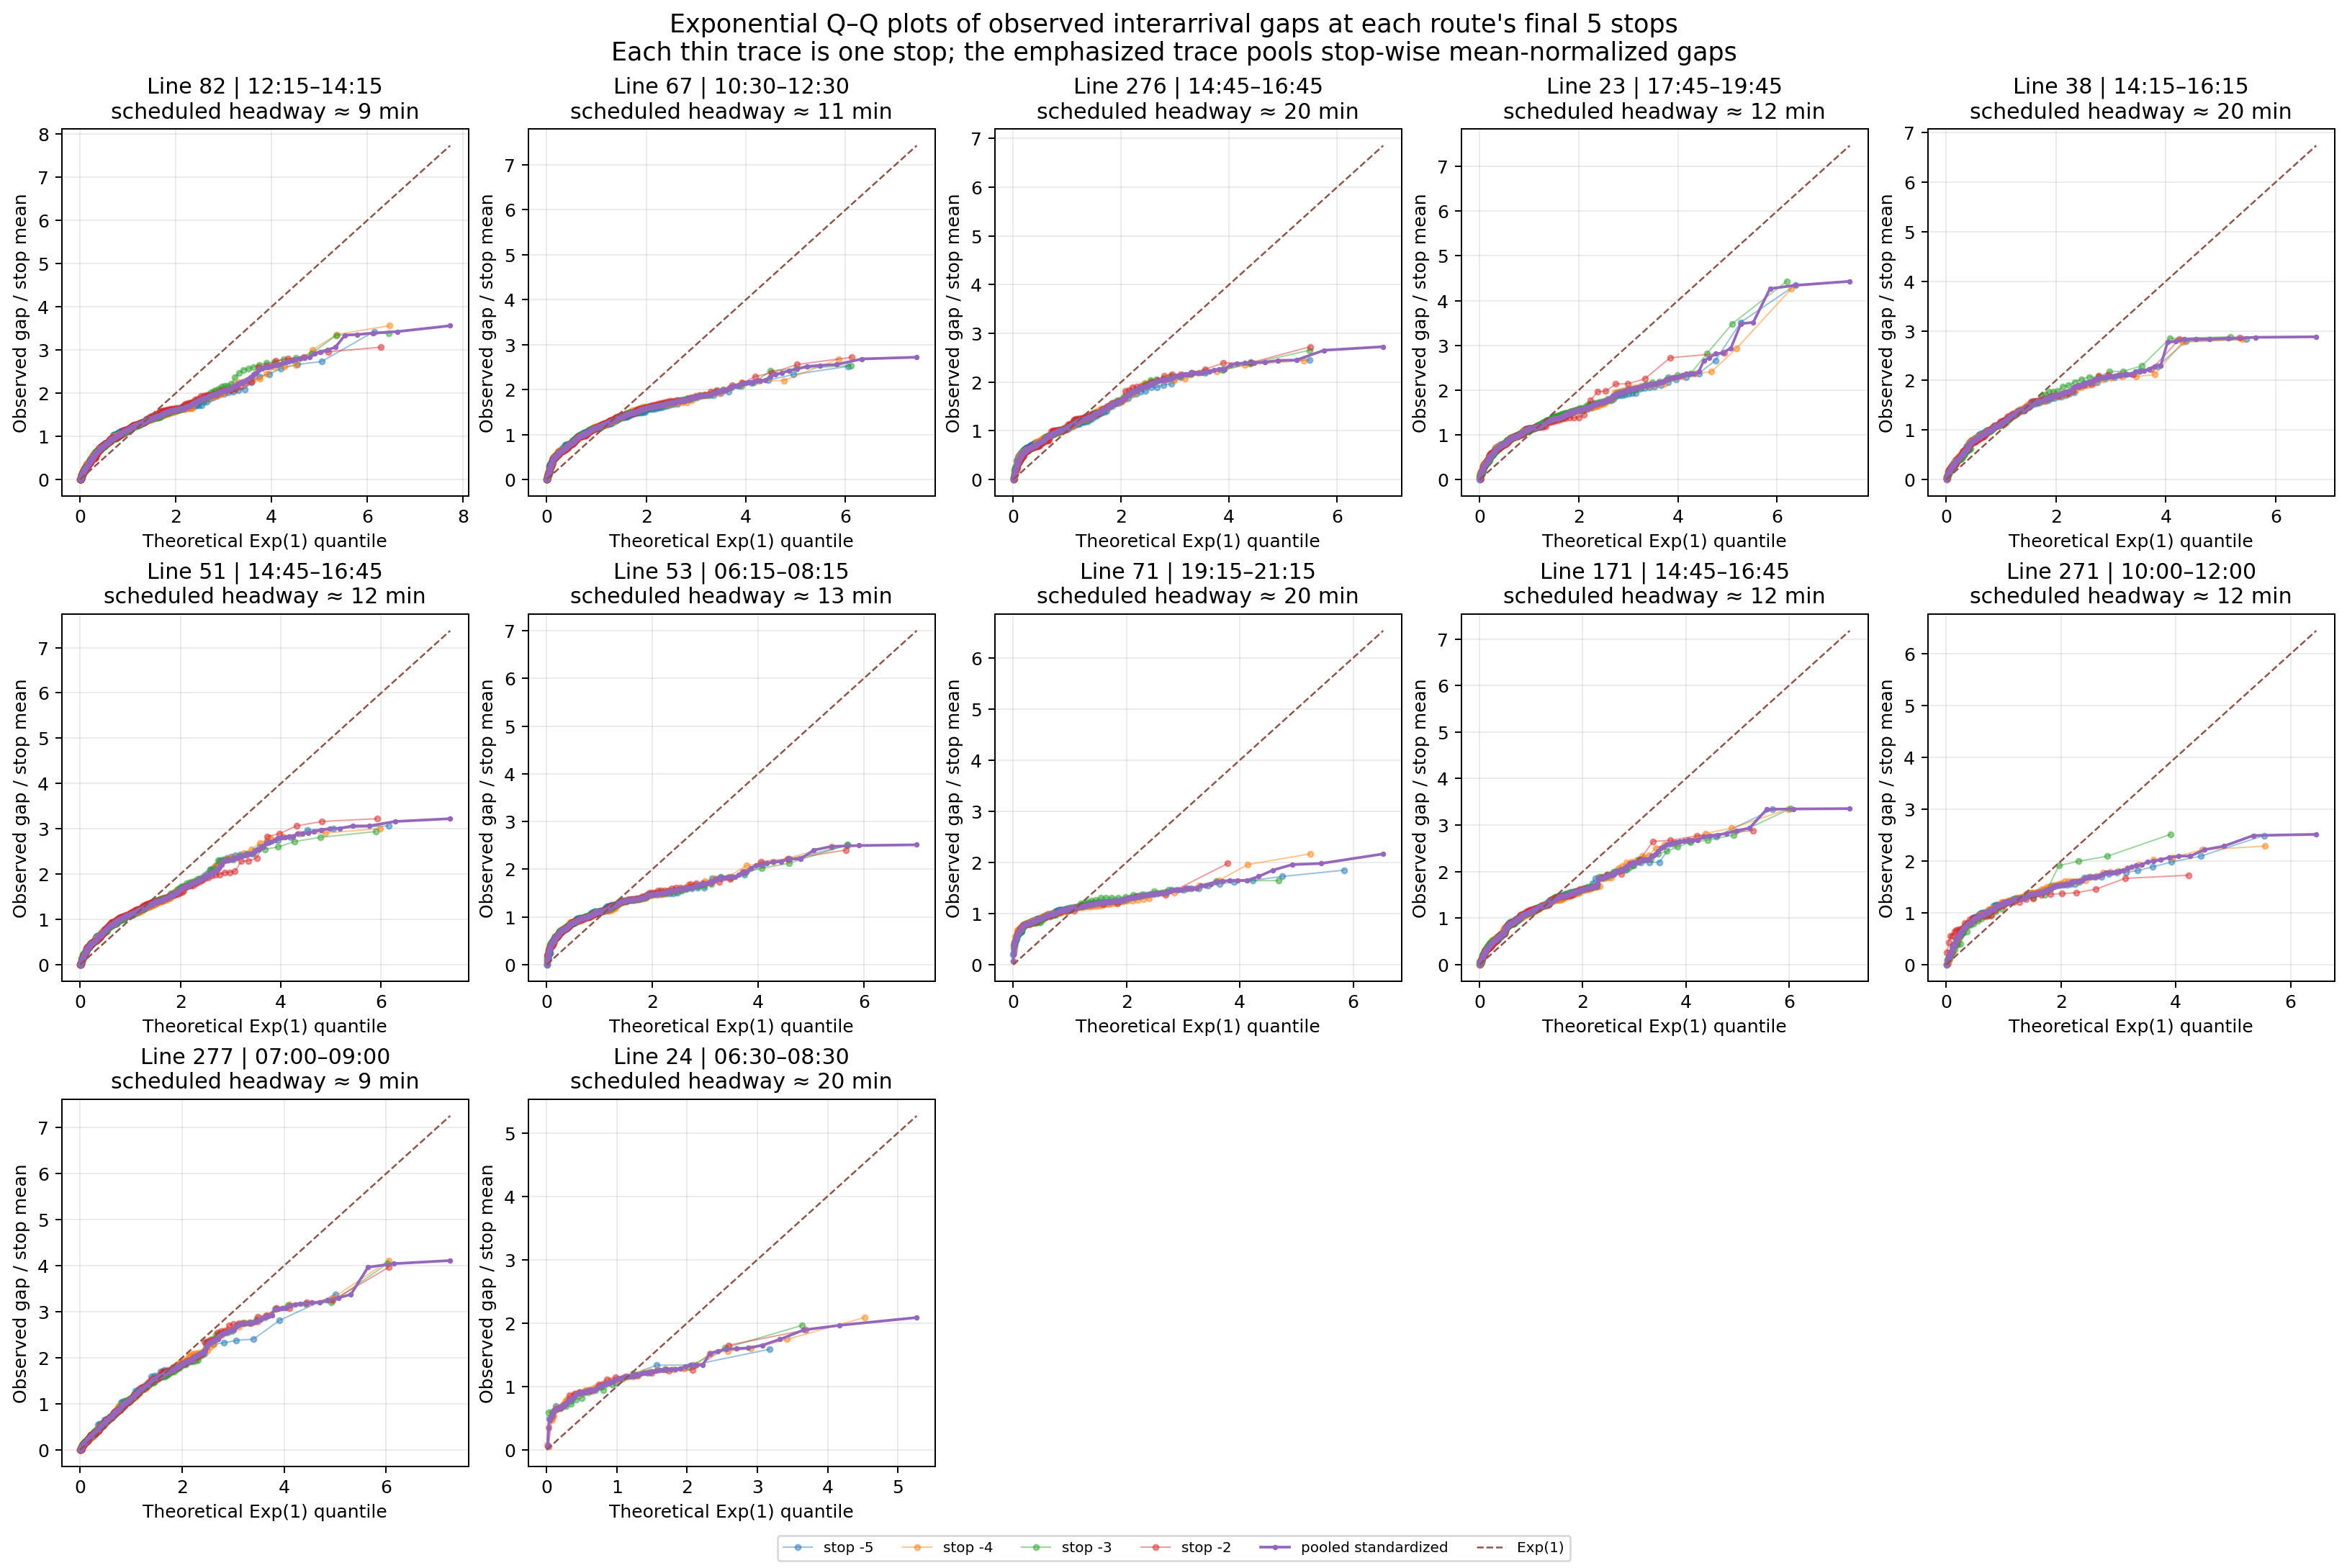

### Final-stop CV heatmap

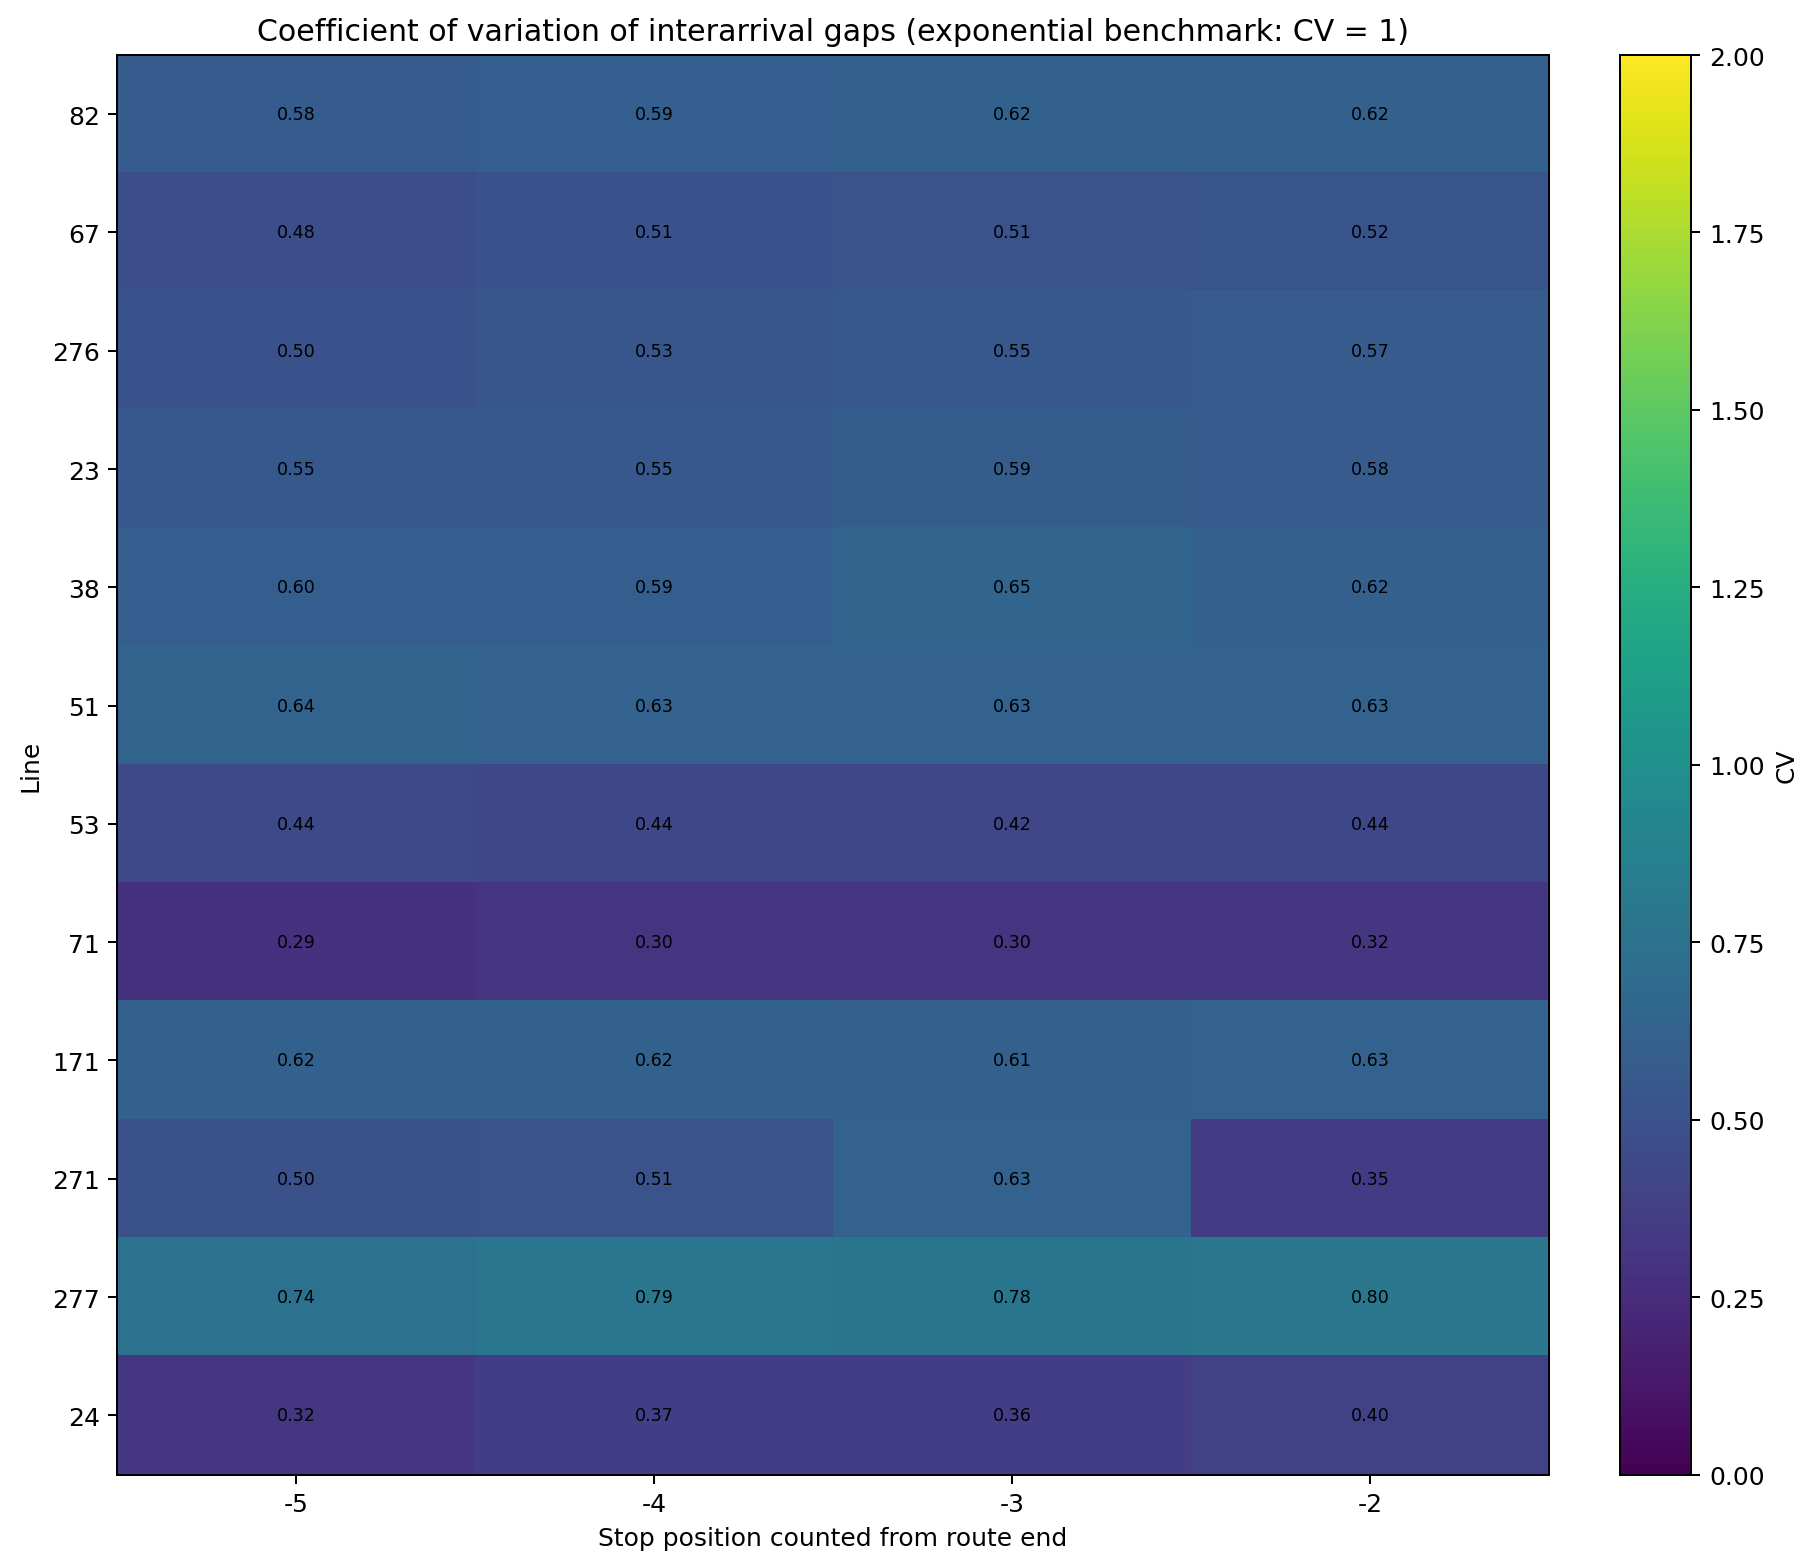

### CV as a function of stop index along each route

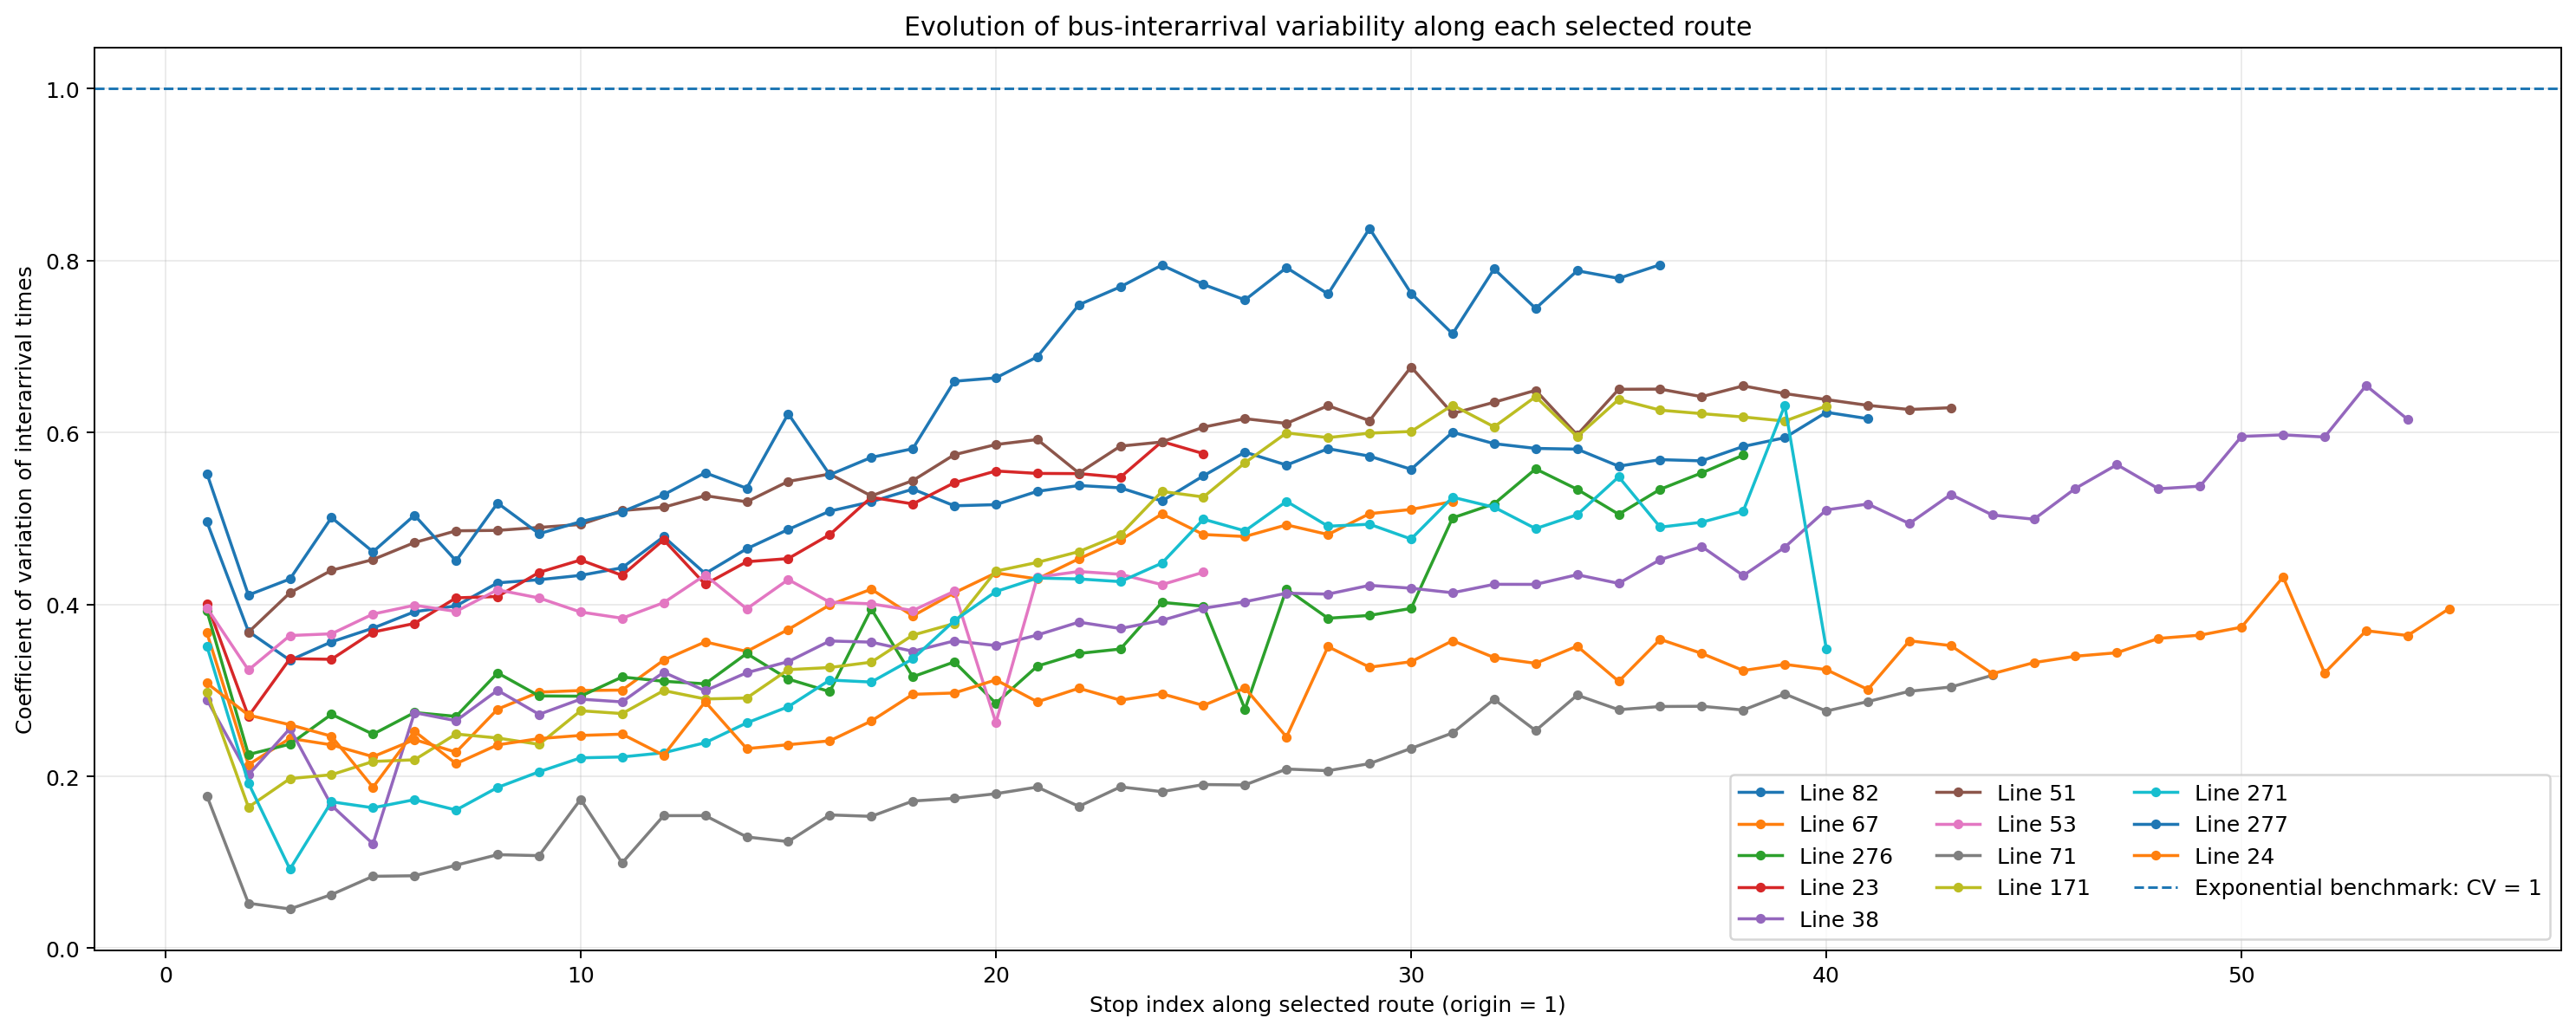

In [69]:
display(Markdown("### Exponential Q–Q plots at each route's final stops"))
display(Image(filename=str(qq_path)))

display(Markdown("### Final-stop CV heatmap"))
display(Image(filename=str(final_stop_cv_path)))

display(Markdown("### CV as a function of stop index along each route"))
display(Image(filename=str(route_cv_path)))


## 17b. Cumulative route distance & Weibull fit

Line 82: 15.54 km, using Cumulative great-circle distance between consecutive stops.
Line 67: 10.57 km, using Cumulative great-circle distance between consecutive stops.
Line 276: 30.87 km, using Cumulative great-circle distance between consecutive stops.
Line 23: 7.49 km, using Cumulative great-circle distance between consecutive stops.
Line 38: 21.66 km, using Cumulative great-circle distance between consecutive stops.
Line 51: 15.02 km, using Cumulative great-circle distance between consecutive stops.
Line 53: 9.69 km, using Cumulative great-circle distance between consecutive stops.
Line 71: 19.69 km, using Cumulative great-circle distance between consecutive stops.
Line 171: 18.29 km, using Cumulative great-circle distance between consecutive stops.
Line 271: 16.84 km, using Cumulative great-circle distance between consecutive stops.
Line 277: 28.29 km, using Cumulative great-circle distance between consecutive stops.
Line 24: 19.68 km, using Cumulative great-circle distance betwe

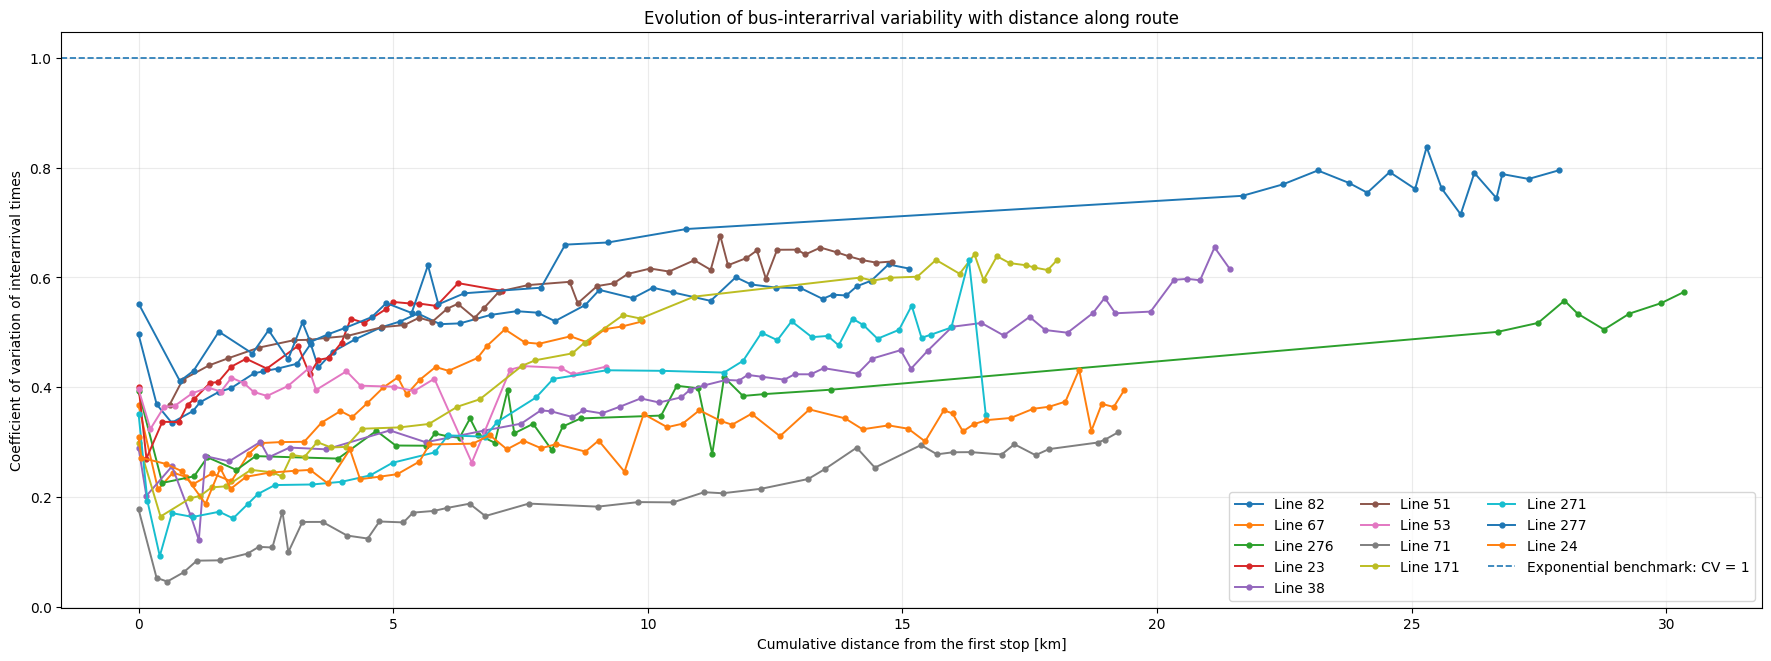


Saved:
 - /Users/yuvalgat/Desktop/Development/Python/Projects/talpiot-hackathon/open_bus_poisson_results/route_stop_cv_with_distance.csv
 - /Users/yuvalgat/Desktop/Development/Python/Projects/talpiot-hackathon/open_bus_poisson_results/cv_by_cumulative_distance.png


,line,line_ref,stop_index,route_stop_sequence,stop_code,stop_name,cumulative_distance_km,distance_method,n_gaps,cv
0,171,9872,1,1,26643,מסוף אזורי חן,0.000000,Cumulative great-circle distance between consecutive stops,299,0.297973
1,171,9872,2,2,26639,קדושי השואה/צבי פרופס,0.430858,Cumulative great-circle distance between consecutive stops,299,0.164086
2,171,9872,3,3,26649,שלמה בן יוסף/אבא אחימאיר,1.012346,Cumulative great-circle distance between consecutive stops,228,0.197275
3,171,9872,4,4,26688,אבא אחימאיר/אליהו בית צורי,1.212222,Cumulative great-circle distance between consecutive stops,188,0.201796
4,171,9872,5,5,26693,מרכז שוסטר/אבא אחימאיר,1.434437,Cumulative great-circle distance between consecutive stops,262,0.217243
...,...,...,...,...,...,...,...,...,...,...
479,82,2566,38,38,25556,המלך ג'ורג'/רש''י,14.104017,Cumulative great-circle distance between consecutive stops,233,0.583748
480,82,2566,39,39,20773,המלך ג'ורג'/אלנבי,14.388126,Cumulative great-circle distance between consecutive stops,320,0.593927
481,82,2566,40,40,20121,גאולה/הכובשים,14.725760,Cumulative great-circle distance between consecutive stops,318,0.623496
482,82,2566,41,41,20659,חוף בננה ביץ',15.122978,Cumulative great-circle distance between consecutive stops,270,0.616074


In [70]:
# ============================================================
# Plot interarrival CV against cumulative route distance
# ============================================================
#
# Required objects from earlier notebook cells:
#   client
#   selected
#   rides_cache
#   route_stop_cv
#   output_dir
#
# Output:
#   route_stop_cv_with_distance.csv
#   cv_by_cumulative_distance.png
#
# Distance definition:
#   1. Prefer GTFS shape_dist_traveled, relative to the first stop.
#   2. If unavailable, incomplete, or non-monotone, use the cumulative
#      great-circle distance between consecutive stop coordinates.
#
# The fallback is an approximation: it connects consecutive stops directly,
# rather than following the exact road geometry.
# ============================================================

import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display


def haversine_km(
    lat1: np.ndarray,
    lon1: np.ndarray,
    lat2: np.ndarray,
    lon2: np.ndarray,
) -> np.ndarray:
    """Vectorized great-circle distance in kilometres."""
    earth_radius_km = 6371.0088

    lat1 = np.radians(np.asarray(lat1, dtype=float))
    lon1 = np.radians(np.asarray(lon1, dtype=float))
    lat2 = np.radians(np.asarray(lat2, dtype=float))
    lon2 = np.radians(np.asarray(lon2, dtype=float))

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2.0) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    )
    a = np.clip(a, 0.0, 1.0)

    return 2.0 * earth_radius_km * np.arcsin(np.sqrt(a))


def cumulative_stop_to_stop_distance_km(stops: pd.DataFrame) -> np.ndarray:
    """
    Compute cumulative distance by connecting consecutive GTFS stops
    with great-circle segments.
    """
    lat = pd.to_numeric(stops["gtfs_stop__lat"], errors="coerce").to_numpy()
    lon = pd.to_numeric(stops["gtfs_stop__lon"], errors="coerce").to_numpy()

    if len(stops) == 0:
        return np.array([], dtype=float)

    segment_distances = np.zeros(len(stops), dtype=float)

    valid_pair = (
        np.isfinite(lat[:-1])
        & np.isfinite(lon[:-1])
        & np.isfinite(lat[1:])
        & np.isfinite(lon[1:])
    )

    segment_values = np.full(len(stops) - 1, np.nan, dtype=float)

    if valid_pair.any():
        segment_values[valid_pair] = haversine_km(
            lat[:-1][valid_pair],
            lon[:-1][valid_pair],
            lat[1:][valid_pair],
            lon[1:][valid_pair],
        )

    # A missing coordinate makes subsequent cumulative distance unknown.
    segment_distances[1:] = segment_values
    return np.cumsum(segment_distances)


def infer_shape_distance_scale_to_km(
    shape_distance_relative: np.ndarray,
    fallback_distance_km: np.ndarray,
) -> tuple[float, str]:
    """
    Infer whether shape_dist_traveled is most plausibly stored in metres
    or kilometres.

    The chosen conversion is the one whose total route distance is closer,
    on a multiplicative scale, to the cumulative stop-to-stop haversine
    distance.

    Returns
    -------
    scale_to_km, unit_description
    """
    shape_total = float(shape_distance_relative[-1])

    finite_fallback = fallback_distance_km[np.isfinite(fallback_distance_km)]
    fallback_total = (
        float(finite_fallback[-1])
        if len(finite_fallback) > 0
        else float("nan")
    )

    candidates = [
        (1.0, "shape_dist_traveled interpreted as kilometres"),
        (0.001, "shape_dist_traveled interpreted as metres"),
    ]

    # Without a usable geographic comparison, use a conservative magnitude
    # heuristic. Most complete urban routes measured in metres have values
    # well above 100 at their terminal stop.
    if not np.isfinite(fallback_total) or fallback_total <= 0:
        if shape_total > 100:
            return 0.001, candidates[1][1]
        return 1.0, candidates[0][1]

    def score(scale: float) -> float:
        converted_total = shape_total * scale
        if converted_total <= 0:
            return float("inf")

        # Absolute logarithmic ratio treats factors of 2 and 1/2 symmetrically.
        return abs(math.log(converted_total / fallback_total))

    return min(candidates, key=lambda candidate: score(candidate[0]))


def fetch_reference_stops_with_distance(
    client: StrideClient,
    route: SelectedRoute,
    route_rides: pd.DataFrame,
    max_rides_to_try: int = 20,
) -> pd.DataFrame:
    """
    Fetch an ordered reference stop sequence for one selected route pattern
    and attach cumulative distance from its first stop.
    """
    if route_rides.empty:
        raise ValueError(
            f"No GTFS rides are available for line "
            f"{route.identity.route_short_name}."
        )

    expected_sequences = list(route.route_stop_sequences)

    # Prefer rides from dates used in the selected constant-headway window.
    valid_dates = set(route.window.valid_dates)

    candidate_rides = route_rides.copy()

    if "service_date" in candidate_rides.columns:
        preferred = candidate_rides[
            candidate_rides["service_date"].astype(str).isin(valid_dates)
        ]
        if not preferred.empty:
            candidate_rides = preferred

    if "start_time" in candidate_rides.columns:
        candidate_rides = candidate_rides.sort_values("start_time")

    for ride_id in candidate_rides["id"].dropna().head(max_rides_to_try):
        records = client.list_all(
            "/gtfs_ride_stops/list",
            {
                "gtfs_ride_ids": str(int(ride_id)),
                "order_by": "stop_sequence",
            },
            page_size=500,
        )

        stops = pd.DataFrame(records)

        if stops.empty:
            continue

        required_columns = {
            "stop_sequence",
            "gtfs_stop__code",
            "gtfs_stop__name",
            "gtfs_stop__lat",
            "gtfs_stop__lon",
        }

        if not required_columns.issubset(stops.columns):
            continue

        stops = stops.dropna(
            subset=["stop_sequence", "gtfs_stop__code"]
        ).copy()

        stops["stop_sequence"] = pd.to_numeric(
            stops["stop_sequence"],
            errors="coerce",
        )
        stops = stops.dropna(subset=["stop_sequence"])
        stops["stop_sequence"] = stops["stop_sequence"].astype(int)

        stops = (
            stops.sort_values("stop_sequence")
            .drop_duplicates("stop_sequence")
            .reset_index(drop=True)
        )

        # Make sure this ride has the same route-stop pattern selected earlier.
        if stops["stop_sequence"].tolist() != expected_sequences:
            continue

        stops["stop_index"] = np.arange(1, len(stops) + 1)

        fallback_distance_km = cumulative_stop_to_stop_distance_km(stops)

        use_shape_distance = False
        distance_method = (
            "Cumulative great-circle distance between consecutive stops"
        )

        if "shape_dist_traveled" in stops.columns:
            raw_shape_distance = pd.to_numeric(
                stops["shape_dist_traveled"],
                errors="coerce",
            ).to_numpy(dtype=float)

            shape_complete = np.isfinite(raw_shape_distance).all()

            if shape_complete:
                relative_shape_distance = (
                    raw_shape_distance - raw_shape_distance[0]
                )

                shape_monotone = np.all(
                    np.diff(relative_shape_distance) >= -1e-9
                )
                shape_nonconstant = (
                    relative_shape_distance[-1] > 0
                )

                if shape_monotone and shape_nonconstant:
                    scale_to_km, unit_description = (
                        infer_shape_distance_scale_to_km(
                            relative_shape_distance,
                            fallback_distance_km,
                        )
                    )

                    stops["cumulative_distance_km"] = (
                        relative_shape_distance * scale_to_km
                    )
                    distance_method = unit_description
                    use_shape_distance = True

        if not use_shape_distance:
            stops["cumulative_distance_km"] = fallback_distance_km

        stops["distance_method"] = distance_method
        stops["reference_gtfs_ride_id"] = int(ride_id)
        stops["line"] = route.identity.route_short_name
        stops["line_ref"] = route.identity.line_ref

        return stops[
            [
                "line",
                "line_ref",
                "reference_gtfs_ride_id",
                "stop_index",
                "stop_sequence",
                "gtfs_stop__code",
                "gtfs_stop__name",
                "gtfs_stop__lat",
                "gtfs_stop__lon",
                "shape_dist_traveled",
                "cumulative_distance_km",
                "distance_method",
            ]
        ].copy()

    raise RuntimeError(
        f"Could not find a complete reference ride-stop sequence for "
        f"line {route.identity.route_short_name}."
    )


# ------------------------------------------------------------
# Build the distance table for every selected route
# ------------------------------------------------------------

distance_tables = []

for route in selected:
    route_rides = rides_cache.get(route.identity)

    if route_rides is None or route_rides.empty:
        print(
            f"Skipping line {route.identity.route_short_name}: "
            "no cached GTFS rides."
        )
        continue

    try:
        distance_part = fetch_reference_stops_with_distance(
            client=client,
            route=route,
            route_rides=route_rides,
        )
        distance_tables.append(distance_part)

        method = distance_part["distance_method"].iloc[0]
        terminal_distance = distance_part[
            "cumulative_distance_km"
        ].iloc[-1]

        print(
            f"Line {route.identity.route_short_name}: "
            f"{terminal_distance:.2f} km, using {method}."
        )

    except Exception as exc:
        print(
            f"Skipping line {route.identity.route_short_name}: {exc}"
        )

if not distance_tables:
    raise RuntimeError(
        "No route-distance tables could be constructed."
    )

route_stop_distances = pd.concat(
    distance_tables,
    ignore_index=True,
)


# ------------------------------------------------------------
# Merge cumulative distances into the existing CV table
# ------------------------------------------------------------

distance_columns = route_stop_distances[
    [
        "line_ref",
        "stop_sequence",
        "cumulative_distance_km",
        "distance_method",
        "gtfs_stop__lat",
        "gtfs_stop__lon",
        "reference_gtfs_ride_id",
    ]
].rename(
    columns={
        "stop_sequence": "route_stop_sequence",
    }
)

route_stop_cv_with_distance = route_stop_cv.merge(
    distance_columns,
    on=["line_ref", "route_stop_sequence"],
    how="left",
    validate="one_to_one",
)

route_stop_cv_with_distance = route_stop_cv_with_distance.sort_values(
    ["line", "stop_index"],
    key=lambda series: (
        series.astype(str)
        if series.name == "line"
        else series
    ),
)

distance_csv_path = (
    output_dir / "route_stop_cv_with_distance.csv"
)
route_stop_cv_with_distance.to_csv(
    distance_csv_path,
    index=False,
)


# ------------------------------------------------------------
# Plot every requested line on the same axes
# ------------------------------------------------------------

fig_width = max(
    11.0,
    min(18.0, 8.0 + 0.8 * len(selected)),
)

fig, ax = plt.subplots(
    figsize=(fig_width, 6.5),
    constrained_layout=True,
)

for route in selected:
    part = route_stop_cv_with_distance[
        route_stop_cv_with_distance["line_ref"]
        == route.identity.line_ref
    ].sort_values("cumulative_distance_km")

    part = part[
        np.isfinite(part["cumulative_distance_km"])
    ]

    if part.empty:
        continue

    ax.plot(
        part["cumulative_distance_km"],
        part["cv"],
        marker="o",
        markersize=3.5,
        linewidth=1.4,
        label=f"Line {route.identity.route_short_name}",
    )

ax.axhline(
    1.0,
    linestyle="--",
    linewidth=1.2,
    label="Exponential benchmark: CV = 1",
)

ax.set_xlabel(
    "Cumulative distance from the first stop [km]"
)
ax.set_ylabel(
    "Coefficient of variation of interarrival times"
)
ax.set_title(
    "Evolution of bus-interarrival variability with distance along route"
)
ax.grid(alpha=0.25)
ax.legend(
    loc="best",
    ncol=max(1, min(3, len(selected) + 1)),
)

distance_plot_path = (
    output_dir / "cv_by_cumulative_distance.png"
)

fig.savefig(
    distance_plot_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print()
print("Saved:")
print(" -", distance_csv_path.resolve())
print(" -", distance_plot_path.resolve())

display(
    route_stop_cv_with_distance[
        [
            "line",
            "line_ref",
            "stop_index",
            "route_stop_sequence",
            "stop_code",
            "stop_name",
            "cumulative_distance_km",
            "distance_method",
            "n_gaps",
            "cv",
        ]
    ]
)

,line,line_ref,scheduled_headway_minutes
0,82,2566,9.0
1,67,2538,11.0
2,276,32425,20.0
3,23,2358,12.0
4,38,18632,20.0
5,51,2492,12.0
6,53,25958,13.0
7,71,9847,20.0
8,171,9872,12.0
9,271,9877,12.0


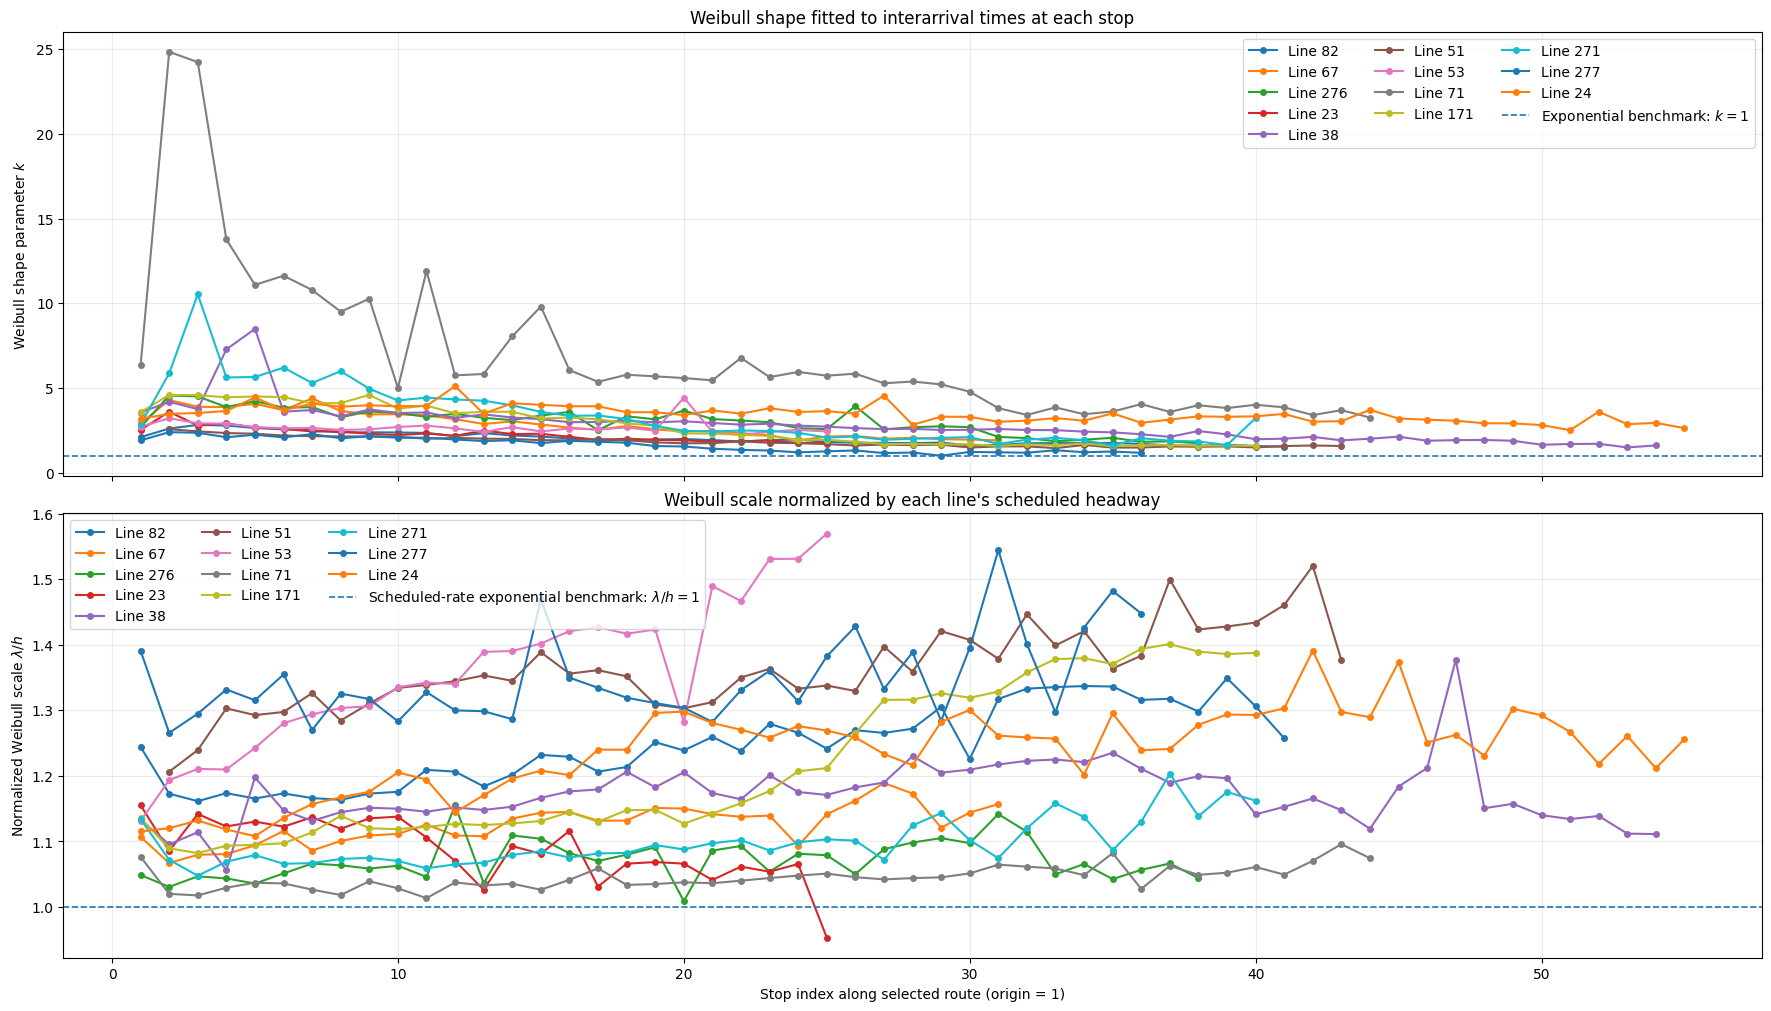

Successful fits:


,successful_fits,total_stops
line,,
171,40,40
23,25,25
24,55,55
271,40,40
276,38,38
277,36,36
38,54,54
51,42,42
53,25,25


Saved:
 - /Users/yuvalgat/Desktop/Development/Python/Projects/talpiot-hackathon/open_bus_poisson_results/weibull_parameters_by_stop_normalized.csv
 - /Users/yuvalgat/Desktop/Development/Python/Projects/talpiot-hackathon/open_bus_poisson_results/weibull_parameters_normalized_by_stop_index.png


,line,line_ref,stop_index,stop_code,stop_name,scheduled_headway_minutes,n_gaps_fit,sample_mean_minutes,sample_mean_over_headway,sample_cv,weibull_shape,weibull_scale_minutes,weibull_scale_over_headway,weibull_mean_minutes,weibull_mean_over_headway,weibull_cv,aic,fit_success
0,171,9872,1,26643,מסוף אזורי חן,12.0,299,12.312207,1.026017,0.297973,3.570069,13.628724,1.135727,12.275392,1.022949,0.310861,1634.905976,True
1,171,9872,2,26639,קדושי השואה/צבי פרופס,12.0,299,12.214493,1.017874,0.164086,4.587842,13.071353,1.089279,11.941967,0.995164,0.247738,1399.337875,True
2,171,9872,3,26649,שלמה בן יוסף/אבא אחימאיר,12.0,228,12.053216,1.004435,0.197275,4.573548,12.985512,1.082126,11.861392,0.988449,0.248442,1093.183150,True
3,171,9872,4,26688,אבא אחימאיר/אליהו בית צורי,12.0,188,12.157979,1.013165,0.201796,4.448006,13.121482,1.093457,11.966241,0.997187,0.254808,915.739786,True
4,171,9872,5,26693,מרכז שוסטר/אבא אחימאיר,12.0,262,12.146374,1.012198,0.217243,4.494005,13.135179,1.094598,11.985885,0.998824,0.252437,1296.626130,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466,82,2566,37,21543,המלך ג'ורג'/בוגרשוב,9.0,136,10.828922,1.203214,0.566977,1.606171,11.858320,1.317591,10.628130,1.180903,0.637656,888.080647,True
467,82,2566,38,25556,המלך ג'ורג'/רש''י,9.0,233,10.647639,1.183071,0.583748,1.586384,11.683424,1.298158,10.483464,1.164829,0.644931,1512.804227,True
468,82,2566,39,20773,המלך ג'ורג'/אלנבי,9.0,320,10.957187,1.217465,0.593927,1.643818,12.140614,1.348957,10.859558,1.206618,0.624303,2078.269425,True
469,82,2566,40,20121,גאולה/הכובשים,9.0,318,10.635797,1.181755,0.623496,1.569541,11.753990,1.305999,10.557819,1.173091,0.651269,2061.552239,True


In [71]:
# ============================================================
# Fit Weibull distributions at every stop and plot:
#   1. Weibull shape k
#   2. Weibull scale normalized by the line's scheduled headway
#
# Required objects from earlier notebook cells:
#   all_stop_gaps
#   selected
#   output_dir
#
# Optional:
#   route_stop_cv_with_distance
#       Required only when X_AXIS = "cumulative_distance_km"
#
# Weibull parameterization:
#
#   X ~ Weibull(shape=k, scale=lambda, location=0)
#
# Normalized scale:
#
#   lambda_normalized = lambda / scheduled_modal_headway
#
# Reference exponential process with the scheduled rate:
#
#   k = 1
#   lambda / headway = 1
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.special import gamma
from IPython.display import display


# ------------------------------------------------------------
# User settings
# ------------------------------------------------------------

# Choose:
#   "stop_index"
# or:
#   "cumulative_distance_km"
X_AXIS = "stop_index"

# Minimum number of positive interarrival gaps required for a fit.
MIN_GAPS_PER_STOP = 8

# Optional upper-tail trimming before fitting.
# Keep None to use all gaps retained by the main analysis.
UPPER_GAP_QUANTILE = None
# Example:
# UPPER_GAP_QUANTILE = 0.99


# ------------------------------------------------------------
# Line-specific scheduled headways
# ------------------------------------------------------------

headway_records = []

for route in selected:
    headway = float(route.window.modal_headway_minutes)

    if not np.isfinite(headway) or headway <= 0:
        raise ValueError(
            f"Invalid scheduled modal headway for "
            f"line {route.identity.route_short_name}: {headway}"
        )

    headway_records.append(
        {
            "line": str(route.identity.route_short_name),
            "line_ref": int(route.identity.line_ref),
            "scheduled_headway_minutes": headway,
        }
    )

line_headways = pd.DataFrame(headway_records).drop_duplicates(
    subset=["line_ref"]
)

display(line_headways)


# ------------------------------------------------------------
# Fit one two-parameter Weibull distribution per stop
# ------------------------------------------------------------

def fit_weibull_at_stops(
    gaps,
    line_headways,
    min_gaps=8,
    upper_gap_quantile=None,
):
    """
    Fit a Weibull distribution independently at every route stop.

    The location parameter is fixed at zero.

    Returns both:
        lambda in minutes
        lambda / scheduled line headway
    """
    required_columns = {
        "line",
        "line_ref",
        "stop_index",
        "route_stop_sequence",
        "stop_code",
        "stop_name",
        "gap_minutes",
    }

    missing = required_columns - set(gaps.columns)
    if missing:
        raise KeyError(
            f"all_stop_gaps is missing required columns: "
            f"{sorted(missing)}"
        )

    headway_lookup = (
        line_headways
        .set_index("line_ref")["scheduled_headway_minutes"]
        .to_dict()
    )

    group_columns = [
        "line",
        "line_ref",
        "stop_index",
        "route_stop_sequence",
        "stop_code",
        "stop_name",
    ]

    rows = []

    for keys, group in gaps.groupby(
        group_columns,
        dropna=False,
        sort=False,
    ):
        (
            line,
            line_ref,
            stop_index,
            route_stop_sequence,
            stop_code,
            stop_name,
        ) = keys

        line_ref = int(line_ref)

        if line_ref not in headway_lookup:
            raise KeyError(
                f"No scheduled headway found for line_ref={line_ref}."
            )

        scheduled_headway = float(headway_lookup[line_ref])

        values = pd.to_numeric(
            group["gap_minutes"],
            errors="coerce",
        ).to_numpy(dtype=float)

        values = values[
            np.isfinite(values) & (values > 0)
        ]

        n_raw = len(values)

        if upper_gap_quantile is not None:
            if not 0 < upper_gap_quantile <= 1:
                raise ValueError(
                    "UPPER_GAP_QUANTILE must lie in (0, 1]."
                )

            if n_raw > 0:
                cutoff = float(
                    np.quantile(
                        values,
                        upper_gap_quantile,
                    )
                )
                fit_values = values[values <= cutoff]
            else:
                cutoff = np.nan
                fit_values = values
        else:
            cutoff = np.nan
            fit_values = values

        n_fit = len(fit_values)

        sample_mean = (
            float(np.mean(fit_values))
            if n_fit > 0
            else np.nan
        )

        sample_std = (
            float(np.std(fit_values, ddof=1))
            if n_fit > 1
            else np.nan
        )

        sample_cv = (
            sample_std / sample_mean
            if (
                np.isfinite(sample_std)
                and np.isfinite(sample_mean)
                and sample_mean > 0
            )
            else np.nan
        )

        result = {
            "line": str(line),
            "line_ref": line_ref,
            "stop_index": int(stop_index),
            "route_stop_sequence": int(route_stop_sequence),
            "stop_code": stop_code,
            "stop_name": stop_name,
            "scheduled_headway_minutes": scheduled_headway,
            "n_gaps_raw": n_raw,
            "n_gaps_fit": n_fit,
            "upper_trim_cutoff_minutes": cutoff,
            "sample_mean_minutes": sample_mean,
            "sample_mean_over_headway": (
                sample_mean / scheduled_headway
                if np.isfinite(sample_mean)
                else np.nan
            ),
            "sample_std_minutes": sample_std,
            "sample_cv": sample_cv,
            "weibull_shape": np.nan,
            "weibull_scale_minutes": np.nan,
            "weibull_scale_over_headway": np.nan,
            "weibull_mean_minutes": np.nan,
            "weibull_mean_over_headway": np.nan,
            "weibull_std_minutes": np.nan,
            "weibull_cv": np.nan,
            "log_likelihood": np.nan,
            "aic": np.nan,
            "fit_success": False,
        }

        if n_fit < min_gaps:
            rows.append(result)
            continue

        try:
            # Two-parameter Weibull MLE:
            # shape and scale are fitted; location is fixed at zero.
            shape, location, scale = stats.weibull_min.fit(
                fit_values,
                floc=0,
            )

            valid_fit = (
                np.isfinite(shape)
                and np.isfinite(scale)
                and shape > 0
                and scale > 0
            )

            if not valid_fit:
                rows.append(result)
                continue

            fitted_mean = float(
                scale * gamma(1.0 + 1.0 / shape)
            )

            fitted_variance = float(
                scale**2
                * (
                    gamma(1.0 + 2.0 / shape)
                    - gamma(1.0 + 1.0 / shape) ** 2
                )
            )

            fitted_variance = max(fitted_variance, 0.0)
            fitted_std = float(np.sqrt(fitted_variance))

            fitted_cv = (
                fitted_std / fitted_mean
                if fitted_mean > 0
                else np.nan
            )

            log_likelihood = float(
                np.sum(
                    stats.weibull_min.logpdf(
                        fit_values,
                        c=shape,
                        loc=0,
                        scale=scale,
                    )
                )
            )

            # Two fitted parameters: shape and scale.
            aic = 2 * 2 - 2 * log_likelihood

            result.update(
                {
                    "weibull_shape": float(shape),
                    "weibull_scale_minutes": float(scale),
                    "weibull_scale_over_headway": (
                        float(scale) / scheduled_headway
                    ),
                    "weibull_mean_minutes": fitted_mean,
                    "weibull_mean_over_headway": (
                        fitted_mean / scheduled_headway
                    ),
                    "weibull_std_minutes": fitted_std,
                    "weibull_cv": float(fitted_cv),
                    "log_likelihood": log_likelihood,
                    "aic": float(aic),
                    "fit_success": True,
                }
            )

        except Exception as exc:
            print(
                f"Weibull fit failed for line {line}, "
                f"stop {stop_index}: {exc}"
            )

        rows.append(result)

    results = pd.DataFrame(rows)

    return (
        results
        .sort_values(
            ["line", "stop_index"],
            key=lambda column: (
                column.astype(str)
                if column.name == "line"
                else column
            ),
        )
        .reset_index(drop=True)
    )


weibull_stop_results = fit_weibull_at_stops(
    gaps=all_stop_gaps,
    line_headways=line_headways,
    min_gaps=MIN_GAPS_PER_STOP,
    upper_gap_quantile=UPPER_GAP_QUANTILE,
)


# ------------------------------------------------------------
# Attach cumulative distance when requested
# ------------------------------------------------------------

if X_AXIS == "cumulative_distance_km":
    if "route_stop_cv_with_distance" not in globals():
        raise RuntimeError(
            "X_AXIS is 'cumulative_distance_km', but "
            "route_stop_cv_with_distance does not exist. "
            "Run the cumulative-distance block first."
        )

    distance_lookup = (
        route_stop_cv_with_distance[
            [
                "line_ref",
                "stop_index",
                "cumulative_distance_km",
            ]
        ]
        .drop_duplicates(
            subset=["line_ref", "stop_index"]
        )
    )

    weibull_stop_results = weibull_stop_results.merge(
        distance_lookup,
        on=["line_ref", "stop_index"],
        how="left",
        validate="one_to_one",
    )

    x_column = "cumulative_distance_km"
    x_label = "Cumulative distance from first stop [km]"

elif X_AXIS == "stop_index":
    x_column = "stop_index"
    x_label = "Stop index along selected route (origin = 1)"

else:
    raise ValueError(
        "X_AXIS must be either 'stop_index' "
        "or 'cumulative_distance_km'."
    )


# ------------------------------------------------------------
# Save fitted parameter table
# ------------------------------------------------------------

weibull_csv_path = (
    output_dir / "weibull_parameters_by_stop_normalized.csv"
)

weibull_stop_results.to_csv(
    weibull_csv_path,
    index=False,
)


# ------------------------------------------------------------
# Plot shape and normalized scale
# ------------------------------------------------------------

fig_width = max(
    11.0,
    min(18.0, 8.0 + 0.8 * len(selected)),
)

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(fig_width, 10),
    sharex=True,
    constrained_layout=True,
)

shape_ax, scale_ax = axes


for route in selected:
    line_ref = int(route.identity.line_ref)
    short_name = str(route.identity.route_short_name)

    part = weibull_stop_results[
        (weibull_stop_results["line_ref"] == line_ref)
        & weibull_stop_results["fit_success"]
        & np.isfinite(
            weibull_stop_results[x_column]
        )
    ].sort_values(x_column)

    if part.empty:
        print(
            f"No valid Weibull fits for line {short_name}."
        )
        continue

    shape_ax.plot(
        part[x_column],
        part["weibull_shape"],
        marker="o",
        markersize=4,
        linewidth=1.5,
        label=f"Line {short_name}",
    )

    scale_ax.plot(
        part[x_column],
        part["weibull_scale_over_headway"],
        marker="o",
        markersize=4,
        linewidth=1.5,
        label=f"Line {short_name}",
    )


# For an exponential distribution, Weibull shape = 1.
shape_ax.axhline(
    1.0,
    linestyle="--",
    linewidth=1.2,
    label="Exponential benchmark: $k=1$",
)

# For an exponential process whose mean equals the scheduled
# line headway, Weibull scale / scheduled headway = 1.
scale_ax.axhline(
    1.0,
    linestyle="--",
    linewidth=1.2,
    label=(
        "Scheduled-rate exponential benchmark: "
        "$\\lambda/h=1$"
    ),
)


shape_ax.set_ylabel("Weibull shape parameter $k$")
shape_ax.set_title(
    "Weibull shape fitted to interarrival times at each stop"
)
shape_ax.grid(alpha=0.25)
shape_ax.legend(
    loc="best",
    ncol=max(
        1,
        min(3, len(selected) + 1),
    ),
)


scale_ax.set_xlabel(x_label)
scale_ax.set_ylabel(
    "Normalized Weibull scale $\\lambda/h$"
)
scale_ax.set_title(
    "Weibull scale normalized by each line's scheduled headway"
)
scale_ax.grid(alpha=0.25)
scale_ax.legend(
    loc="best",
    ncol=max(
        1,
        min(3, len(selected) + 1),
    ),
)


weibull_plot_path = (
    output_dir
    / (
        "weibull_parameters_normalized_by_distance.png"
        if X_AXIS == "cumulative_distance_km"
        else "weibull_parameters_normalized_by_stop_index.png"
    )
)

fig.savefig(
    weibull_plot_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

fit_counts = (
    weibull_stop_results
    .groupby("line")["fit_success"]
    .agg(successful_fits="sum", total_stops="count")
)

print("Successful fits:")
display(fit_counts)

print("Saved:")
print(" -", weibull_csv_path.resolve())
print(" -", weibull_plot_path.resolve())

display_columns = [
    "line",
    "line_ref",
    "stop_index",
    "stop_code",
    "stop_name",
    "scheduled_headway_minutes",
    "n_gaps_fit",
    "sample_mean_minutes",
    "sample_mean_over_headway",
    "sample_cv",
    "weibull_shape",
    "weibull_scale_minutes",
    "weibull_scale_over_headway",
    "weibull_mean_minutes",
    "weibull_mean_over_headway",
    "weibull_cv",
    "aic",
    "fit_success",
]

if "cumulative_distance_km" in weibull_stop_results.columns:
    display_columns.insert(
        3,
        "cumulative_distance_km",
    )

display(
    weibull_stop_results[display_columns]
)

## Average Waiting Time

Maximum numerical difference between formulas: 6.661e-16
Operator marker mapping:
  דן: o
  אגד: s
  מטרופולין: ^


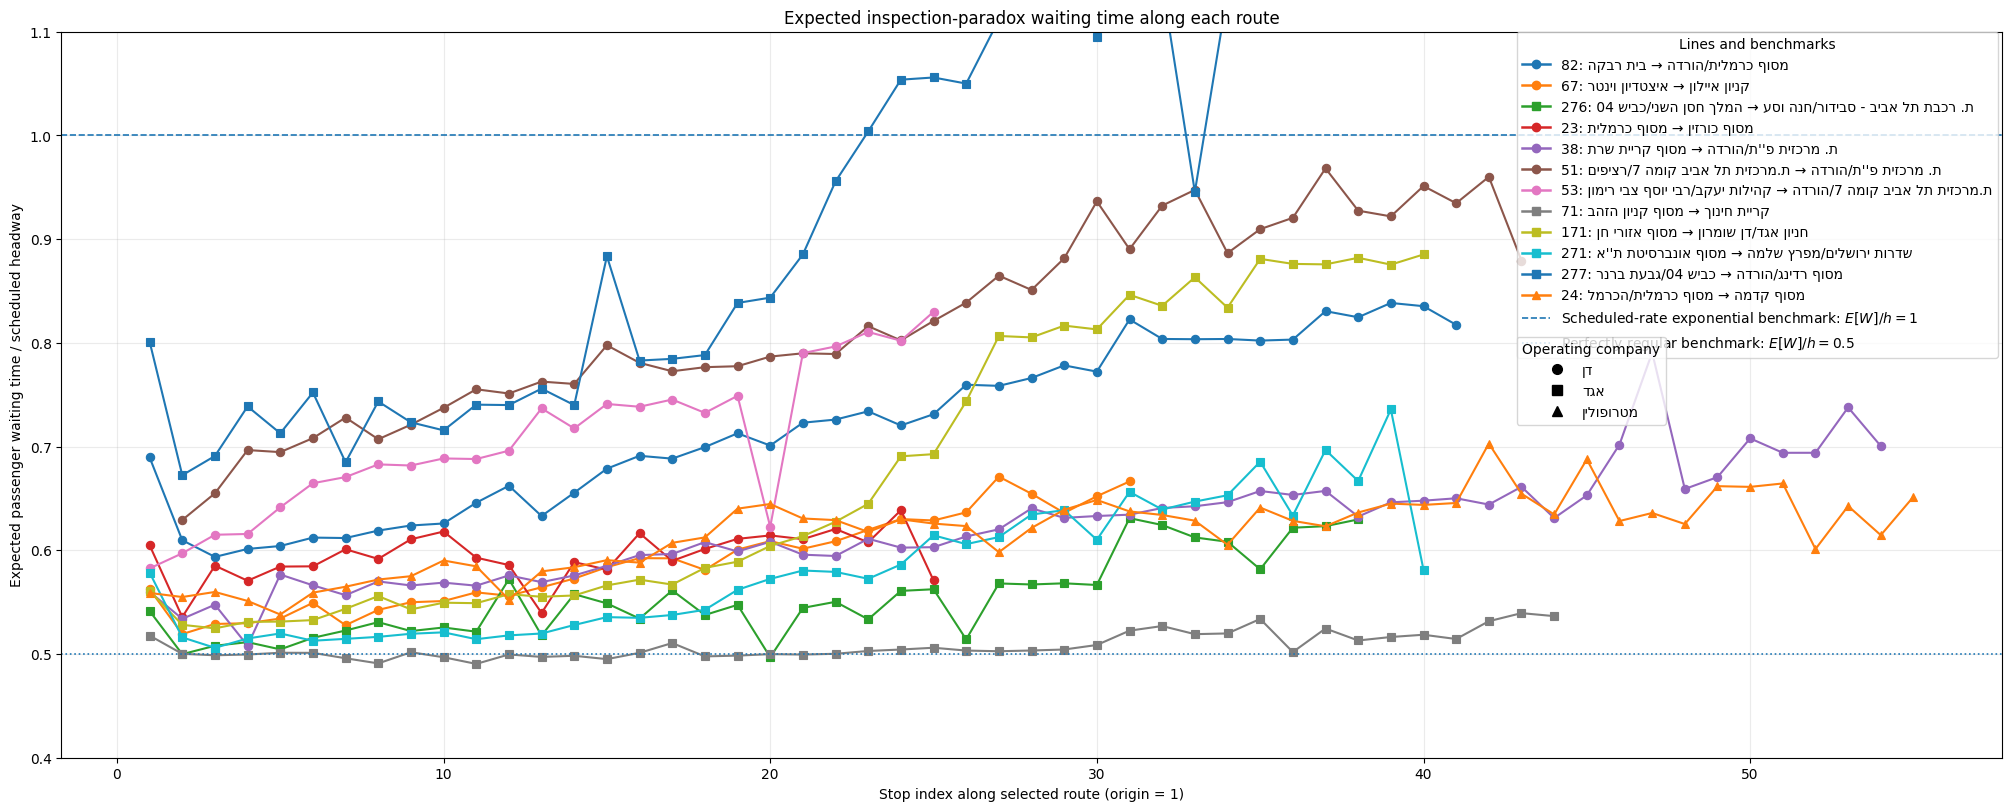

Saved:
 - /Users/yuvalgat/Desktop/Development/Python/Projects/talpiot-hackathon/open_bus_poisson_results/expected_wait_over_headway_by_stop_company_markers.png
Saved:
 - /Users/yuvalgat/Desktop/Development/Python/Projects/talpiot-hackathon/open_bus_poisson_results/expected_waiting_time_by_stop.csv
 - /Users/yuvalgat/Desktop/Development/Python/Projects/talpiot-hackathon/open_bus_poisson_results/expected_wait_over_headway_by_stop_company_markers.png


,line,line_ref,stop_index,stop_code,stop_name,n_gaps_fit,scheduled_headway_minutes,weibull_shape,weibull_scale_over_headway,weibull_mean_over_headway,weibull_cv,expected_wait_minutes,expected_wait_over_headway,fit_success
0,171,9872,1,26643,מסוף אזורי חן,299,12.0,3.570069,1.135727,1.022949,0.310861,6.730811,0.560901,True
1,171,9872,2,26639,קדושי השואה/צבי פרופס,299,12.0,4.587842,1.089279,0.995164,0.247738,6.337446,0.528120,True
2,171,9872,3,26649,שלמה בן יוסף/אבא אחימאיר,228,12.0,4.573548,1.082126,0.988449,0.248442,6.296758,0.524730,True
3,171,9872,4,26688,אבא אחימאיר/אליהו בית צורי,188,12.0,4.448006,1.093457,0.997187,0.254808,6.371587,0.530966,True
4,171,9872,5,26693,מרכז שוסטר/אבא אחימאיר,262,12.0,4.494005,1.094598,0.998824,0.252437,6.374839,0.531237,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466,82,2566,37,21543,המלך ג'ורג'/בוגרשוב,136,9.0,1.606171,1.317591,1.180903,0.637656,7.474792,0.830532,True
467,82,2566,38,25556,המלך ג'ורג'/רש''י,233,9.0,1.586384,1.298158,1.164829,0.644931,7.421954,0.824662,True
468,82,2566,39,20773,המלך ג'ורג'/אלנבי,320,9.0,1.643818,1.348957,1.206618,0.624303,7.546061,0.838451,True
469,82,2566,40,20121,גאולה/הכובשים,318,9.0,1.569541,1.305999,1.173091,0.651269,7.517963,0.835329,True


In [72]:
# ============================================================
# Plot expected stationary passenger waiting time normalized
# by scheduled headway, E[W] / h, at every route stop
# ============================================================
#
# Required from the previous Weibull-fitting cell:
#   weibull_stop_results
#   selected
#   output_dir
#
# Assumption:
#   At each stop, interarrival times form a stationary renewal
#   process with the fitted Weibull(k, lambda) distribution.
#
# For a random passenger arrival:
#
#   E[W] = E[X^2] / (2 E[X])
#
# For X ~ Weibull(k, lambda):
#
#   E[W] / h
#       = (lambda / h)
#         * Gamma(1 + 2/k)
#         / (2 Gamma(1 + 1/k))
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.special import gammaln
from IPython.display import display


required_columns = {
    "line",
    "line_ref",
    "stop_index",
    "stop_code",
    "stop_name",
    "scheduled_headway_minutes",
    "weibull_shape",
    "weibull_scale_minutes",
    "weibull_scale_over_headway",
    "fit_success",
}

missing_columns = required_columns - set(weibull_stop_results.columns)

if missing_columns:
    raise KeyError(
        "weibull_stop_results is missing required columns: "
        f"{sorted(missing_columns)}"
    )


waiting_time_results = weibull_stop_results.copy()

k = pd.to_numeric(
    waiting_time_results["weibull_shape"],
    errors="coerce",
).to_numpy(dtype=float)

lambda_over_h = pd.to_numeric(
    waiting_time_results["weibull_scale_over_headway"],
    errors="coerce",
).to_numpy(dtype=float)


# Compute using log-gamma functions for numerical stability:
#
# log(E[W]/h)
#   = log(lambda/h)
#     + log Gamma(1 + 2/k)
#     - log 2
#     - log Gamma(1 + 1/k)

valid = (
    waiting_time_results["fit_success"].to_numpy(dtype=bool)
    & np.isfinite(k)
    & (k > 0)
    & np.isfinite(lambda_over_h)
    & (lambda_over_h > 0)
)

expected_wait_over_headway = np.full(
    len(waiting_time_results),
    np.nan,
    dtype=float,
)

log_expected_wait_over_headway = (
    np.log(lambda_over_h[valid])
    + gammaln(1.0 + 2.0 / k[valid])
    - np.log(2.0)
    - gammaln(1.0 + 1.0 / k[valid])
)

expected_wait_over_headway[valid] = np.exp(
    log_expected_wait_over_headway
)

waiting_time_results["expected_wait_over_headway"] = (
    expected_wait_over_headway
)

waiting_time_results["expected_wait_minutes"] = (
    waiting_time_results["expected_wait_over_headway"]
    * waiting_time_results["scheduled_headway_minutes"]
)


# This equivalent expression is useful diagnostically:
#
#   E[W] / h
#       = (E[X] / h) * (1 + CV(X)^2) / 2

if {
    "weibull_mean_over_headway",
    "weibull_cv",
}.issubset(waiting_time_results.columns):
    waiting_time_results[
        "expected_wait_over_headway_from_moments"
    ] = (
        waiting_time_results["weibull_mean_over_headway"]
        * (
            1.0
            + waiting_time_results["weibull_cv"] ** 2
        )
        / 2.0
    )

    numerical_difference = np.abs(
        waiting_time_results["expected_wait_over_headway"]
        - waiting_time_results[
            "expected_wait_over_headway_from_moments"
        ]
    )

    finite_difference = numerical_difference[
        np.isfinite(numerical_difference)
    ]

    if not finite_difference.empty:
        print(
            "Maximum numerical difference between formulas:",
            f"{finite_difference.max():.3e}",
        )


# ------------------------------------------------------------
# Save the calculated waiting-time table
# ------------------------------------------------------------

waiting_csv_path = (
    output_dir / "expected_waiting_time_by_stop.csv"
)

waiting_time_results.to_csv(
    waiting_csv_path,
    index=False,
)

import re


def reverse_hebrew(text):
    """
    Reverse strings containing Hebrew characters for Matplotlib display.

    This follows the simple [::-1] convention used elsewhere in the notebook.
    """
    if text is None or pd.isna(text):
        return "Unknown stop"

    text = str(text).strip()

    if re.search(r"[\u0590-\u05FF]", text):
        return text[::-1]

    return text


def route_endpoints(route):
    """
    Return the displayed first and last stop names for a selected route.

    Prefer the complete route-stop table, because waiting_time_results may
    exclude stops for which no Weibull fit was available.
    """
    line_ref = int(route.identity.line_ref)

    if "route_stop_cv_with_distance" in globals():
        source = route_stop_cv_with_distance
    elif "route_stop_cv" in globals():
        source = route_stop_cv
    else:
        source = waiting_time_results

    part = source[
        source["line_ref"] == line_ref
    ].copy()

    if part.empty:
        return "Unknown origin", "Unknown destination"

    part = (
        part.sort_values("stop_index")
        .dropna(subset=["stop_name"])
    )

    if part.empty:
        return "Unknown origin", "Unknown destination"

    first_stop = reverse_hebrew(
        part.iloc[0]["stop_name"]
    )
    last_stop = reverse_hebrew(
        part.iloc[-1]["stop_name"]
    )

    return first_stop, last_stop


def route_legend_label(route):
    short_name = str(route.identity.route_short_name)
    first_stop, last_stop = route_endpoints(route)

    return (
        f"{short_name}: "
        f"{first_stop} \u2192 {last_stop}"
    )


# ============================================================
# Plot E[W] / h by stop:
#   color  -> route/line
#   marker -> operating company
# ============================================================

from itertools import cycle
from matplotlib.lines import Line2D

import matplotlib.pyplot as plt
import numpy as np


# ------------------------------------------------------------
# Assign one marker shape to each operating company
# ------------------------------------------------------------

available_markers = [
    "o",   # circle
    "s",   # square
    "^",   # triangle up
    "D",   # diamond
    "P",   # filled plus
    "X",   # filled X
    "v",   # triangle down
    "<",   # triangle left
    ">",   # triangle right
    "p",   # pentagon
    "h",   # hexagon
    "*",   # star
    "8",   # octagon
]

def operator_name(route):
    name = getattr(route.identity, "agency_name", None)

    if name is None or pd.isna(name) or not str(name).strip():
        return "Unknown operator"

    return str(name).strip()


operators = list(
    dict.fromkeys(
        operator_name(route)
        for route in selected
    )
)

marker_cycle = cycle(available_markers)

operator_marker = {
    company: next(marker_cycle)
    for company in operators
}

print("Operator marker mapping:")
for company, marker in operator_marker.items():
    print(f"  {company}: {marker}")


# ------------------------------------------------------------
# Create plot
# ------------------------------------------------------------

# fig_width = max(
#     11.0,
#     min(18.0, 8.0 + 0.8 * len(selected)),
# )

fig, ax = plt.subplots(
    # figsize=(fig_width, 6.5),
    figsize=(20, 8),
    constrained_layout=True,
)


route_handles = []

for route in selected:
    line_ref = int(route.identity.line_ref)
    short_name = str(route.identity.route_short_name)
    company = operator_name(route)
    marker = operator_marker[company]
    legend_label = route_legend_label(route)

    part = waiting_time_results[
        (waiting_time_results["line_ref"] == line_ref)
        & waiting_time_results["fit_success"]
        & np.isfinite(
            waiting_time_results[
                "expected_wait_over_headway"
            ]
        )
    ].sort_values("stop_index")

    if part.empty:
        print(
            f"No valid waiting-time estimates for "
            f"line {short_name}."
        )
        continue
    # Matplotlib automatically assigns a distinct color to each line.
    plotted_line, = ax.plot(
        part["stop_index"],
        part["expected_wait_over_headway"],
        marker=marker,
        markersize=6,
        markeredgewidth=0.8,
        linewidth=1.5,
        label=legend_label,
    )
    

    # Custom handle used in the route/color legend.
    route_handles.append(
        Line2D(
            [0],
            [0],
            color=plotted_line.get_color(),
            linewidth=1.8,
            marker=marker,
            markersize=6,
            label=legend_label,
        )
    )


# ------------------------------------------------------------
# Reference lines
# ------------------------------------------------------------

exponential_line = ax.axhline(
    1.0,
    linestyle="--",
    linewidth=1.2,
    label=(
        "Scheduled-rate exponential benchmark: "
        "$E[W]/h=1$"
    ),
)

regular_line = ax.axhline(
    0.5,
    linestyle=":",
    linewidth=1.2,
    label=(
        "Perfectly regular benchmark: "
        "$E[W]/h=0.5$"
    ),
)


# ------------------------------------------------------------
# Labels and formatting
# ------------------------------------------------------------

ax.set_xlabel(
    "Stop index along selected route (origin = 1)"
)

ax.set_ylabel(
    "Expected passenger waiting time / scheduled headway"
)

ax.set_title(
    "Expected inspection-paradox waiting time along each route"
)

ax.grid(alpha=0.25)


# ------------------------------------------------------------
# Separate legends
# ------------------------------------------------------------

# First legend: route identity is encoded by color.
route_legend_handles = route_handles + [
    exponential_line,
    regular_line,
]

route_legend = ax.legend(
    handles=route_legend_handles,
    title="Lines and benchmarks",
    loc="upper left",
    bbox_to_anchor=(0.75, 1.0),
    borderaxespad=0,
)

ax.add_artist(route_legend)


# Second legend: company identity is encoded by marker shape.
company_handles = [
    Line2D(
        [0],
        [0],
        linestyle="None",
        marker=operator_marker[company],
        markersize=7,
        markerfacecolor="black",
        markeredgecolor="black",
        label=company[::-1],
    )
    for company in operators
]

company_legend = ax.legend(
    handles=company_handles,
    title="Operating company",
    loc="upper left",
    bbox_to_anchor=(0.75, 0.58),
    borderaxespad=0,
)

ax.set_ylim(0.4, 1.1)

# ------------------------------------------------------------
# Save and display
# ------------------------------------------------------------

waiting_plot_path = (
    output_dir
    / "expected_wait_over_headway_by_stop_company_markers.png"
)

fig.savefig(
    waiting_plot_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print("Saved:")
print(" -", waiting_plot_path.resolve())


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("Saved:")
print(" -", waiting_csv_path.resolve())
print(" -", waiting_plot_path.resolve())

display_columns = [
    "line",
    "line_ref",
    "stop_index",
    "stop_code",
    "stop_name",
    "n_gaps_fit",
    "scheduled_headway_minutes",
    "weibull_shape",
    "weibull_scale_over_headway",
    "weibull_mean_over_headway",
    "weibull_cv",
    "expected_wait_minutes",
    "expected_wait_over_headway",
    "fit_success",
]

display_columns = [
    column
    for column in display_columns
    if column in waiting_time_results.columns
]

display(
    waiting_time_results[display_columns]
)

## Time-Analysis

,route_index,line,company,direction,alternative,first_stop,last_stop,number_of_stops
0,0,82,דן,1,0,בית רבקה,מסוף כרמלית/הורדה,42
1,1,67,דן,2,0,איצטדיון וינטר,קניון איילון,32
2,2,276,אגד,2,#,המלך חסן השני/כביש 40,ת. רכבת תל אביב - סבידור/חנה וסע,39
3,3,23,דן,1,0,מסוף כרמלית,מסוף כורזין,26
4,4,38,דן,2,0,מסוף קריית שרת,ת. מרכזית פ''ת/הורדה,55
5,5,51,דן,2,0,ת.מרכזית תל אביב קומה 7/רציפים,ת. מרכזית פ''ת/הורדה,44
6,6,53,דן,2,0,קהילות יעקב/רבי יוסף צבי רימון,ת.מרכזית תל אביב קומה 7/הורדה,26
7,7,71,אגד,2,#,מסוף קניון הזהב,קריית חינוך,45
8,8,171,אגד,1,#,מסוף אזורי חן,חניון אגד/דן שומרון,41
9,9,271,אגד,1,#,מסוף אונברסיטת ת''א,שדרות ירושלים/מפרץ שלמה,41


Selected line 82, בית רבקה -> מסוף כרמלית/הורדה
Company: דן
Hours: 06:00-14:00
Sunday-Thursday dates: 44


Downloaded route-stop observations: 58,545


,origin_hour,hour_label,scheduled_headway_minutes,mean_scheduled_headway_minutes,scheduled_headway_cv,n_scheduled_pairs,n_dates_with_scheduled_pairs
0,6,06:00-07:00,5.0,5.039583,0.070373,480,44
1,7,07:00-08:00,6.0,6.045918,0.068556,392,44
2,8,08:00-09:00,8.0,7.470588,0.106270,306,44
3,9,09:00-10:00,12.0,10.781818,0.147454,220,44
4,10,10:00-11:00,10.0,10.429224,0.078912,219,44
5,11,11:00-12:00,10.0,9.609091,0.050896,220,44
6,12,12:00-13:00,9.0,8.855513,0.045486,263,44
7,13,13:00-14:00,9.0,9.413636,0.052435,220,44


Constructing hour-specific interarrival gaps:   0%|          | 0/44 [00:00<?, ?it/s]

Valid hour-specific interarrival gaps: 39,955


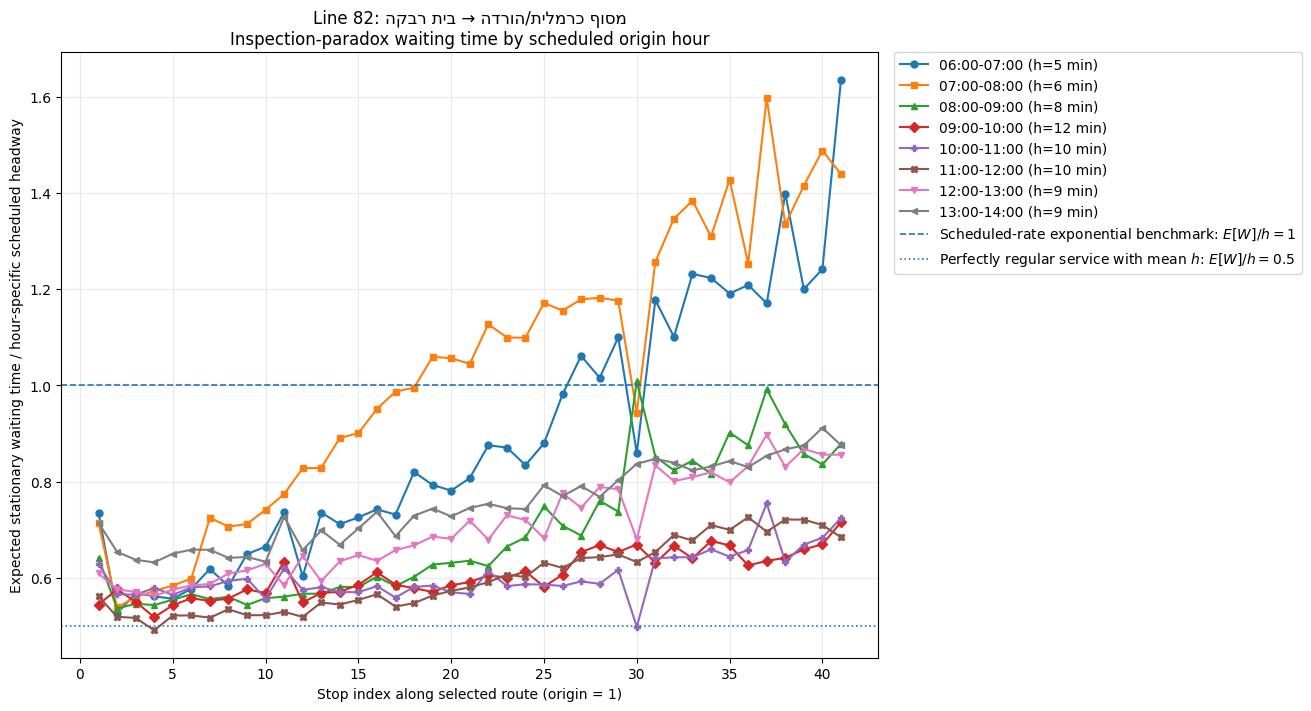

,origin_hour,hour_label,successful_stop_fits,stops_attempted,median_gaps_per_stop,scheduled_headway_minutes
0,6,06:00-07:00,41,41,117.0,5.0
1,7,07:00-08:00,41,41,162.0,6.0
2,8,08:00-09:00,41,41,156.0,8.0
3,9,09:00-10:00,41,41,119.0,12.0
4,10,10:00-11:00,41,41,112.0,10.0
5,11,11:00-12:00,41,41,110.0,10.0
6,12,12:00-13:00,41,41,142.0,9.0
7,13,13:00-14:00,41,41,123.0,9.0


,hour_label,stop_index,stop_code,stop_name,scheduled_headway_minutes,n_gaps_fit,weibull_shape,weibull_scale_over_headway,weibull_mean_over_headway,weibull_cv,expected_wait_minutes,expected_wait_over_headway,fit_success
0,06:00-07:00,1,36667,בית רבקה,5.0,92,2.549816,1.408610,1.250448,0.420416,3.678659,0.735732,True
1,06:00-07:00,2,32554,תיכון תלם/שפרינצק,5.0,97,5.069030,1.090281,1.001855,0.226201,2.632793,0.526559,True
2,06:00-07:00,3,32556,שפרינצק / פינס,5.0,148,3.103645,1.130887,1.011413,0.352543,2.842797,0.568559,True
3,06:00-07:00,4,31606,יחיאל מיכל פינס/רוטשילד,5.0,83,3.381565,1.130995,1.015781,0.326411,2.810017,0.562003,True
4,06:00-07:00,5,31693,רוטשילד/גד מכנס,5.0,127,3.859692,1.135883,1.027492,0.289745,2.784381,0.556876,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
323,13:00-14:00,37,21543,המלך ג'ורג'/בוגרשוב,9.0,51,1.459956,1.270006,1.150465,0.696143,7.685993,0.853999,True
324,13:00-14:00,38,25556,המלך ג'ורג'/רש''י,9.0,100,1.602164,1.373683,1.231456,0.639114,7.805096,0.867233,True
325,13:00-14:00,39,20773,המלך ג'ורג'/אלנבי,9.0,123,1.640362,1.406618,1.258409,0.625503,7.878453,0.875384,True
326,13:00-14:00,40,20121,גאולה/הכובשים,9.0,125,1.386103,1.302683,1.189190,0.730505,8.207042,0.911894,True


Saved:
 - /Users/yuvalgat/Desktop/Development/Python/Projects/talpiot-hackathon/open_bus_poisson_results/hourly_arrivals_line_82_06_14.csv
 - /Users/yuvalgat/Desktop/Development/Python/Projects/talpiot-hackathon/open_bus_poisson_results/hourly_gaps_line_82_06_14.csv
 - /Users/yuvalgat/Desktop/Development/Python/Projects/talpiot-hackathon/open_bus_poisson_results/hourly_waiting_results_line_82_06_14.csv
 - /Users/yuvalgat/Desktop/Development/Python/Projects/talpiot-hackathon/open_bus_poisson_results/hourly_expected_wait_over_headway_line_82_06_14.png


In [78]:
# ============================================================
# Hour-by-hour E[W/h] analysis for one selected route
# ============================================================
#
# Required objects and functions from the main notebook:
#   selected
#   rides_cache
#   client
#   start_date
#   end_date
#   output_dir
#   MAX_GAP_MINUTES
#   israeli_weekdays
#   local_datetime
#   parse_datetime_series
#   batched
#   fetch_arrivals_for_siri_rides
#
# Procedure:
#   1. User selects one of the previously selected route patterns.
#   2. Download SIRI rides over a fixed range, e.g. 06:00-10:00,
#      for every Sunday-Thursday in the original date range.
#   3. Divide rides according to their scheduled origin hour:
#         06:00-07:00, 07:00-08:00, ...
#   4. At each stop and within each hour, construct gaps only
#      between consecutive scheduled trips.
#   5. Fit Weibull(k, lambda), with location fixed at zero.
#   6. Plot
#
#      E[W]/h
#        = (lambda/h)
#          Gamma(1 + 2/k)
#          / (2 Gamma(1 + 1/k))
#
#      against route stop index.
# ============================================================

import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.special import gammaln
from tqdm.auto import tqdm
from IPython.display import display


# ------------------------------------------------------------
# User configuration
# ------------------------------------------------------------

# Print the available route patterns before choosing.
route_options = pd.DataFrame(
    [
        {
            "route_index": i,
            "line": route.identity.route_short_name,
            "company": route.identity.agency_name,
            "direction": route.identity.route_direction,
            "alternative": route.identity.route_alternative,
            "first_stop": route.route_stop_names[0],
            "last_stop": route.route_stop_names[-1],
            "number_of_stops": route.route_stop_count,
        }
        for i, route in enumerate(selected)
    ]
)

display(route_options)

# Change this integer to select a route from the table above.
SELECTED_ROUTE_INDEX = 0

# Analyze half-open hourly intervals:
#
#   [START_HOUR, START_HOUR + 1),
#   ...
#   [END_HOUR - 1, END_HOUR)
#
# Thus, 6 and 10 produce:
#   06:00-07:00
#   07:00-08:00
#   08:00-09:00
#   09:00-10:00
START_HOUR = 6
END_HOUR = 14

# Minimum number of observed interarrival gaps needed to fit a
# Weibull distribution for one stop-hour combination.
MIN_GAPS_PER_STOP_HOUR = 4

# Scheduled headways are rounded to this resolution when finding
# the modal scheduled headway for each hour.
HEADWAY_ROUNDING_MINUTES = 1.0

# Optional trimming before Weibull fitting.
# Keep None to retain all gaps accepted by MAX_GAP_MINUTES.
UPPER_GAP_QUANTILE = None
# Example:
# UPPER_GAP_QUANTILE = 0.99


# ------------------------------------------------------------
# Validate configuration and choose route
# ------------------------------------------------------------

if not 0 <= SELECTED_ROUTE_INDEX < len(selected):
    raise IndexError(
        f"SELECTED_ROUTE_INDEX must lie between 0 and "
        f"{len(selected) - 1}."
    )

if not 0 <= START_HOUR < END_HOUR <= 24:
    raise ValueError(
        "Require 0 <= START_HOUR < END_HOUR <= 24."
    )

if HEADWAY_ROUNDING_MINUTES <= 0:
    raise ValueError(
        "HEADWAY_ROUNDING_MINUTES must be positive."
    )

hourly_route = selected[SELECTED_ROUTE_INDEX]
hourly_rides = rides_cache[hourly_route.identity].copy()

analysis_dates = israeli_weekdays(
    start_date,
    end_date,
)

if not analysis_dates:
    raise RuntimeError(
        "The configured date range contains no Sunday-Thursday dates."
    )

hour_values = list(range(START_HOUR, END_HOUR))

print(
    f"Selected line {hourly_route.identity.route_short_name}, "
    f"{hourly_route.route_stop_names[0]} -> "
    f"{hourly_route.route_stop_names[-1]}"
)
print(
    f"Company: {hourly_route.identity.agency_name}"
)
print(
    f"Hours: {START_HOUR:02d}:00-{END_HOUR:02d}:00"
)
print(
    f"Sunday-Thursday dates: {len(analysis_dates)}"
)


# ------------------------------------------------------------
# Time-window helpers
# ------------------------------------------------------------

def day_hour_timestamp(day, hour):
    """
    Construct a timezone-aware timestamp at the given integer hour.

    Starting from local midnight also supports hour=24 as the
    following day's midnight.
    """
    midnight = pd.Timestamp(
        local_datetime(day, "00:00")
    )
    return midnight + pd.Timedelta(hours=hour)


def scheduled_range_cohort(
    rides,
    day,
    start_hour,
    end_hour,
):
    """
    Return GTFS trips whose scheduled origin departure lies in
    [start_hour, end_hour).
    """
    start = day_hour_timestamp(day, start_hour)
    end = day_hour_timestamp(day, end_hour)

    return (
        rides[
            (rides["start_time"] >= start)
            & (rides["start_time"] < end)
        ]
        .sort_values("start_time")
        .drop_duplicates("id")
        .copy()
    )


def scheduled_hour_cohort(
    rides,
    day,
    hour,
):
    """
    Return GTFS trips whose scheduled origin departure lies in
    [hour, hour+1).
    """
    return scheduled_range_cohort(
        rides=rides,
        day=day,
        start_hour=hour,
        end_hour=hour + 1,
    )


# ------------------------------------------------------------
# Download SIRI rides for the full clock range
# ------------------------------------------------------------

def fetch_siri_rides_for_clock_range(
    client,
    route,
    day,
    cohort,
    start_hour,
    end_hour,
):
    """
    Fetch SIRI rides for one line and day over the complete clock
    range, then retain only SIRI records linked to the selected
    route pattern's GTFS trips.
    """
    if cohort.empty:
        return pd.DataFrame()

    start = day_hour_timestamp(day, start_hour)
    end = day_hour_timestamp(day, end_hour)

    rows = client.list_all(
        "/siri_rides/list",
        {
            "siri_route__line_refs": str(
                route.identity.line_ref
            ),
            "scheduled_start_time_from": start.isoformat(),
            "scheduled_start_time_to": end.isoformat(),
            "order_by": "scheduled_start_time",
        },
        page_size=2_000,
    )

    siri_rides = pd.DataFrame(rows)

    if (
        siri_rides.empty
        or "gtfs_ride_id" not in siri_rides.columns
    ):
        return pd.DataFrame()

    cohort_ids = set(
        cohort["id"].astype(int)
    )

    siri_rides = siri_rides[
        siri_rides["gtfs_ride_id"].isin(cohort_ids)
    ].copy()

    if siri_rides.empty:
        return siri_rides

    siri_rides["scheduled_start_time"] = (
        parse_datetime_series(
            siri_rides["scheduled_start_time"]
        )
    )

    return siri_rides


# ------------------------------------------------------------
# Download all route-stop observations
# ------------------------------------------------------------

hourly_arrival_frames = []

for day in tqdm(
    analysis_dates,
    desc=(
        f"Downloading line "
        f"{hourly_route.identity.route_short_name} "
        f"{START_HOUR:02d}:00-{END_HOUR:02d}:00"
    ),
):
    day_cohort = scheduled_range_cohort(
        rides=hourly_rides,
        day=day,
        start_hour=START_HOUR,
        end_hour=END_HOUR,
    )

    if day_cohort.empty:
        continue

    siri_rides = fetch_siri_rides_for_clock_range(
        client=client,
        route=hourly_route,
        day=day,
        cohort=day_cohort,
        start_hour=START_HOUR,
        end_hour=END_HOUR,
    )

    if siri_rides.empty:
        continue

    # This existing notebook function retrieves all route stops
    # for the requested SIRI rides and maps them to route positions.
    day_arrivals = fetch_arrivals_for_siri_rides(
        client=client,
        siri_rides=siri_rides,
        route=hourly_route,
        day=day,
    )

    if not day_arrivals.empty:
        hourly_arrival_frames.append(day_arrivals)


if not hourly_arrival_frames:
    raise RuntimeError(
        "No SIRI route-stop observations were returned for the "
        "chosen route and clock range."
    )

hourly_arrivals = pd.concat(
    hourly_arrival_frames,
    ignore_index=True,
)

hourly_arrivals_path = (
    output_dir
    / (
        f"hourly_arrivals_line_"
        f"{hourly_route.identity.route_short_name}_"
        f"{START_HOUR:02d}_{END_HOUR:02d}.csv"
    )
)

hourly_arrivals.to_csv(
    hourly_arrivals_path,
    index=False,
)

print(
    f"Downloaded route-stop observations: "
    f"{len(hourly_arrivals):,}"
)


# ------------------------------------------------------------
# Scheduled headway for each hourly interval
# ------------------------------------------------------------

def calculate_hourly_scheduled_headways(
    rides,
    dates,
    hours,
    rounding_minutes=1.0,
):
    """
    Estimate one scheduled headway h for each hour.

    All within-hour consecutive scheduled-origin gaps from all
    Sunday-Thursday dates are pooled. The gaps are rounded to the
    chosen resolution, and the most frequent rounded value is used.

    Cross-hour gaps are deliberately excluded.
    """
    rows = []

    for hour in hours:
        all_scheduled_gaps = []
        n_dates_with_pairs = 0

        for day in dates:
            cohort = scheduled_hour_cohort(
                rides=rides,
                day=day,
                hour=hour,
            )

            gaps = (
                cohort["start_time"]
                .diff()
                .dropna()
                .dt.total_seconds()
                .to_numpy(dtype=float)
                / 60.0
            )

            gaps = gaps[
                np.isfinite(gaps)
                & (gaps > 0)
            ]

            if len(gaps) > 0:
                n_dates_with_pairs += 1
                all_scheduled_gaps.extend(gaps.tolist())

        values = np.asarray(
            all_scheduled_gaps,
            dtype=float,
        )

        if len(values) == 0:
            rows.append(
                {
                    "origin_hour": hour,
                    "hour_label": (
                        f"{hour:02d}:00-"
                        f"{hour + 1:02d}:00"
                    ),
                    "scheduled_headway_minutes": np.nan,
                    "mean_scheduled_headway_minutes": np.nan,
                    "scheduled_headway_cv": np.nan,
                    "n_scheduled_pairs": 0,
                    "n_dates_with_scheduled_pairs": 0,
                }
            )
            continue

        rounded = (
            np.round(
                values / rounding_minutes
            )
            * rounding_minutes
        )

        unique_values, counts = np.unique(
            rounded,
            return_counts=True,
        )

        modal_headway = float(
            unique_values[np.argmax(counts)]
        )

        rows.append(
            {
                "origin_hour": hour,
                "hour_label": (
                    f"{hour:02d}:00-"
                    f"{hour + 1:02d}:00"
                ),
                "scheduled_headway_minutes": modal_headway,
                "mean_scheduled_headway_minutes": float(
                    np.mean(values)
                ),
                "scheduled_headway_cv": (
                    float(
                        np.std(values, ddof=1)
                        / np.mean(values)
                    )
                    if len(values) > 1
                    else np.nan
                ),
                "n_scheduled_pairs": len(values),
                "n_dates_with_scheduled_pairs": (
                    n_dates_with_pairs
                ),
            }
        )

    return pd.DataFrame(rows)


hourly_headways = calculate_hourly_scheduled_headways(
    rides=hourly_rides,
    dates=analysis_dates,
    hours=hour_values,
    rounding_minutes=HEADWAY_ROUNDING_MINUTES,
)

display(hourly_headways)


# ------------------------------------------------------------
# Build observed interarrival gaps independently for each hour
# ------------------------------------------------------------

def build_hourly_interarrival_gaps(
    arrivals,
    route,
    rides,
    dates,
    hours,
    max_gap_minutes=60.0,
):
    """
    Construct route-stop interarrival gaps separately for each
    scheduled-origin hour.

    A valid observed gap must connect two adjacent GTFS trips in
    the same hourly origin cohort. Thus no gap crosses an hourly
    boundary.
    """
    records = []

    line_arrivals = arrivals[
        arrivals["line_ref"]
        == route.identity.line_ref
    ].copy()

    for day in tqdm(
        dates,
        desc="Constructing hour-specific interarrival gaps",
    ):
        day_text = day.isoformat()

        day_arrivals = line_arrivals[
            line_arrivals["service_date"] == day_text
        ].copy()

        if day_arrivals.empty:
            continue

        for hour in hours:
            cohort = scheduled_hour_cohort(
                rides=rides,
                day=day,
                hour=hour,
            ).reset_index(drop=True)

            if len(cohort) < 2:
                continue

            schedule_order = {
                int(ride_id): index
                for index, ride_id
                in enumerate(cohort["id"])
            }

            hour_arrivals = day_arrivals[
                day_arrivals["gtfs_ride_id"].isin(
                    schedule_order
                )
            ].copy()

            hour_arrivals["scheduled_index"] = (
                hour_arrivals["gtfs_ride_id"].map(
                    schedule_order
                )
            )

            hour_arrivals = hour_arrivals[
                hour_arrivals["scheduled_index"].notna()
            ]

            for stop_index in route.route_stop_indices:
                stop_rows = hour_arrivals[
                    hour_arrivals["stop_index"]
                    == stop_index
                ].copy()

                by_scheduled_index = {
                    int(row.scheduled_index): row
                    for row in stop_rows.itertuples(
                        index=False
                    )
                }

                for index in range(len(cohort) - 1):
                    left = by_scheduled_index.get(index)
                    right = by_scheduled_index.get(index + 1)

                    if left is None or right is None:
                        continue

                    gap_minutes = (
                        right.arrival_time
                        - left.arrival_time
                    ).total_seconds() / 60.0

                    if not (
                        0 < gap_minutes <= max_gap_minutes
                    ):
                        continue

                    scheduled_gap_minutes = (
                        cohort.loc[
                            index + 1,
                            "start_time",
                        ]
                        - cohort.loc[
                            index,
                            "start_time",
                        ]
                    ).total_seconds() / 60.0

                    records.append(
                        {
                            "line": (
                                route.identity.route_short_name
                            ),
                            "line_ref": (
                                route.identity.line_ref
                            ),
                            "service_date": day_text,
                            "origin_hour": hour,
                            "hour_label": (
                                f"{hour:02d}:00-"
                                f"{hour + 1:02d}:00"
                            ),
                            "route_stop_sequence": int(
                                left.route_stop_sequence
                            ),
                            "stop_index": int(
                                left.stop_index
                            ),
                            "stop_code": int(
                                left.stop_code
                            ),
                            "stop_name": left.stop_name,
                            "leading_gtfs_ride_id": int(
                                left.gtfs_ride_id
                            ),
                            "following_gtfs_ride_id": int(
                                right.gtfs_ride_id
                            ),
                            "gap_minutes": gap_minutes,
                            "scheduled_origin_gap_minutes": (
                                scheduled_gap_minutes
                            ),
                        }
                    )

    return pd.DataFrame(records)


hourly_gaps = build_hourly_interarrival_gaps(
    arrivals=hourly_arrivals,
    route=hourly_route,
    rides=hourly_rides,
    dates=analysis_dates,
    hours=hour_values,
    max_gap_minutes=MAX_GAP_MINUTES,
)

if hourly_gaps.empty:
    raise RuntimeError(
        "No valid hour-specific observed interarrival gaps "
        "could be constructed."
    )

hourly_gaps_path = (
    output_dir
    / (
        f"hourly_gaps_line_"
        f"{hourly_route.identity.route_short_name}_"
        f"{START_HOUR:02d}_{END_HOUR:02d}.csv"
    )
)

hourly_gaps.to_csv(
    hourly_gaps_path,
    index=False,
)

print(
    f"Valid hour-specific interarrival gaps: "
    f"{len(hourly_gaps):,}"
)


# ------------------------------------------------------------
# Fit Weibull distribution at each stop within each hour
# ------------------------------------------------------------

def fit_hourly_weibull_models(
    gaps,
    hourly_headways,
    min_gaps=8,
    upper_gap_quantile=None,
):
    """
    Fit Weibull(k, lambda), with location fixed at zero, for each
    origin-hour and route-stop combination.
    """
    headway_lookup = (
        hourly_headways
        .set_index("origin_hour")[
            "scheduled_headway_minutes"
        ]
        .to_dict()
    )

    group_columns = [
        "line",
        "line_ref",
        "origin_hour",
        "hour_label",
        "route_stop_sequence",
        "stop_index",
        "stop_code",
        "stop_name",
    ]

    results = []

    for keys, group in gaps.groupby(
        group_columns,
        dropna=False,
        sort=False,
    ):
        (
            line,
            line_ref,
            origin_hour,
            hour_label,
            route_stop_sequence,
            stop_index,
            stop_code,
            stop_name,
        ) = keys

        scheduled_headway = float(
            headway_lookup.get(
                int(origin_hour),
                np.nan,
            )
        )

        values = pd.to_numeric(
            group["gap_minutes"],
            errors="coerce",
        ).to_numpy(dtype=float)

        values = values[
            np.isfinite(values)
            & (values > 0)
        ]

        n_raw = len(values)

        if upper_gap_quantile is not None:
            if not 0 < upper_gap_quantile <= 1:
                raise ValueError(
                    "UPPER_GAP_QUANTILE must lie in (0, 1]."
                )

            if n_raw > 0:
                cutoff = float(
                    np.quantile(
                        values,
                        upper_gap_quantile,
                    )
                )
                fit_values = values[
                    values <= cutoff
                ]
            else:
                cutoff = np.nan
                fit_values = values
        else:
            cutoff = np.nan
            fit_values = values

        n_fit = len(fit_values)

        row = {
            "line": str(line),
            "line_ref": int(line_ref),
            "origin_hour": int(origin_hour),
            "hour_label": str(hour_label),
            "route_stop_sequence": int(
                route_stop_sequence
            ),
            "stop_index": int(stop_index),
            "stop_code": int(stop_code),
            "stop_name": stop_name,
            "scheduled_headway_minutes": (
                scheduled_headway
            ),
            "n_gaps_raw": n_raw,
            "n_gaps_fit": n_fit,
            "upper_trim_cutoff_minutes": cutoff,
            "sample_mean_minutes": (
                float(np.mean(fit_values))
                if n_fit > 0
                else np.nan
            ),
            "sample_cv": (
                float(
                    np.std(
                        fit_values,
                        ddof=1,
                    )
                    / np.mean(fit_values)
                )
                if (
                    n_fit > 1
                    and np.mean(fit_values) > 0
                )
                else np.nan
            ),
            "weibull_shape": np.nan,
            "weibull_scale_minutes": np.nan,
            "weibull_scale_over_headway": np.nan,
            "weibull_mean_minutes": np.nan,
            "weibull_mean_over_headway": np.nan,
            "weibull_cv": np.nan,
            "expected_wait_minutes": np.nan,
            "expected_wait_over_headway": np.nan,
            "fit_success": False,
        }

        if (
            n_fit < min_gaps
            or not np.isfinite(scheduled_headway)
            or scheduled_headway <= 0
        ):
            results.append(row)
            continue

        try:
            shape, location, scale = (
                stats.weibull_min.fit(
                    fit_values,
                    floc=0,
                )
            )

            if not (
                np.isfinite(shape)
                and shape > 0
                and np.isfinite(scale)
                and scale > 0
            ):
                results.append(row)
                continue

            log_mean_factor = gammaln(
                1.0 + 1.0 / shape
            )

            fitted_mean = float(
                scale
                * np.exp(log_mean_factor)
            )

            log_second_moment_factor = gammaln(
                1.0 + 2.0 / shape
            )

            fitted_second_moment = float(
                scale**2
                * np.exp(log_second_moment_factor)
            )

            fitted_variance = max(
                fitted_second_moment
                - fitted_mean**2,
                0.0,
            )

            fitted_std = float(
                np.sqrt(fitted_variance)
            )

            fitted_cv = (
                fitted_std / fitted_mean
                if fitted_mean > 0
                else np.nan
            )

            # Numerically stable calculation:
            #
            # log(E[W]/h)
            #   = log(lambda/h)
            #     + log Gamma(1 + 2/k)
            #     - log 2
            #     - log Gamma(1 + 1/k)
            log_wait_over_headway = (
                np.log(
                    scale / scheduled_headway
                )
                + log_second_moment_factor
                - np.log(2.0)
                - log_mean_factor
            )

            expected_wait_over_headway = float(
                np.exp(log_wait_over_headway)
            )

            expected_wait_minutes = (
                expected_wait_over_headway
                * scheduled_headway
            )

            row.update(
                {
                    "weibull_shape": float(shape),
                    "weibull_scale_minutes": float(
                        scale
                    ),
                    "weibull_scale_over_headway": (
                        float(scale)
                        / scheduled_headway
                    ),
                    "weibull_mean_minutes": (
                        fitted_mean
                    ),
                    "weibull_mean_over_headway": (
                        fitted_mean
                        / scheduled_headway
                    ),
                    "weibull_cv": float(fitted_cv),
                    "expected_wait_minutes": (
                        expected_wait_minutes
                    ),
                    "expected_wait_over_headway": (
                        expected_wait_over_headway
                    ),
                    "fit_success": True,
                }
            )

        except Exception as exc:
            print(
                f"Weibull fit failed for "
                f"{hour_label}, stop {stop_index}: "
                f"{exc}"
            )

        results.append(row)

    return (
        pd.DataFrame(results)
        .sort_values(
            ["origin_hour", "stop_index"]
        )
        .reset_index(drop=True)
    )


hourly_waiting_results = fit_hourly_weibull_models(
    gaps=hourly_gaps,
    hourly_headways=hourly_headways,
    min_gaps=MIN_GAPS_PER_STOP_HOUR,
    upper_gap_quantile=UPPER_GAP_QUANTILE,
)

hourly_results_path = (
    output_dir
    / (
        f"hourly_waiting_results_line_"
        f"{hourly_route.identity.route_short_name}_"
        f"{START_HOUR:02d}_{END_HOUR:02d}.csv"
    )
)

hourly_waiting_results.to_csv(
    hourly_results_path,
    index=False,
)


# ------------------------------------------------------------
# Route title with simple Hebrew reversal
# ------------------------------------------------------------

def reverse_hebrew_for_plot(text):
    if text is None or pd.isna(text):
        return "Unknown stop"

    text = str(text)

    if re.search(
        r"[\u0590-\u05FF]",
        text,
    ):
        return text[::-1]

    return text


display_origin = reverse_hebrew_for_plot(
    hourly_route.route_stop_names[0]
)

display_destination = reverse_hebrew_for_plot(
    hourly_route.route_stop_names[-1]
)


# ------------------------------------------------------------
# Plot E[W/h] against stop index, one trace per hour
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(13, 7),
    constrained_layout=True,
)

hour_markers = [
    "o",
    "s",
    "^",
    "D",
    "P",
    "X",
    "v",
    "<",
    ">",
    "p",
    "h",
    "*",
]

for marker_index, hour in enumerate(hour_values):
    part = hourly_waiting_results[
        (hourly_waiting_results["origin_hour"] == hour)
        & hourly_waiting_results["fit_success"]
        & np.isfinite(
            hourly_waiting_results[
                "expected_wait_over_headway"
            ]
        )
    ].sort_values("stop_index")

    if part.empty:
        print(
            f"No valid fits for "
            f"{hour:02d}:00-{hour + 1:02d}:00."
        )
        continue

    ax.plot(
        part["stop_index"],
        part["expected_wait_over_headway"],
        marker=hour_markers[
            marker_index % len(hour_markers)
        ],
        markersize=5,
        linewidth=1.5,
        label=(
            f"{hour:02d}:00-"
            f"{hour + 1:02d}:00 "
            f"(h={part['scheduled_headway_minutes'].iloc[0]:g} min)"
        ),
    )


ax.axhline(
    1.0,
    linestyle="--",
    linewidth=1.2,
    label=(
        "Scheduled-rate exponential benchmark: "
        "$E[W]/h=1$"
    ),
)

ax.axhline(
    0.5,
    linestyle=":",
    linewidth=1.2,
    label=(
        "Perfectly regular service with mean $h$: "
        "$E[W]/h=0.5$"
    ),
)

ax.set_xlabel(
    "Stop index along selected route (origin = 1)"
)

ax.set_ylabel(
    "Expected stationary waiting time / "
    "hour-specific scheduled headway"
)

ax.set_title(
    f"Line {hourly_route.identity.route_short_name}: "
    f"{display_origin} \u2192 {display_destination}\n"
    "Inspection-paradox waiting time by scheduled origin hour"
)

ax.grid(alpha=0.25)

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0,
)

hourly_plot_path = (
    output_dir
    / (
        f"hourly_expected_wait_over_headway_line_"
        f"{hourly_route.identity.route_short_name}_"
        f"{START_HOUR:02d}_{END_HOUR:02d}.png"
    )
)

fig.savefig(
    hourly_plot_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()


# ------------------------------------------------------------
# Summaries
# ------------------------------------------------------------

fit_summary = (
    hourly_waiting_results
    .groupby(
        ["origin_hour", "hour_label"],
        as_index=False,
    )
    .agg(
        successful_stop_fits=(
            "fit_success",
            "sum",
        ),
        stops_attempted=(
            "fit_success",
            "size",
        ),
        median_gaps_per_stop=(
            "n_gaps_fit",
            "median",
        ),
        scheduled_headway_minutes=(
            "scheduled_headway_minutes",
            "first",
        ),
    )
)

display(fit_summary)

display(
    hourly_waiting_results[
        [
            "hour_label",
            "stop_index",
            "stop_code",
            "stop_name",
            "scheduled_headway_minutes",
            "n_gaps_fit",
            "weibull_shape",
            "weibull_scale_over_headway",
            "weibull_mean_over_headway",
            "weibull_cv",
            "expected_wait_minutes",
            "expected_wait_over_headway",
            "fit_success",
        ]
    ]
)

print("Saved:")
print(" -", hourly_arrivals_path.resolve())
print(" -", hourly_gaps_path.resolve())
print(" -", hourly_results_path.resolve())
print(" -", hourly_plot_path.resolve())

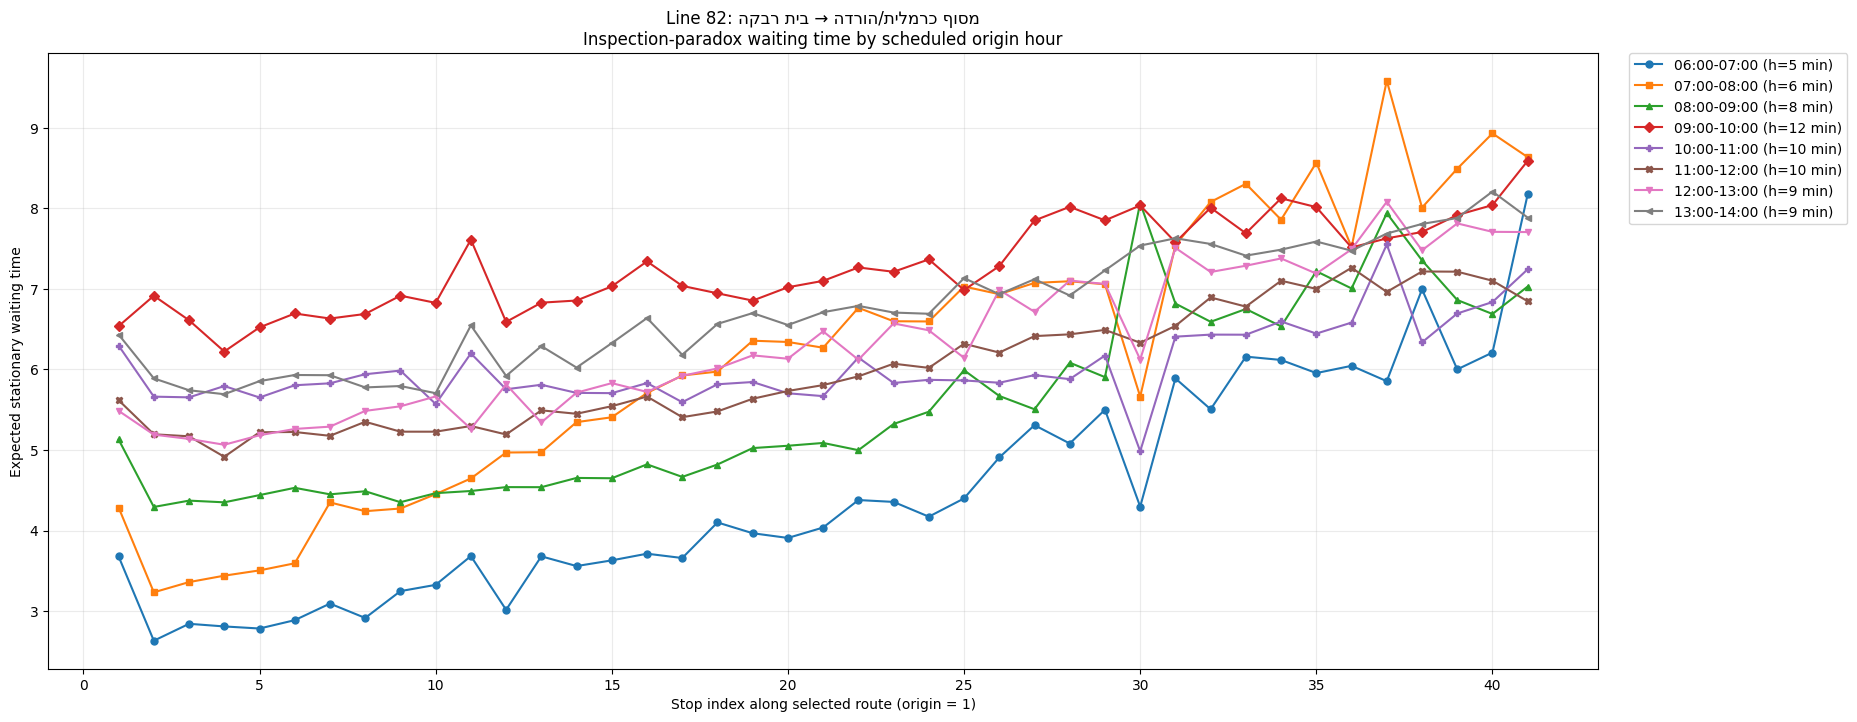

In [96]:
plt.figure(figsize=(20, 8))
for marker_index, hour in enumerate(hour_values):
    part = hourly_waiting_results[
        (hourly_waiting_results["origin_hour"] == hour)
        & hourly_waiting_results["fit_success"]
        & np.isfinite(
            hourly_waiting_results[
                "expected_wait_over_headway"
            ]
        )
    ].sort_values("stop_index")

    if part.empty:
        print(
            f"No valid fits for "
            f"{hour:02d}:00-{hour + 1:02d}:00."
        )
        continue

    plt.plot(
        part["stop_index"],
        part["expected_wait_minutes"], # * np.sqrt(part['scheduled_headway_minutes']),
        marker=hour_markers[
            marker_index % len(hour_markers)
        ],
        markersize=5,
        linewidth=1.5,
        label=(
            f"{hour:02d}:00-"
            f"{hour + 1:02d}:00 "
            f"(h={part['scheduled_headway_minutes'].iloc[0]:g} min)"
        ),
    )


plt.xlabel(
    "Stop index along selected route (origin = 1)"
)

plt.ylabel(
    "Expected stationary waiting time"
)

plt.title(
    f"Line {hourly_route.identity.route_short_name}: "
    f"{display_origin} \u2192 {display_destination}\n"
    "Inspection-paradox waiting time by scheduled origin hour"
)

plt.grid(alpha=0.25)

plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0,
)

plt.show()

,stop_index,stop_code,stop_name
0,1,36667,בית רבקה
1,2,32554,תיכון תלם/שפרינצק
2,3,32556,שפרינצק / פינס
3,4,31606,יחיאל מיכל פינס/רוטשילד
4,5,31693,רוטשילד/גד מכנס
5,6,31674,רוטשילד/קק''ל
6,7,31658,רוטשילד/בלפור
7,8,32495,פרנקפורטר/רוטשילד
8,9,32493,פרנקפורטר/טרומפלדור
9,10,32372,דב הוז/חיים ארלוזורוב


Total current departures implied by the headways: 59.833
 origin_hour  hour_label
           6 06:00-07:00
           7 07:00-08:00
           8 08:00-09:00
           9 09:00-10:00
          10 10:00-11:00
          11 11:00-12:00
          12 12:00-13:00
          13 13:00-14:00


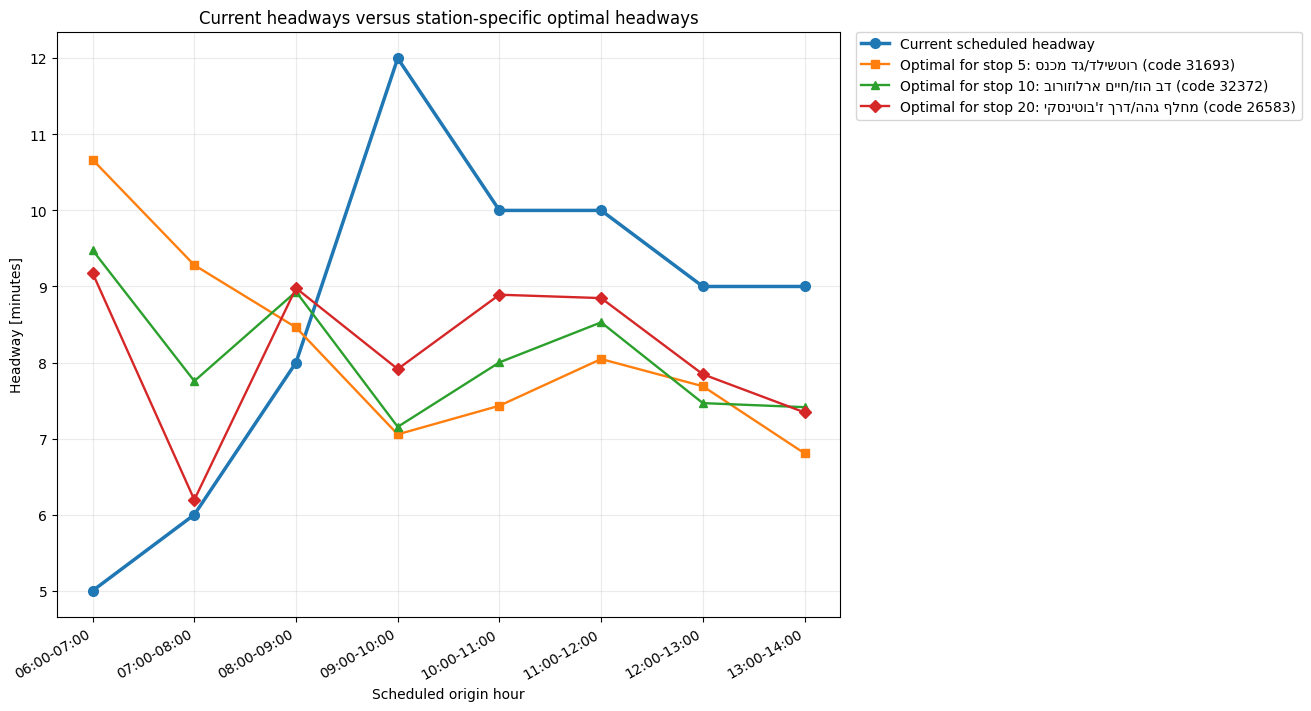

KeyError: 'origin_hour'

In [97]:
# ============================================================
# Station-specific hourly headway optimization
# ============================================================
#
# For each selected stop s, separately solve:
#
#     n*_(t,s) ∝ W_(t,s) / sqrt(h_t)
#
# subject to preserving the current total number of departures:
#
#     sum_t n*_(t,s) = sum_t Delta / h_t.
#
# Then:
#
#     h*_(t,s) = Delta / n*_(t,s).
#
# All station-specific optimal headways are plotted together
# with the current scheduled headway.
# ============================================================

import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


# ------------------------------------------------------------
# User configuration
# ------------------------------------------------------------

# Stop indices for which separate optimizations will be performed.
SELECTED_STOP_INDICES = [5, 10, 20]

# Duration of each optimization interval.
# The current analysis uses one-hour intervals.
INTERVAL_MINUTES = 60.0

# If True, require every selected station to have a valid Weibull
# fit in every hour used in the comparison.
USE_ONLY_COMMON_VALID_HOURS = True


# ------------------------------------------------------------
# Show the available stop indices
# ------------------------------------------------------------

available_stops = (
    hourly_waiting_results[
        [
            "stop_index",
            "stop_code",
            "stop_name",
        ]
    ]
    .drop_duplicates(subset=["stop_index"])
    .sort_values("stop_index")
    .reset_index(drop=True)
)

display(available_stops)


# ------------------------------------------------------------
# Validate selected stops
# ------------------------------------------------------------

SELECTED_STOP_INDICES = [
    int(stop_index)
    for stop_index in SELECTED_STOP_INDICES
]

if len(SELECTED_STOP_INDICES) == 0:
    raise ValueError(
        "SELECTED_STOP_INDICES cannot be empty."
    )

if len(set(SELECTED_STOP_INDICES)) != len(
    SELECTED_STOP_INDICES
):
    raise ValueError(
        "SELECTED_STOP_INDICES contains duplicate indices."
    )

available_indices = set(
    available_stops["stop_index"].astype(int)
)

missing_indices = (
    set(SELECTED_STOP_INDICES)
    - available_indices
)

if missing_indices:
    raise ValueError(
        "The following selected stop indices do not exist: "
        f"{sorted(missing_indices)}"
    )


# ------------------------------------------------------------
# Retain valid stop-hour estimates
# ------------------------------------------------------------

station_hour_data = hourly_waiting_results[
    hourly_waiting_results["stop_index"].isin(
        SELECTED_STOP_INDICES
    )
    & hourly_waiting_results["fit_success"]
    & np.isfinite(
        hourly_waiting_results[
            "expected_wait_minutes"
        ]
    )
    & (
        hourly_waiting_results[
            "expected_wait_minutes"
        ]
        > 0
    )
    & np.isfinite(
        hourly_waiting_results[
            "scheduled_headway_minutes"
        ]
    )
    & (
        hourly_waiting_results[
            "scheduled_headway_minutes"
        ]
        > 0
    )
].copy()

if station_hour_data.empty:
    raise RuntimeError(
        "None of the selected stops has valid hourly "
        "waiting-time estimates."
    )


# Aggregate in case more than one row exists for a stop and hour.
station_hour_data = (
    station_hour_data
    .groupby(
        [
            "stop_index",
            "origin_hour",
            "hour_label",
        ],
        as_index=False,
    )
    .agg(
        stop_code=(
            "stop_code",
            "first",
        ),
        stop_name=(
            "stop_name",
            "first",
        ),
        expected_wait_minutes=(
            "expected_wait_minutes",
            "mean",
        ),
        scheduled_headway_minutes=(
            "scheduled_headway_minutes",
            "median",
        ),
        n_gaps_fit=(
            "n_gaps_fit",
            "sum",
        ),
    )
)


# ------------------------------------------------------------
# Choose a common set of hours
# ------------------------------------------------------------

if USE_ONLY_COMMON_VALID_HOURS:
    number_of_stations_by_hour = (
        station_hour_data
        .groupby("origin_hour")["stop_index"]
        .nunique()
    )

    common_hours = number_of_stations_by_hour[
        number_of_stations_by_hour
        == len(SELECTED_STOP_INDICES)
    ].index

    station_hour_data = station_hour_data[
        station_hour_data["origin_hour"].isin(
            common_hours
        )
    ].copy()

    if station_hour_data.empty:
        raise RuntimeError(
            "There is no hour for which every selected stop "
            "has a valid fit."
        )

    represented_stops = set(
        station_hour_data["stop_index"].astype(int)
    )

    missing_complete_stops = (
        set(SELECTED_STOP_INDICES)
        - represented_stops
    )

    if missing_complete_stops:
        raise RuntimeError(
            "These stops have no estimates over the common "
            f"hours: {sorted(missing_complete_stops)}"
        )


# ------------------------------------------------------------
# Construct the current hourly schedule
# ------------------------------------------------------------

# The scheduled headway is a route-level quantity, so it should
# be identical across stops for a given hour. The median makes
# the code robust to small representation differences.

current_schedule = (
    station_hour_data
    .groupby(
        [
            "origin_hour",
            "hour_label",
        ],
        as_index=False,
    )
    .agg(
        current_headway_minutes=(
            "scheduled_headway_minutes",
            "median",
        ),
        minimum_reported_headway=(
            "scheduled_headway_minutes",
            "min",
        ),
        maximum_reported_headway=(
            "scheduled_headway_minutes",
            "max",
        ),
    )
    .sort_values("origin_hour")
    .reset_index(drop=True)
)

current_schedule["headway_spread"] = (
    current_schedule["maximum_reported_headway"]
    - current_schedule["minimum_reported_headway"]
)

if (
    current_schedule["headway_spread"] > 1e-8
).any():
    print(
        "Warning: scheduled headway differs between stop rows "
        "within at least one hour. The median is being used."
    )


# Continuous number of departures implied by each headway:
#
#     n_t = Delta / h_t

current_schedule["current_departures"] = (
    INTERVAL_MINUTES
    / current_schedule["current_headway_minutes"]
)

total_departures = float(
    current_schedule["current_departures"].sum()
)

print(
    "Total current departures implied by the headways:",
    f"{total_departures:.3f}",
)

# ------------------------------------------------------------
# Normalize the hourly-results schema
# ------------------------------------------------------------

hourly_waiting_results = hourly_waiting_results.copy()

# origin_hour may have become an index in an earlier operation.
if (
    "origin_hour" not in hourly_waiting_results.columns
    and "origin_hour" in hourly_waiting_results.index.names
):
    hourly_waiting_results = (
        hourly_waiting_results.reset_index()
    )

# Try alternative column names used by other notebook versions.
if "origin_hour" not in hourly_waiting_results.columns:
    alternative_hour_columns = [
        "scheduled_origin_hour",
        "hour",
        "start_hour",
        "hour_start",
    ]

    for column in alternative_hour_columns:
        if column in hourly_waiting_results.columns:
            hourly_waiting_results = (
                hourly_waiting_results.rename(
                    columns={column: "origin_hour"}
                )
            )
            break

# Otherwise recover the starting hour from labels such as:
#   "06:00-07:00"
#   "6:00-7:00"
if "origin_hour" not in hourly_waiting_results.columns:
    if "hour_label" not in hourly_waiting_results.columns:
        raise KeyError(
            "Cannot construct origin_hour: neither "
            "'origin_hour' nor 'hour_label' exists.\n"
            f"Available columns:\n"
            f"{hourly_waiting_results.columns.tolist()}"
        )

    extracted_hour = (
        hourly_waiting_results["hour_label"]
        .astype(str)
        .str.extract(
            r"^\s*(\d{1,2})(?::\d{2})?",
            expand=False,
        )
    )

    hourly_waiting_results["origin_hour"] = (
        pd.to_numeric(
            extracted_hour,
            errors="coerce",
        )
    )

# Validate and convert to integer.
invalid_hour_rows = hourly_waiting_results[
    hourly_waiting_results["origin_hour"].isna()
]

if not invalid_hour_rows.empty:
    raise ValueError(
        "Could not determine origin_hour for these labels:\n"
        + invalid_hour_rows[
            ["hour_label"]
        ].drop_duplicates().to_string(index=False)
    )

hourly_waiting_results["origin_hour"] = (
    hourly_waiting_results["origin_hour"].astype(int)
)

print(
    hourly_waiting_results[
        ["origin_hour", "hour_label"]
    ]
    .drop_duplicates()
    .sort_values("origin_hour")
    .to_string(index=False)
)


# ------------------------------------------------------------
# Optimize separately for every selected stop
# ------------------------------------------------------------

optimization_frames = []

for stop_index in SELECTED_STOP_INDICES:
    stop_data = (
        station_hour_data[
            station_hour_data["stop_index"]
            == stop_index
        ]
        .merge(
            current_schedule[
                [
                    "origin_hour",
                    "hour_label",
                    "current_headway_minutes",
                    "current_departures",
                ]
            ],
            on=[
                "origin_hour",
                "hour_label",
            ],
            how="inner",
            validate="one_to_one",
        )
        .sort_values("origin_hour")
        .reset_index(drop=True)
    )

    if stop_data.empty:
        print(
            f"Skipping stop {stop_index}: "
            "no valid hourly observations."
        )
        continue

    if USE_ONLY_COMMON_VALID_HOURS:
        expected_hours = set(
            current_schedule["origin_hour"]
        )

        observed_hours = set(
            stop_data["origin_hour"]
        )

        if observed_hours != expected_hours:
            raise RuntimeError(
                f"Stop {stop_index} does not have complete "
                "data over the common hours."
            )

    # Under the frozen-demand assumption:
    #
    #     p_(t,s) ∝ W_(t,s)
    #
    # the station-specific allocation score is:
    #
    #     score_(t,s) = W_(t,s) / sqrt(h_t)

    stop_data["optimal_allocation_score"] = (
        stop_data["expected_wait_minutes"]
        / np.sqrt(
            stop_data["current_headway_minutes"]
        )
    )

    score_sum = float(
        stop_data[
            "optimal_allocation_score"
        ].sum()
    )

    if not np.isfinite(score_sum) or score_sum <= 0:
        print(
            f"Skipping stop {stop_index}: "
            "invalid allocation-score sum."
        )
        continue

    stop_data["optimal_departure_share"] = (
        stop_data["optimal_allocation_score"]
        / score_sum
    )

    stop_data["optimal_departures"] = (
        total_departures
        * stop_data["optimal_departure_share"]
    )

    stop_data["optimal_headway_minutes"] = (
        INTERVAL_MINUTES
        / stop_data["optimal_departures"]
    )

    stop_data["headway_change_minutes"] = (
        stop_data["optimal_headway_minutes"]
        - stop_data["current_headway_minutes"]
    )

    stop_data["relative_headway_change"] = (
        stop_data["optimal_headway_minutes"]
        / stop_data["current_headway_minutes"]
        - 1.0
    )

    optimization_frames.append(stop_data)


if not optimization_frames:
    raise RuntimeError(
        "No station-specific optimization could be completed."
    )

station_specific_optimization = pd.concat(
    optimization_frames,
    ignore_index=True,
)


# ------------------------------------------------------------
# Hebrew-display helper
# ------------------------------------------------------------

def reverse_hebrew_for_plot(text):
    if text is None or pd.isna(text):
        return "Unknown stop"

    text = str(text).strip()

    if re.search(
        r"[\u0590-\u05FF]",
        text,
    ):
        return text[::-1]

    return text


# ------------------------------------------------------------
# Plot current headway and all station-specific optima
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(13, 7),
    constrained_layout=True,
)

# Current headway is route-level and therefore appears only once.
ax.plot(
    current_schedule["hour_label"],
    current_schedule["current_headway_minutes"],
    marker="o",
    markersize=7,
    linewidth=2.5,
    label="Current scheduled headway",
)

station_markers = [
    "s",
    "^",
    "D",
    "P",
    "X",
    "v",
    "<",
    ">",
    "p",
    "h",
    "*",
    "8",
]

for marker_index, stop_index in enumerate(
    SELECTED_STOP_INDICES
):
    part = station_specific_optimization[
        station_specific_optimization["stop_index"]
        == stop_index
    ].sort_values("origin_hour")

    if part.empty:
        continue

    stop_name = reverse_hebrew_for_plot(
        part["stop_name"].iloc[0]
    )

    stop_code = part["stop_code"].iloc[0]

    ax.plot(
        part["hour_label"],
        part["optimal_headway_minutes"],
        marker=station_markers[
            marker_index % len(station_markers)
        ],
        markersize=6,
        linewidth=1.7,
        label=(
            f"Optimal for stop {stop_index}: "
            f"{stop_name} "
            f"(code {stop_code})"
        ),
    )


ax.set_xlabel("Scheduled origin hour")
ax.set_ylabel("Headway [minutes]")

ax.set_title(
    "Current headways versus station-specific optimal headways"
)

ax.grid(alpha=0.25)

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0,
)

plt.xticks(
    rotation=30,
    ha="right",
)

station_headway_plot_path = (
    output_dir
    / "station_specific_current_vs_optimal_headways.png"
)

fig.savefig(
    station_headway_plot_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()


# ------------------------------------------------------------
# Save and display results
# ------------------------------------------------------------

station_headway_csv_path = (
    output_dir
    / "station_specific_optimal_headways.csv"
)

station_specific_optimization.to_csv(
    station_headway_csv_path,
    index=False,
)


display(
    station_specific_optimization[
        [
            "stop_index",
            "stop_code",
            "stop_name",
            "hour_label",
            "expected_wait_minutes",
            "current_headway_minutes",
            "current_departures",
            "optimal_departures",
            "optimal_headway_minutes",
            "headway_change_minutes",
            "relative_headway_change",
            "n_gaps_fit",
        ]
    ].sort_values(
        [
            "stop_index",
            "origin_hour",
        ]
    )
)


# Compact headway table:
headway_pivot = (
    station_specific_optimization
    .pivot(
        index="hour_label",
        columns="stop_index",
        values="optimal_headway_minutes",
    )
    .rename(
        columns=lambda stop_index: (
            f"optimal_h_stop_{stop_index}"
        )
    )
    .reset_index()
    .merge(
        current_schedule[
            [
                "hour_label",
                "current_headway_minutes",
            ]
        ],
        on="hour_label",
        how="left",
    )
)

ordered_columns = [
    "hour_label",
    "current_headway_minutes",
] + [
    f"optimal_h_stop_{stop_index}"
    for stop_index in SELECTED_STOP_INDICES
    if f"optimal_h_stop_{stop_index}"
    in headway_pivot.columns
]

headway_pivot = headway_pivot[
    ordered_columns
]

display(headway_pivot)


print("Saved:")
print(" -", station_headway_plot_path.resolve())
print(" -", station_headway_csv_path.resolve())

## 18. Write the complete Markdown report

In [73]:
config = {
    "base_url": BASE_URL,
    "analysis_start_date": start_date,
    "analysis_end_date": end_date,
    "service_days": "Sunday-Thursday",
    "central_tel_aviv_bbox": asdict(bbox),
    "requested_line_short_names": requested_lines,
    "number_of_lines": len(requested_lines),
    "final_stops_per_route": N_FINAL_STOPS,
    "candidate_discovery": (
        "exact route_short_name lookup, followed by representative-stop "
        "bounding-box verification"
    ),
    "automatic_route_pattern_selection": (
        "maximize valid days, adjacent pairs, departures, then minimize "
        "scheduled-headway CV"
    ),
    "window_hours": 2,
    "maximum_retained_gap_minutes": MAX_GAP_MINUTES,
    "bootstrap_simulations": BOOTSTRAP_SIMULATIONS,
    "random_seed": RANDOM_SEED,
}

report_path = output_dir / "results_report.md"
write_markdown_report(
    report_path,
    config,
    selected_df,
    line_results,
    stop_results,
    arrivals,
    gaps,
    all_stop_gaps,
    route_stop_cv,
)

print("Report written to:", report_path.resolve())


Report written to: /Users/yuvalgat/Desktop/Development/Python/Projects/talpiot-hackathon/open_bus_poisson_results/results_report.md


## 19. Output inventory

In [74]:
output_files = [
    output_dir / "selected_routes.csv",
    output_dir / "observed_arrivals.csv",
    output_dir / "all_stop_interarrival_gaps.csv",
    output_dir / "interarrival_gaps.csv",
    output_dir / "stop_level_results.csv",
    output_dir / "line_level_results.csv",
    output_dir / "route_stop_cv.csv",
    output_dir / "qq_by_line.png",
    output_dir / "cv_by_line_and_stop.png",
    output_dir / "cv_by_stop_index.png",
    output_dir / "results_report.md",
]

inventory = pd.DataFrame(
    {
        "file": [str(path) for path in output_files],
        "exists": [path.exists() for path in output_files],
        "size_bytes": [path.stat().st_size if path.exists() else np.nan for path in output_files],
    }
)
display(inventory)


,file,exists,size_bytes
0,open_bus_poisson_results/selected_routes.csv,True,32334
1,open_bus_poisson_results/observed_arrivals.csv,True,17470718
2,open_bus_poisson_results/all_stop_interarrival_gaps.csv,True,13570117
3,open_bus_poisson_results/interarrival_gaps.csv,True,1206985
4,open_bus_poisson_results/stop_level_results.csv,True,10371
5,open_bus_poisson_results/line_level_results.csv,True,1515
6,open_bus_poisson_results/route_stop_cv.csv,True,62053
7,open_bus_poisson_results/qq_by_line.png,True,567450
8,open_bus_poisson_results/cv_by_line_and_stop.png,True,98528
9,open_bus_poisson_results/cv_by_stop_index.png,True,400690
